# `playground_pair_variance` — cross-encoder component-pair interactions

Runs over one output dir (`activations_and_datasets_idxs_69`), an array of datasets and an array of
models, and studies the **(vision component, text component)** pairs of the §1 similarity
decomposition.

**The quantity everything is built on.** Per §1 of `playground_exploration`, the image–text cosine
decomposes exactly into a sum over component pairs of the *full component outputs* â (vision) and
b̂ (text):

$$ s \;=\; \cos(\hat z_I, \hat z_T) \;=\; \sum_{a}\sum_{b} \underbrace{\frac{\|\hat a\|\,\|\hat b\|}{\|\hat z_I\|\,\|\hat z_T\|}}_{\omega_{ab}\ \text{(weight)}} \cdot \underbrace{\cos(\hat a, \hat b)}_{\text{cos\_sim}} \;=\; \sum_{a}\sum_{b} S_{ab}, \qquad S_{ab}(i,c)=\frac{\hat a_i \cdot \hat b_c}{\|\hat z_i\|\,\|\hat z_c\|} $$

Components = **every attention head + every MLP slot** of each tower, so `Σ_ab S_ab` is exact.
Every statistic is computed **twice**: over **positive** (image, same-class name) pairs and over
**negative** (mismatched-class) pairs.

| § | Question | Output |
|---|---|---|
| §1 | Which pairs have the highest `Var[S_ab]`? | top-k table per (model, dataset) |
| §2 | How concentrated is that ranking? | cumulative curve |
| §3 | Same top pairs across datasets, fixed model? | normalised share → Jaccard / Spearman |
| §4 | Same top heads for positive vs negative pairs? | pos-vs-neg overlap |
| §5 | Are the pos/neg distributions of a pair the same? | Gaussian fit → PoS + equality tests |
| §6 | Do the top interactions carry zero-shot accuracy? | mean-ablation K-sweep |
| §6b | *Which* ranking criterion finds them? | 6 criteria head-to-head on the same sweep |
| §7 | Where do pairs live in (cos, ω), and how much does each factor vary? | scatter, 3 families, size = Var, ±1σ bars + σ–σ plot |
| §8 | How does one head meet the *other tower's whole embedding*? | φ(a) = weight × cosine, pos vs neg |
| §9 | Does the ‖z‖ non-linearity bias the attribution? | **Shapley values** vs the additive share |

## §0 — Config

In [1]:
import os, json, itertools
import numpy as np, torch
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

OUT_DIR  = "output_dir/activations_and_datasets_idxs_69"
SEED     = 69
CACHE    = f"{OUT_DIR}/pair_variance_cache"

DATASETS = ["CIFAR100", "binary_waterbirds", "caltech", "fairface", "imagenet"]
MODELS   = ["RN50", "RN101", "ViT-B-16", "ViT-B-32", "ViT-L-14", "ViT-H-14"]
POLARITY = ["pos", "neg"]

N_PAIRS  = 256      # (image, class-name) pairs each statistic is taken over, per polarity
# Λ_geo PC budget. The published bundles truncate at 99% of Σ(singular values), which lands at rank
# 61-64 and makes the O(kmax²) pair sum expensive. The ranks are not uniformly 64, so the criterion
# is fit at **90%** explained instead — far cheaper and the dropped tail is, by construction, the
# bottom 10% of the spectrum. The cross-check below confirms the retained PCs are the same vectors.
PC_VAR   = 0.90     # explained-variance threshold for the Λ_geo bundles (published jsonl uses 0.99)
PC_KMAX  = 64       # hard cap; at 32 it DID bind and dropped 13% of Σσ² / 27% of Σσ
TOP_K    = 5        # rows in the §1 table
K_SET    = 25       # top-k pair set used for the §3 / §4 overlap panels
BATCH    = 32       # pairs per matmul batch
device   = "cuda:0" if torch.cuda.is_available() else "cpu"

FIG_DIR = f"{OUT_DIR}/pair_variance_figs"      # every figure is also written here as .png
os.makedirs(CACHE, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name, dpi=200):
    """Write a figure to FIG_DIR and report the path."""
    path = f"{FIG_DIR}/{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("saved →", path)
    return path

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 8.5, "axes.titlesize": 9})

# dataviz: fixed categorical order, assigned by identity (never cycled, never by rank).
DS_COLOR  = dict(zip(DATASETS, ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a"]))
DS_MARKER = dict(zip(DATASETS, ["o", "s", "^", "D", "v"]))   # secondary encoding: 5 series in one scatter
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#f2f6fc", "#2a78d6", "#123763"])  # one hue, light->dark

# §7 families. Blue / red / orange as requested; the red is re-stepped to #b3202b because the
# literal red+orange pair scores dE 7.1 on the normal-vision floor (needs >=15) — indistinguishable
# even with full colour vision. Marker shape carries the same identity as a second channel.
FAM_COLOR  = {"attn×attn": "#2a78d6", "attn×mlp": "#b3202b", "mlp×mlp": "#eb6834"}
FAM_MARKER = {"attn×attn": "o", "attn×mlp": "^", "mlp×mlp": "s"}
POL_COLOR  = {"pos": "#2a78d6", "neg": "#eb6834"}
POL_MARKER = {"pos": "o", "neg": "X"}
print("device:", device, "| grid:", len(MODELS), "models x", len(DATASETS), "datasets x", len(POLARITY), "polarities")

/home/virgilio/lib/minconda3/envs/MT/lib/python3.10/site-packages/torch/cuda/__init__.py:51: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cuda:0 | grid: 6 models x 5 datasets x 2 polarities


## §1 — Rank every component pair by `Var[S_ab]`, for positive and negative pairs

`pair_stats(model, dataset, polarity)` streams `N_PAIRS` (image, class-name) pairs out of the mmapped
activations and accumulates, for **every** component pair, the mean and variance of `S_ab` plus the
mean `cos(â,b̂)` and mean `ω_ab` that §6 needs. `ω` is normalised by the **full** embedding norms
(all heads + all MLP slots), which makes `Σ_ab S_ab = cos(ẑ_I, ẑ_T)` hold exactly — that identity is
the check that ω is right. Cached to `pair_variance_cache/`.

Component layout per tower: attention heads first (`layer × head`, row-major), then MLP slots.

In [2]:
def _paths(model, dataset):
    o, s = OUT_DIR, SEED
    return dict(
        attn_v=f"{o}/{dataset}_attn_{model}_seed_{s}.npy",
        mlp_v =f"{o}/{dataset}_mlp_{model}_seed_{s}.npy",
        lbl_v =f"{o}/{dataset}_labels_{model}_seed_{s}.npy",
        attn_t=f"{o}/{dataset}_classnames_attn_text_{model}_seed_{s}.npy",
        mlp_t =f"{o}/{dataset}_classnames_mlp_text_{model}_seed_{s}.npy",
        lbl_t =f"{o}/{dataset}_classnames_labels_text_{model}_seed_{s}.npy",
    )

def comp_index(L, H, M):
    """Component metadata for one tower: attn heads (layer-major) then MLP slots."""
    kind  = np.array(["attn"] * (L * H) + ["mlp"] * M)
    layer = np.array([l for l in range(L) for _ in range(H)] + list(range(M)))
    head  = np.array([h for _ in range(L) for h in range(H)] + [-1] * M)
    return kind, layer, head

def _stack(attn, mlp):
    """[P,L,H,d] + [P,M,d] -> [P, L*H+M, d]; the sum over axis 1 IS the embedding."""
    P, d = attn.shape[0], attn.shape[-1]
    return torch.cat([attn.reshape(P, -1, d), mlp], 1)

def _sample_pairs(lbl_v, lbl_t, polarity, n_pairs, rng):
    """`n_pairs` (image, class-name) index pairs; same class for 'pos', different for 'neg'."""
    classes = np.unique(lbl_t)
    ok = np.flatnonzero(np.isin(lbl_v, classes))
    ii = rng.permutation(ok)[:n_pairs]
    jj = []
    for i in ii:
        pool = np.flatnonzero(lbl_t == lbl_v[i]) if polarity == "pos" else np.flatnonzero(lbl_t != lbl_v[i])
        jj.append(rng.choice(pool))
    return ii, np.array(jj)

@torch.no_grad()
def _pair_S(model, dataset, polarity, n_pairs):
    """Raw S_ab for every component pair over `n_pairs` pairs -> [n, Kv, Kt], plus cos/omega means."""
    p = _paths(model, dataset)
    A_all = np.load(p["attn_v"], mmap_mode="r"); M_all  = np.load(p["mlp_v"], mmap_mode="r")
    B_all = np.load(p["attn_t"], mmap_mode="r"); Mt_all = np.load(p["mlp_t"], mmap_mode="r")
    lbl_v = np.load(p["lbl_v"]); lbl_t = np.load(p["lbl_t"])
    ii, jj = _sample_pairs(lbl_v, lbl_t, polarity, n_pairs, np.random.default_rng(0))
    Ss, n = [], len(ii)
    acc = {k: None for k in ("cos", "cos2", "om", "om2", "absS", "logl")}
    for b0 in range(0, n, BATCH):
        i, j = ii[b0:b0 + BATCH], jj[b0:b0 + BATCH]
        A = _stack(torch.from_numpy(np.asarray(A_all[i], dtype=np.float32)).to(device),
                   torch.from_numpy(np.asarray(M_all[i], dtype=np.float32)).to(device))
        B = _stack(torch.from_numpy(np.asarray(B_all[j], dtype=np.float32)).to(device),
                   torch.from_numpy(np.asarray(Mt_all[j], dtype=np.float32)).to(device))
        zI, zT = A.sum(1), B.sum(1)
        nA, nB = A.norm(dim=-1), B.norm(dim=-1)
        cos_ab = torch.bmm(A, B.transpose(1, 2)) / (nA[:, :, None] * nB[:, None, :] + 1e-30)
        omega  = (nA[:, :, None] * nB[:, None, :]) / (zI.norm(dim=-1) * zT.norm(dim=-1))[:, None, None]
        S_b = omega * cos_ab
        Ss.append(S_b)
        aS = S_b.abs()
        # multiplicative ("push it further") form, in log space so it is a sum:
        #   correct -> 1-|S| (want |S| BIG -> very negative log),  wrong -> 1+|S| (want |S| small).
        # |S| can exceed 1 for MLP pairs (omega ~ 1), so 1-|S| is clamped before the log.
        logl = torch.log((1 - aS).clamp_min(1e-6)) if polarity == "pos" else torch.log(1 + aS)
        for k, v in (("cos", cos_ab), ("cos2", cos_ab ** 2), ("om", omega), ("om2", omega ** 2),
                     ("absS", aS), ("logl", logl)):
            d = v.double().sum(0)
            acc[k] = d if acc[k] is None else acc[k] + d
    cos_m, om_m = acc["cos"] / n, acc["om"] / n
    # spread of each FACTOR of S_ab = omega * cos, so a point's stability is visible, not just its mean
    cos_v = (acc["cos2"] / n - cos_m ** 2).clamp_min(0) * n / (n - 1)
    om_v  = (acc["om2"]  / n - om_m  ** 2).clamp_min(0) * n / (n - 1)
    return torch.cat(Ss, 0), cos_m, om_m, cos_v, om_v, acc["absS"] / n, acc["logl"] / n

@torch.no_grad()
def _moments(S, chunk=64):
    """Exact central moments of S [n,Kv,Kt] in float64, chunked over the vision axis.

    Two-pass (subtract the mean, then take powers) rather than accumulating raw E[S^k]: S ~ 1e-3,
    so E[S^4] ~ 1e-12 and the raw-moment formula cancels away most of its significant digits.
    """
    n, Kv, Kt = S.shape
    out = {k: torch.empty(Kv, Kt, dtype=torch.float64, device=device) for k in ("mean", "var", "skew", "kurt")}
    for a0 in range(0, Kv, chunk):
        sl = slice(a0, min(a0 + chunk, Kv))
        x = S[:, sl, :].double()
        mu = x.mean(0); c = x - mu
        m2 = (c ** 2).mean(0); m3 = (c ** 3).mean(0); m4 = (c ** 4).mean(0)
        out["mean"][sl] = mu
        out["var"][sl]  = (c ** 2).sum(0) / (n - 1)                 # unbiased
        out["skew"][sl] = m3 / (m2 ** 1.5 + 1e-300)
        out["kurt"][sl] = m4 / (m2 ** 2 + 1e-300)                   # raw (Gaussian = 3)
    return out

@torch.no_grad()
def _emp_pos(Sp, Sn, chunk=4):
    """Distribution-free P(X_pos > Y_neg) over all n x n sample pairings (= Mann-Whitney U / n^2)."""
    n, Kv, Kt = Sp.shape
    out = torch.empty(Kv, Kt, dtype=torch.float32, device=device)
    for a0 in range(0, Kv, chunk):
        sl = slice(a0, min(a0 + chunk, Kv))
        gt = (Sp[:, None, sl, :] > Sn[None, :, sl, :]).float()      # [n,n,c,Kt]
        out[sl] = gt.mean(dim=(0, 1))
    return out

@torch.no_grad()
def pair_all(model, dataset, n_pairs=N_PAIRS, rebuild=False):
    """Everything for one (model, dataset): per-pair moments for BOTH polarities + empirical PoS.

    Both polarities are computed together because the empirical (rank-based) PoS needs the pos and
    neg samples of the same pair side by side. Returns None when the text tower is missing.
    """
    cf = f"{CACHE}/{dataset}_{model}_seed_{SEED}_n{n_pairs}_v5.npz"
    if os.path.exists(cf) and not rebuild:
        z = np.load(cf)
        return {k: z[k] for k in z.files}
    p = _paths(model, dataset)
    if not all(os.path.exists(v) for v in p.values()):
        return None

    out = {}
    Ss = {}
    for pol in POLARITY:
        S, cos_m, om_m, cos_v, om_v, abs_m, logl_m = _pair_S(model, dataset, pol, n_pairs)
        Ss[pol] = S
        mom = _moments(S)
        for k, v in mom.items():
            out[f"{k}_{pol}"] = v.cpu().numpy().astype(np.float32)
        for k, v in (("cos", cos_m), ("omega", om_m), ("cos_var", cos_v), ("omega_var", om_v),
                     ("absmean", abs_m), ("logl", logl_m)):
            out[f"{k}_{pol}"] = v.cpu().numpy().astype(np.float32)
    out["pos_emp"] = _emp_pos(Ss["pos"], Ss["neg"]).cpu().numpy().astype(np.float32)
    del Ss
    torch.cuda.empty_cache() if device.startswith("cuda") else None

    A_all = np.load(p["attn_v"], mmap_mode="r"); M_all = np.load(p["mlp_v"], mmap_mode="r")
    B_all = np.load(p["attn_t"], mmap_mode="r"); Mt_all = np.load(p["mlp_t"], mmap_mode="r")
    kind_v, layer_v, head_v = comp_index(A_all.shape[1], A_all.shape[2], M_all.shape[1])
    kind_t, layer_t, head_t = comp_index(B_all.shape[1], B_all.shape[2], Mt_all.shape[1])
    out.update(kind_v=kind_v, layer_v=layer_v, head_v=head_v, kind_t=kind_t, layer_t=layer_t, head_t=head_t,
               dims_v=np.array([A_all.shape[1], A_all.shape[2], M_all.shape[1]]),
               dims_t=np.array([B_all.shape[1], B_all.shape[2], Mt_all.shape[1]]),
               n_pairs=np.array(n_pairs))
    np.savez_compressed(cf, **out)
    return out

def pair_stats(model, dataset, polarity, n_pairs=N_PAIRS, rebuild=False):
    """Per-polarity view over `pair_all` — keeps the §1–§4 code reading var/mean/cos/omega."""
    a = pair_all(model, dataset, n_pairs, rebuild)
    if a is None:
        return None
    r = {k: a[k] for k in ("kind_v", "layer_v", "head_v", "kind_t", "layer_t", "head_t",
                           "dims_v", "dims_t", "n_pairs")}
    for k in ("mean", "var", "skew", "kurt", "cos", "omega", "cos_var", "omega_var"):
        r[k] = a[f"{k}_{polarity}"]
    return r

def attn_block(r):
    """Slice the attn-head x attn-head sub-grid (what '§1 head pairs' means)."""
    Lv, Hv, _ = r["dims_v"]; Lt, Ht, _ = r["dims_t"]
    return int(Lv * Hv), int(Lt * Ht)

def families(r):
    """Boolean masks over the flattened [Kv,Kt] pair grid, one per family."""
    kv = (r["kind_v"] == "attn")[:, None]; kt = (r["kind_t"] == "attn")[None, :]
    return {"attn×attn": (kv & kt), "attn×mlp": (kv ^ kt), "mlp×mlp": (~kv & ~kt)}

In [3]:
# Goal:  fill the (model x dataset x polarity) grid. Cached, so re-runs are instant.
R = {}
for m in MODELS:
    for d in DATASETS:
        for pol in POLARITY:
            r = pair_stats(m, d, pol)
            if r is None:
                if pol == "pos": print(f"  skip {m:9s} x {d:18s} — no text tower on disk")
                continue
            R[(m, d, pol)] = r
        if (m, d, "pos") in R:
            r = R[(m, d, "pos")]; kv, kt = attn_block(r)
            print(f"  {m:9s} x {d:18s} comps={r['var'].shape[0]}x{r['var'].shape[1]} "
                  f"(heads {kv}x{kt})  max Var[pos]={r['var'].max():.3e}")
print("\nfilled", len(R), "of", len(MODELS) * len(DATASETS) * len(POLARITY), "cells")

  RN50      x CIFAR100           comps=545x109 (heads 544x96)  max Var[pos]=2.269e-04
  RN50      x binary_waterbirds  comps=545x109 (heads 544x96)  max Var[pos]=6.793e-05
  RN50      x caltech            comps=545x109 (heads 544x96)  max Var[pos]=7.319e-04
  RN50      x fairface           comps=545x109 (heads 544x96)  max Var[pos]=9.557e-05
  RN50      x imagenet           comps=545x109 (heads 544x96)  max Var[pos]=8.665e-04
  RN101     x CIFAR100           comps=1089x109 (heads 1088x96)  max Var[pos]=6.785e-04
  RN101     x binary_waterbirds  comps=1089x109 (heads 1088x96)  max Var[pos]=1.658e-04
  RN101     x caltech            comps=1089x109 (heads 1088x96)  max Var[pos]=1.129e-03
  RN101     x fairface           comps=1089x109 (heads 1088x96)  max Var[pos]=4.512e-04
  RN101     x imagenet           comps=1089x109 (heads 1088x96)  max Var[pos]=9.736e-04
  ViT-B-16  x CIFAR100           comps=157x109 (heads 144x96)  max Var[pos]=4.048e-04
  ViT-B-16  x binary_waterbirds  comps=157x1

In [4]:
# Goal:  §1 -- the top-k HEAD-pair table (positive pairs). Rows = model x rank, cols = dataset.
def top_pairs(r, k, heads_only=True):
    """Top-k pairs of one cell ranked by Var[S_ab], named by (kind, layer, head)."""
    var = r["var"]
    if heads_only:
        kv, kt = attn_block(r); var = var[:kv, :kt]
    flat = np.argsort(var, axis=None)[::-1][:k]
    a, b = np.unravel_index(flat, var.shape)
    out = []
    for x, y in zip(a, b):
        out.append(dict(v=f"L{r['layer_v'][x]}H{r['head_v'][x]}", t=f"L{r['layer_t'][y]}H{r['head_t'][y]}",
                        var=float(var[x, y]), idx=(int(x), int(y))))
    return out

rows = []
for m in MODELS:
    for rank in range(TOP_K):
        row = {"model": m, "rank": rank + 1}
        for d in DATASETS:
            if (m, d, "pos") not in R:
                row[d] = "—"; continue
            p = top_pairs(R[(m, d, "pos")], TOP_K)[rank]
            row[d] = f"V {p['v']} ↔ T {p['t']}\nVar {p['var']:.2e}"
        rows.append(row)
table = pd.DataFrame(rows).set_index(["model", "rank"])
print(f"§1  Top-{TOP_K} attention-head pairs by Var[S_ab] over {N_PAIRS} POSITIVE pairs "
      f"(V = vision tower, T = text tower)")
table.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left", "font-size": "8pt"})

§1  Top-5 attention-head pairs by Var[S_ab] over 256 POSITIVE pairs (V = vision tower, T = text tower)


## §2 — Cumulative curve, ordered by the variance ranking

Sort all head pairs by `Var[S_ab]` descending and plot the cumulative share of total variance. The
steeper the curve, the more the input-driven part of the image–text similarity is concentrated in a
few head pairs. One panel per model (pair counts differ across models, so a shared x-axis would
mislead); one line per dataset.

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/02_cumulative_variance.png


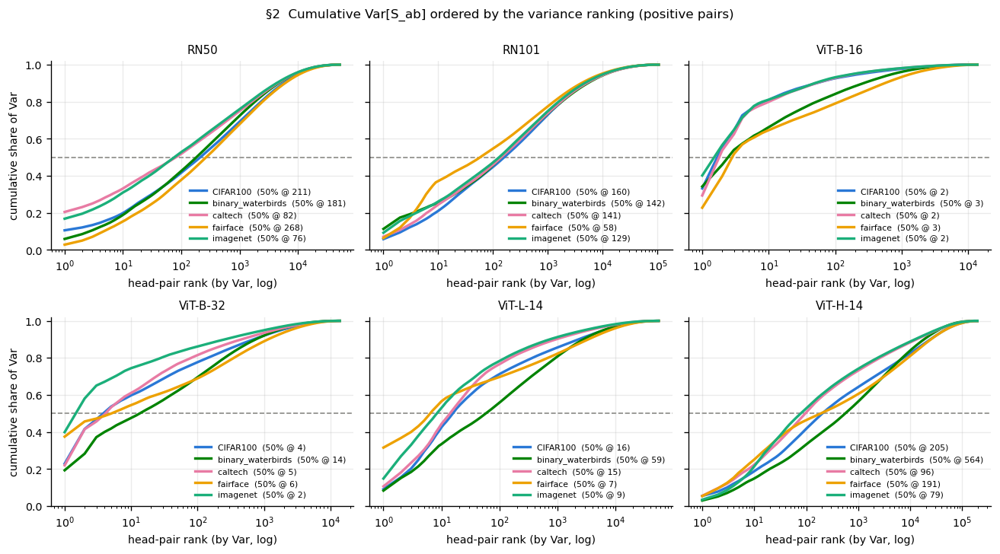

In [12]:
# Goal:  §2 -- cumulative share of total Var[S_ab] against pair rank, per model, one line per dataset.
have = [m for m in MODELS if any((m, d, "pos") in R for d in DATASETS)]
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey=True)
for ax, m in zip(axes.ravel(), have):
    for d in DATASETS:
        if (m, d, "pos") not in R: continue
        r = R[(m, d, "pos")]; kv, kt = attn_block(r)
        v = np.sort(r["var"][:kv, :kt], axis=None)[::-1]
        cum = np.cumsum(v) / v.sum()
        n50 = int(np.searchsorted(cum, 0.5)) + 1
        ax.plot(np.arange(1, len(cum) + 1), cum, lw=2, color=DS_COLOR[d], label=f"{d}  (50% @ {n50})")
    ax.axhline(0.5, ls="--", lw=1, c="#8a8a86", zorder=0)
    ax.set_xscale("log"); ax.set_ylim(0, 1.02)
    ax.set_title(m); ax.set_xlabel("head-pair rank (by Var, log)")
    ax.legend(fontsize=6.5, loc="lower right", frameon=False)
for ax in axes[:, 0]: ax.set_ylabel("cumulative share of Var")
for ax in axes.ravel()[len(have):]: ax.set_visible(False)
fig.suptitle("§2  Cumulative Var[S_ab] ordered by the variance ranking (positive pairs)", y=1.0, fontsize=10)
plt.tight_layout(); save_fig(fig, "02_cumulative_variance"); plt.show()

## §3 — Normalise per (model, dataset), then compare datasets at fixed model

Each cell's variance matrix is normalised to a **share** (`var / var.sum()`), removing the per-model
and per-dataset scale and leaving a comparable distribution over head pairs. With the model fixed,
does a different dataset select the *same* pairs?

- **Top-k Jaccard** — overlap of the top-`K_SET` pair *sets* (the identity question, directly).
- **Spearman ρ** — rank correlation over *all* pairs (the whole ordering, not just its head).

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/03_cross_dataset_agreement.png


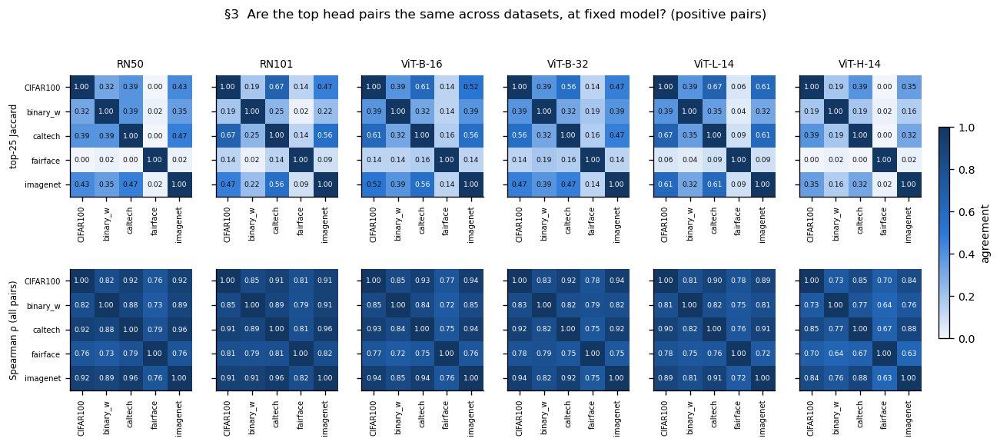


Cross-dataset stability of the pair ranking (1.0 = the dataset does not matter):


,datasets,mean off-diag Jaccard (top-25),mean off-diag Spearman ρ
model,,,
RN50,5,0.238,0.843
RN101,5,0.274,0.866
ViT-B-16,5,0.336,0.835
ViT-B-32,5,0.322,0.832
ViT-L-14,5,0.323,0.816
ViT-H-14,5,0.164,0.747


In [13]:
# Goal:  §3 -- normalise each cell to a variance share, then compare datasets at fixed model.
def head_share(m, d, pol):
    r = R[(m, d, pol)]; kv, kt = attn_block(r)
    v = r["var"][:kv, :kt].astype(np.float64)
    return v / v.sum()

share  = {k: head_share(*k) for k in R}
topset = {k: set(np.argsort(s, axis=None)[::-1][:K_SET].tolist()) for k, s in share.items()}
def jaccard(a, b): return len(a & b) / len(a | b)

jac, spr = {}, {}
for m in have:
    ds = [d for d in DATASETS if (m, d, "pos") in R]
    J = np.full((len(ds), len(ds)), np.nan); P = np.full_like(J, np.nan)
    for x, y in itertools.product(range(len(ds)), repeat=2):
        J[x, y] = jaccard(topset[(m, ds[x], "pos")], topset[(m, ds[y], "pos")])
        P[x, y] = spearmanr(share[(m, ds[x], "pos")].ravel(), share[(m, ds[y], "pos")].ravel()).statistic
    jac[m], spr[m] = (J, ds), (P, ds)

fig, axes = plt.subplots(2, len(have), figsize=(2.05 * len(have), 5.0))
axes = np.atleast_2d(axes)
for col, m in enumerate(have):
    for row, (store, name) in enumerate([(jac, f"top-{K_SET} Jaccard"), (spr, "Spearman ρ (all pairs)")]):
        Mx, ds = store[m]; ax = axes[row, col]
        im = ax.imshow(Mx, cmap=SEQ, vmin=0, vmax=1)
        ax.set_xticks(range(len(ds)), [d[:8] for d in ds], rotation=90, fontsize=6)
        ax.set_yticks(range(len(ds)), [d[:8] for d in ds] if col == 0 else [""] * len(ds), fontsize=6)
        ax.grid(False)
        for x, y in itertools.product(range(len(ds)), repeat=2):   # direct labels: never colour-alone
            ax.text(y, x, f"{Mx[x, y]:.2f}", ha="center", va="center", fontsize=5.5,
                    color="#ffffff" if Mx[x, y] > 0.55 else "#0b0b0b")
        if row == 0: ax.set_title(m, fontsize=8)
        if col == 0: ax.set_ylabel(name, fontsize=7)
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.02, label="agreement")
fig.suptitle("§3  Are the top head pairs the same across datasets, at fixed model? (positive pairs)", fontsize=10)
save_fig(fig, "03_cross_dataset_agreement"); plt.show()

summary = pd.DataFrame([{
    "model": m, "datasets": len(jac[m][1]),
    f"mean off-diag Jaccard (top-{K_SET})": np.nanmean(jac[m][0][~np.eye(len(jac[m][1]), dtype=bool)]),
    "mean off-diag Spearman ρ": np.nanmean(spr[m][0][~np.eye(len(spr[m][1]), dtype=bool)]),
} for m in have]).set_index("model").round(3)
print("\nCross-dataset stability of the pair ranking (1.0 = the dataset does not matter):")
summary

## §4 — Positive vs negative pairs: are the top heads always the same?

The same `Var[S_ab]` ranking, recomputed over **mismatched** (image, class-name) pairs. If a head
pair tops both rankings, its variance is driven by generic input variation rather than by the
class match; if it tops only the positive ranking, it is genuinely selective.

In [14]:
# Goal:  §4 -- compare the pos and neg variance rankings of the head pairs, per (model, dataset).
rows, cells_ = [], []
for m in have:
    for d in DATASETS:
        if (m, d, "pos") not in R or (m, d, "neg") not in R: continue
        jc = jaccard(topset[(m, d, "pos")], topset[(m, d, "neg")])
        rho = spearmanr(share[(m, d, "pos")].ravel(), share[(m, d, "neg")].ravel()).statistic
        p1, n1 = top_pairs(R[(m, d, "pos")], 1)[0], top_pairs(R[(m, d, "neg")], 1)[0]
        rows.append({"model": m, "dataset": d, f"pos∩neg Jaccard (top-{K_SET})": jc,
                     "Spearman ρ (all pairs)": rho,
                     "top-1 pos": f"V {p1['v']}↔T {p1['t']}", "top-1 neg": f"V {n1['v']}↔T {n1['t']}",
                     "same top-1": "yes" if p1["idx"] == n1["idx"] else "no"})
        cells_.append((m, d, jc, rho))
posneg = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, (col, name) in zip(axes, [(2, f"top-{K_SET} Jaccard"), (3, "Spearman ρ (all pairs)")]):
    Mx = np.full((len(have), len(DATASETS)), np.nan)
    for m, d, jc, rho in cells_:
        Mx[have.index(m), DATASETS.index(d)] = jc if col == 2 else rho
    im = ax.imshow(Mx, cmap=SEQ, vmin=0, vmax=1)
    ax.set_xticks(range(len(DATASETS)), DATASETS, rotation=30, ha="right", fontsize=6.5)
    ax.set_yticks(range(len(have)), have, fontsize=6.5); ax.grid(False)
    for x, y in itertools.product(range(len(have)), range(len(DATASETS))):
        if not np.isnan(Mx[x, y]):
            ax.text(y, x, f"{Mx[x, y]:.2f}", ha="center", va="center", fontsize=6,
                    color="#ffffff" if Mx[x, y] > 0.55 else "#0b0b0b")
    ax.set_title(f"positive vs negative: {name}", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, label="agreement")
fig.suptitle("§4  Do the top head pairs survive when the class match is broken?", fontsize=10)
plt.tight_layout(); save_fig(fig, "04_pos_vs_neg_rankings"); plt.show()

print(f"\nsame top-1 head pair for pos and neg: "
      f"{(posneg['same top-1'] == 'yes').sum()} / {len(posneg)} (model, dataset) cells")
posneg.round(3)

TypeError: top_pairs() missing 1 required positional argument: 'k'

## §5 — Positive vs negative as *distributions*: Gaussian fit, probability of superiority, equality test

§4 compared the two variance *rankings*. This section compares the two *distributions* directly. For
each component pair we fit a Gaussian to its `S_ab` samples under positive pairs,
`A ~ N(μ_A, σ_A²)`, and another under negative pairs, `B ~ N(μ_B, σ_B²)`, then ask two separate
questions.

**How big is the difference — probability of superiority.** Since `D = X − Y` of two independent
normals is normal with `μ_D = μ_A − μ_B` and `σ_D² = σ_A² + σ_B²`,

$$ \mathrm{PoS} \;=\; P(X > Y) \;=\; P(D>0) \;=\; \Phi\!\left(\frac{\mu_A - \mu_B}{\sqrt{\sigma_A^2 + \sigma_B^2}}\right) $$

Identical Gaussians give `Φ(0) = 0.5`. Note this divides by the **distribution** spread, so it is an
*effect size* — how often a single positive pair out-scores a single negative one. It is **not** the
t-statistic, which divides by the standard error `√(σ²/n)` and answers a different question.
`|PoS − 0.5|` is therefore the **selectivity** ranking (as opposed to §1's loudness ranking).

**Is the difference real — the equality test.** Under the Gaussian model two distributions are the
same iff both their means and their variances match, so we run **Welch's t-test** (means, unequal
variances) and an **F-test** (variances). With up to ~223k pairs per cell, raw p-values are
meaningless, so everything is corrected with **Benjamini–Hochberg FDR at q = 0.05**. A pair counts as
"same distribution" only if *neither* test rejects.

**Two guards, because the Gaussian fit is an assumption and not a fact:**
- a **Jarque–Bera** normality test per pair per polarity (from the 3rd/4th moments) — it reports what
  fraction of pairs the Gaussian model is even entitled to describe;
- a **distribution-free** empirical `PoS = P(X>Y)` over all n×n sample pairings (Mann–Whitney U/n²)
  plus its rank test, which assumes nothing. Where the Gaussian and empirical PoS disagree, trust
  the empirical one.

Failing to reject is not proof of equality — with n = 256 per polarity the tests have finite power.

In [ ]:
# Goal:  §5 -- fit a Gaussian per pair per polarity, then quantify (PoS) and test (Welch/F/MW) equality.
from scipy.stats import norm, chi2, f as f_dist, t as t_dist

def bh_fdr(p):
    """Benjamini-Hochberg adjusted p-values (flat array in, same shape out)."""
    shp = p.shape; p = p.ravel(); m = p.size
    o = np.argsort(p); ranked = p[o] * m / np.arange(1, m + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(m); out[o] = np.clip(ranked, 0, 1)
    return out.reshape(shp)

def pair_tests(a, q=0.05):
    """Per-pair effect sizes + FDR-corrected equality tests between the pos and neg Gaussians."""
    n = int(a["n_pairs"])
    mA, mB = a["mean_pos"].astype(np.float64), a["mean_neg"].astype(np.float64)
    vA, vB = a["var_pos"].astype(np.float64),  a["var_neg"].astype(np.float64)
    eps = 1e-300

    pos_gauss = norm.cdf((mA - mB) / np.sqrt(vA + vB + eps))            # the PoS formula
    se2 = vA / n + vB / n
    tstat = (mA - mB) / np.sqrt(se2 + eps)                              # Welch: divides by SE, not sigma
    df = se2 ** 2 / ((vA / n) ** 2 / (n - 1) + (vB / n) ** 2 / (n - 1) + eps)
    p_mean = 2 * t_dist.sf(np.abs(tstat), np.maximum(df, 1))
    F = vA / (vB + eps)                                                 # F-test on the variances
    p_var = 2 * np.minimum(f_dist.cdf(F, n - 1, n - 1), f_dist.sf(F, n - 1, n - 1))
    # Jarque-Bera per polarity: does the Gaussian fit hold at all?
    jb = {pol: n / 6 * (a[f"skew_{pol}"].astype(np.float64) ** 2 +
                        (a[f"kurt_{pol}"].astype(np.float64) - 3) ** 2 / 4) for pol in POLARITY}
    p_jb = {pol: chi2.sf(v, 2) for pol, v in jb.items()}
    # Distribution-free: Mann-Whitney normal approximation from the empirical PoS.
    U = a["pos_emp"].astype(np.float64) * n * n
    z = (U - n * n / 2) / np.sqrt(n * n * (2 * n + 1) / 12.0)
    p_mw = 2 * norm.sf(np.abs(z))

    return dict(pos_gauss=pos_gauss, pos_emp=a["pos_emp"].astype(np.float64),
                q_mean=bh_fdr(p_mean), q_var=bh_fdr(p_var), q_mw=bh_fdr(p_mw),
                q_jb_pos=bh_fdr(p_jb["pos"]), q_jb_neg=bh_fdr(p_jb["neg"]))

T = {}
for m in have:
    for d in DATASETS:
        if (m, d, "pos") not in R: continue
        T[(m, d)] = pair_tests(pair_all(m, d))

rows = []
for (m, d), t in T.items():
    same = (t["q_mean"] > 0.05) & (t["q_var"] > 0.05)          # neither test rejects
    rows.append({"model": m, "dataset": d, "pairs": t["pos_gauss"].size,
                 "% Gaussian ok (JB, pos)": 100 * (t["q_jb_pos"] > 0.05).mean(),
                 "% same mean":  100 * (t["q_mean"] > 0.05).mean(),
                 "% same var":   100 * (t["q_var"] > 0.05).mean(),
                 "% same distribution": 100 * same.mean(),
                 "% same (Mann-Whitney)": 100 * (t["q_mw"] > 0.05).mean(),
                 "median PoS": np.median(t["pos_gauss"]),
                 "max PoS": t["pos_gauss"].max(),
                 "corr(PoS gauss, emp)": np.corrcoef(t["pos_gauss"].ravel(), t["pos_emp"].ravel())[0, 1]})
dist_summary = pd.DataFrame(rows).round(3)
print("§5  Positive vs negative distributions, per (model, dataset).  FDR q=0.05 over every pair.")
print("    'same distribution' = neither Welch (means) nor F (variances) rejects.")
dist_summary

§5  Positive vs negative distributions, per (model, dataset).  FDR q=0.05 over every pair.
    'same distribution' = neither Welch (means) nor F (variances) rejects.


,model,dataset,pairs,"% Gaussian ok (JB, pos)",% same mean,% same var,% same distribution,% same (Mann-Whitney),median PoS,max PoS,"corr(PoS gauss, emp)"
0,RN50,CIFAR100,59405,6.040,99.599,78.362,78.177,99.699,0.500,0.703,0.884
1,RN50,binary_waterbirds,59405,31.438,42.976,73.177,37.859,42.331,0.500,0.869,0.997
2,RN50,caltech,59405,3.791,94.297,68.927,66.193,93.554,0.500,0.764,0.918
3,RN50,fairface,59405,14.228,99.798,92.568,92.455,99.845,0.500,0.759,0.938
4,RN50,imagenet,59405,2.308,98.761,78.756,78.236,99.044,0.500,0.734,0.897
5,RN101,CIFAR100,118701,7.595,99.922,82.523,82.496,99.949,0.500,0.672,0.877
6,RN101,binary_waterbirds,118701,33.851,36.388,67.113,30.606,34.925,0.500,0.887,0.993
7,RN101,caltech,118701,4.718,94.165,66.648,63.877,93.230,0.501,0.724,0.915
8,RN101,fairface,118701,15.230,99.798,90.644,90.559,99.922,0.500,0.712,0.941
9,RN101,imagenet,118701,3.897,99.671,78.022,77.893,99.753,0.500,0.699,0.875


saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/05_distribution_equality.png


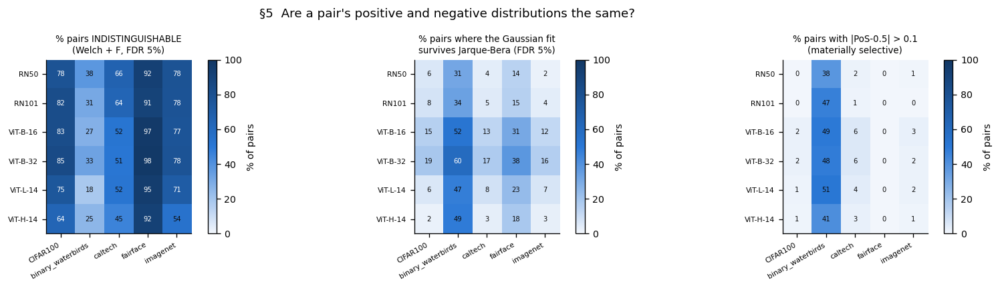

In [ ]:
# Goal:  §5 -- (1) how often the two Gaussians are distinguishable, (2) does the Gaussian PoS hold up.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (key, name, vmax) in zip(axes, [("same", "% pairs INDISTINGUISHABLE\n(Welch + F, FDR 5%)", 100),
                                        ("jb",   "% pairs where the Gaussian fit\nsurvives Jarque-Bera (FDR 5%)", 100),
                                        ("sel",  "% pairs with |PoS-0.5| > 0.1\n(materially selective)", 100)]):
    Mx = np.full((len(have), len(DATASETS)), np.nan)
    for (m, d), t in T.items():
        if key == "same":  v = 100 * ((t["q_mean"] > 0.05) & (t["q_var"] > 0.05)).mean()
        elif key == "jb":  v = 100 * (t["q_jb_pos"] > 0.05).mean()
        else:              v = 100 * (np.abs(t["pos_gauss"] - 0.5) > 0.1).mean()
        Mx[have.index(m), DATASETS.index(d)] = v
    im = ax.imshow(Mx, cmap=SEQ, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(DATASETS)), DATASETS, rotation=30, ha="right", fontsize=6.5)
    ax.set_yticks(range(len(have)), have, fontsize=6.5); ax.grid(False)
    for x, y in itertools.product(range(len(have)), range(len(DATASETS))):
        if not np.isnan(Mx[x, y]):
            ax.text(y, x, f"{Mx[x, y]:.0f}", ha="center", va="center", fontsize=6,
                    color="#ffffff" if Mx[x, y] > 55 else "#0b0b0b")
    ax.set_title(name, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, label="% of pairs")
fig.suptitle("§5  Are a pair's positive and negative distributions the same?", fontsize=11)
plt.tight_layout(); save_fig(fig, "05_distribution_equality"); plt.show()

NameError: name 'T' is not defined

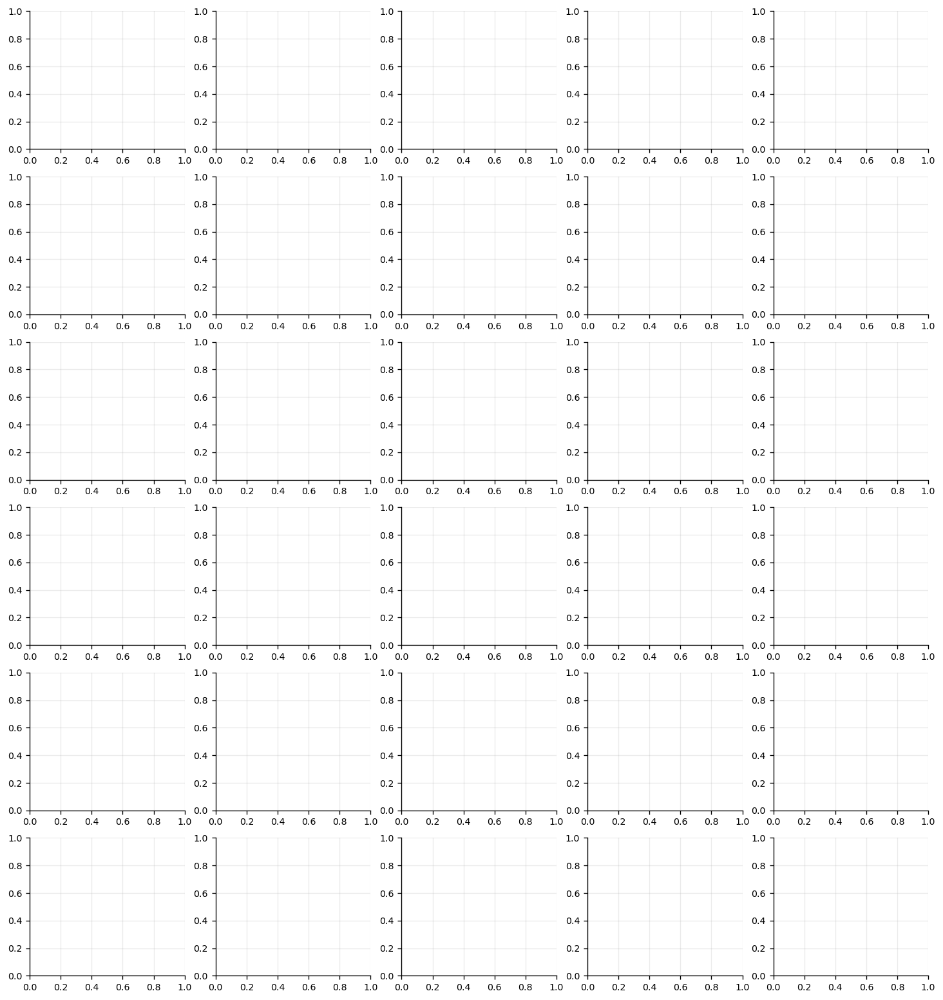

In [15]:
# Goal:  §5 -- is LOUD the same as SELECTIVE?  Var[S_ab] (§1's ranking) against PoS (selectivity).
titled_5b = set()
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.7 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d) not in T:
            ax.set_visible(False); continue
        r = R[(m, d, "pos")]; t = T[(m, d)]
        for fam, fmask in families(r).items():
            idx = np.flatnonzero(np.broadcast_to(fmask, r["var"].shape).ravel())
            if len(idx) > 8000:
                idx = np.random.default_rng(0).choice(idx, 8000, replace=False)
            ax.scatter(r["var"].ravel()[idx], t["pos_gauss"].ravel()[idx], s=2,
                       c=FAM_COLOR[fam], marker=FAM_MARKER[fam], alpha=0.35, lw=0, label=fam)
        ax.axhline(0.5, color="#8a8a86", lw=0.8, zorder=0)
        ax.set_xscale("log"); ax.set_ylim(0, 1)
        if d not in titled_5b:
            ax.set_title(d, fontsize=8.5); titled_5b.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nPoS = P(S_pos > S_neg)", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("Var[S_ab] over positive pairs (log)", fontsize=7)
        ax.tick_params(labelsize=6)
handles = [Line2D([], [], ls="", marker=FAM_MARKER[f], color=FAM_COLOR[f], label=f) for f in FAM_COLOR]
axes[0][0].legend(handles=handles, fontsize=6, loc="upper left", frameon=False)
fig.suptitle("§5  Loudness vs selectivity — §1's Var ranking (x) against probability of superiority (y)\n"
             "PoS = 0.5 means the pair scores the same on matched and mismatched captions", fontsize=11, y=1.005)
plt.tight_layout(); save_fig(fig, "05_loudness_vs_selectivity"); plt.show()

§5  Top-5 MOST SELECTIVE head pairs by PoS (compare with §1's top-Var table — the loud pairs)


saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/05_fitted_gaussians.png


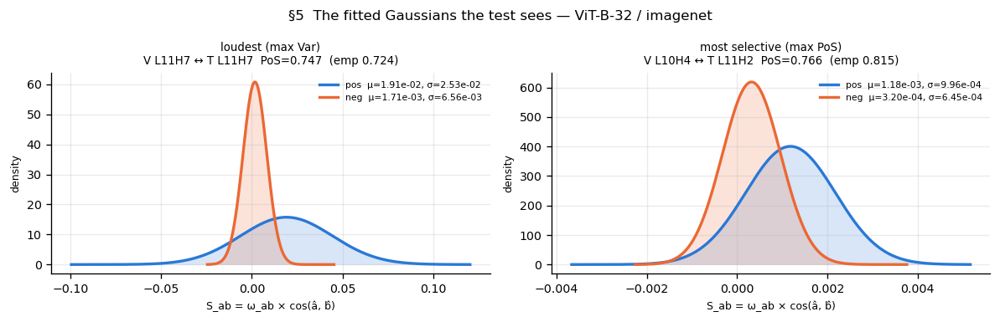

In [ ]:
# Goal:  §5 -- rank the pairs by SELECTIVITY (PoS) and show the fitted Gaussians the test actually sees.
rows = []
for m in have:
    for rank in range(TOP_K):
        row = {"model": m, "rank": rank + 1}
        for d in DATASETS:
            if (m, d) not in T:
                row[d] = "—"; continue
            r, t = R[(m, d, "pos")], T[(m, d)]
            kv, kt = attn_block(r)
            pos_h = t["pos_gauss"][:kv, :kt]                      # heads only, to match §1's table
            x, y = np.unravel_index(np.argsort(pos_h, axis=None)[::-1][rank], pos_h.shape)
            row[d] = (f"V L{r['layer_v'][x]}H{r['head_v'][x]} ↔ T L{r['layer_t'][y]}H{r['head_t'][y]}\n"
                      f"PoS {pos_h[x, y]:.3f}")
        rows.append(row)
sel_table = pd.DataFrame(rows).set_index(["model", "rank"])
print(f"§5  Top-{TOP_K} MOST SELECTIVE head pairs by PoS (compare with §1's top-Var table — the loud pairs)")
display(sel_table.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left", "font-size": "8pt"}))

# The fitted Gaussians for the loudest vs the most selective pair, on one cell.
M_VIEW, D_VIEW = "ViT-B-32", "imagenet"
r, t = R[(M_VIEW, D_VIEW, "pos")], T[(M_VIEW, D_VIEW)]
kv, kt = attn_block(r)
loud = np.unravel_index(np.argmax(r["var"][:kv, :kt]), (kv, kt))
sel  = np.unravel_index(np.argmax(t["pos_gauss"][:kv, :kt]), (kv, kt))
a = pair_all(M_VIEW, D_VIEW)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (x, y), name in zip(axes, [loud, sel], ["loudest (max Var)", "most selective (max PoS)"]):
    for pol in POLARITY:
        mu, sd = a[f"mean_{pol}"][x, y], np.sqrt(a[f"var_{pol}"][x, y])
        xs = np.linspace(min(a["mean_pos"][x, y], a["mean_neg"][x, y]) - 4 * sd,
                         max(a["mean_pos"][x, y], a["mean_neg"][x, y]) + 4 * sd, 400)
        ax.plot(xs, norm.pdf(xs, mu, sd), color=POL_COLOR[pol], lw=2,
                label=f"{pol}  μ={mu:.2e}, σ={sd:.2e}")
        ax.fill_between(xs, norm.pdf(xs, mu, sd), color=POL_COLOR[pol], alpha=0.18, lw=0)
    ax.set_title(f"{name}\nV L{r['layer_v'][x]}H{r['head_v'][x]} ↔ T L{r['layer_t'][y]}H{r['head_t'][y]}  "
                 f"PoS={t['pos_gauss'][x, y]:.3f}  (emp {t['pos_emp'][x, y]:.3f})", fontsize=8)
    ax.set_xlabel("S_ab = ω_ab × cos(â, b̂)", fontsize=7.5); ax.set_ylabel("density", fontsize=7.5)
    ax.legend(fontsize=6.5, frameon=False)
fig.suptitle(f"§5  The fitted Gaussians the test sees — {M_VIEW} / {D_VIEW}", fontsize=10)
plt.tight_layout(); save_fig(fig, "05_fitted_gaussians"); plt.show()

In [ ]:
# Goal:  PC bundles per component -- the (vh, s, mean) that the Λ_geo criterion needs.
# Does:  replicates utils.scripts.algorithms_text_explanations.svd_data_approx exactly, but from the
#        .npy activations. The published bundles live in svd_data_approx_var99/*.jsonl, but the image
#        side of that is 44 GB of JSON; the SVD it stores is recomputed here in ~seconds and the
#        equivalence is CHECKED against a small text jsonl below rather than assumed.
@torch.no_grad()
def pc_bundles(model, dataset, tower, kmax=PC_KMAX, rebuild=False):
    """Per component: unit PC dirs [K,kmax,d], sigma^2 [K,kmax], mean vector [K,d].

    Mirrors svd_data_approx: mean-centre, economy SVD, truncate at 99% of sum(singular values).
    Stored s is SV**2 there; sigma^2 = SV^2/(n-1) is the actual variance, and the /(n-1) matters
    here because the criterion ADDS a mean term that carries its own scale.
    """
    cf = f"{CACHE}/{dataset}_{model}_{tower}_pcb_k{kmax}_v{int(PC_VAR*100)}_seed_{SEED}.npz"
    if os.path.exists(cf) and not rebuild:
        z = np.load(cf); return z["V"], z["S2"], z["MU"]
    p = _paths(model, dataset)
    at, ml = (p["attn_v"], p["mlp_v"]) if tower == "image" else (p["attn_t"], p["mlp_t"])
    # Stream to the GPU in image-chunks. Materialising e.g. ViT-H/imagenet attn (10.5 GB) in host RAM
    # first gets the process killed; the GPU holds it comfortably.
    Am, Mm = np.load(at, mmap_mode="r"), np.load(ml, mmap_mode="r")
    N = Am.shape[0]; K = Am.shape[1] * Am.shape[2] + Mm.shape[1]; d = Am.shape[-1]
    X = torch.empty(N, K, d, device=device, dtype=torch.float32)
    for i0 in range(0, N, 512):
        i1 = min(i0 + 512, N)
        X[i0:i1] = _stack(torch.from_numpy(np.asarray(Am[i0:i1], dtype=np.float32)).to(device),
                          torch.from_numpy(np.asarray(Mm[i0:i1], dtype=np.float32)).to(device))
    V  = torch.zeros(K, kmax, d, device=device)
    S2 = torch.zeros(K, kmax, device=device)
    MU = torch.zeros(K, d, device=device)
    for k in range(K):
        data = X[:, k, :]
        mu = data.mean(0); MU[k] = mu
        c = data - mu
        if N < 2: continue
        _, sv, vh = torch.linalg.svd(c, full_matrices=False)
        tot = sv.sum()
        rank = int((torch.cumsum(sv, 0) / (tot + 1e-30) < PC_VAR).sum().item()) + 1  # same rule, PC_VAR level
        r = min(rank, kmax, sv.shape[0])
        V[k, :r]  = vh[:r] / (vh[:r].norm(dim=-1, keepdim=True) + 1e-30)
        S2[k, :r] = sv[:r] ** 2 / max(N - 1, 1)                                      # sigma^2
    rmax = int((S2 > 0).sum(1).max().item())          # trim the padding; kmax is only a cap
    V, S2 = V[:, :rmax], S2[:, :rmax]
    del X
    if device.startswith("cuda"): torch.cuda.empty_cache()
    out = (V.cpu().numpy(), S2.cpu().numpy(), MU.cpu().numpy())
    np.savez_compressed(cf, V=out[0], S2=out[1], MU=out[2])
    return out

@torch.no_grad()
def pc_criterion(model, dataset, kmax=PC_KMAX, rebuild=False):
    """E[x·y] decomposition per component pair:  mean term  +  total shared variance.

        mean term          = mu_x . mu_y
        shared variance    = sum_i sum_j  alpha_i beta_j |cos(p_i, q_j)|

    Two weightings are returned because the formula as posed is dimensionally mixed:
      'var2'  alpha_i = sigma_i^2  -> the literal Λ_geo (§N align_geo), units |x|^2|y|^2
      'std'   alpha_i = sigma_i    -> the Cauchy-Schwarz bound |E[a_i b_j]| <= sigma_i sigma_j,
                                      the term that is actually commensurate with mu_x . mu_y
    """
    cf = f"{CACHE}/{dataset}_{model}_pccrit_k{kmax}_v{int(PC_VAR*100)}_seed_{SEED}.npz"
    if os.path.exists(cf) and not rebuild:
        z = np.load(cf); return {k: z[k] for k in z.files}
    Vv, S2v, MUv = pc_bundles(model, dataset, "image", kmax)
    Vt, S2t, MUt = pc_bundles(model, dataset, "text", kmax)
    Vv = torch.from_numpy(Vv).to(device); S2v = torch.from_numpy(S2v).to(device)
    Vt = torch.from_numpy(Vt).to(device); S2t = torch.from_numpy(S2t).to(device)
    Kv, kv_r = Vv.shape[0], Vv.shape[1]
    Kt, kt_r = Vt.shape[0], Vt.shape[1]
    Qt = Vt.reshape(Kt * kt_r, -1)                                   # [Kt*r_t, d]
    out = {}
    for wname, wv, wt in (("var2", S2v, S2t), ("std", S2v.sqrt(), S2t.sqrt())):
        L = torch.zeros(Kv, Kt, device=device)
        for a0 in range(0, Kv, 16):                                  # chunk: |C| is big (Kv*r_v x Kt*r_t)
            sl = slice(a0, min(a0 + 16, Kv))
            nb = sl.stop - sl.start
            C = (Vv[sl].reshape(-1, Vv.shape[-1]) @ Qt.T).abs()      # [nb*r_v, Kt*r_t]
            M = wv[sl].reshape(-1)[:, None] * C * wt.reshape(-1)[None, :]
            L[sl] = M.reshape(nb, kv_r, Kt, kt_r).sum((1, 3))
        out[f"shared_{wname}"] = L.cpu().numpy()
    out["mean_term"] = (torch.from_numpy(MUv).to(device) @ torch.from_numpy(MUt).to(device).T).cpu().numpy()
    np.savez_compressed(cf, **out)
    return out

In [16]:
# Goal:  score B via a GREEDY one-to-one PC matching (instead of Λ_geo's full bipartite sum).
# Does:  W_ij = sigma_i sigma_j |cos(p_i,q_j)|; repeatedly take the strongest (i,j), bank it, delete
#        BOTH that p_i and that q_j, repeat until a list is empty; the criterion is the banked sum.
# Note:  |cos|, not the signed dot product -- SVD fixes PC directions only up to sign, so a signed
#        p_i . q_j flips with the solver's sign convention and is not a well-defined quantity.
#        This is the greedy sibling of the Hungarian A-metric; Λ_geo sums ALL i,j instead of matching.
@torch.no_grad()
def pc_greedy_match(model, dataset, kmax=PC_KMAX, chunk=32, rebuild=False):
    """Sum of sigma_i sigma_j |cos(p_i,q_j)| over a greedy one-to-one PC matching, per pair."""
    cf = f"{CACHE}/{dataset}_{model}_pcgreedy_k{kmax}_v{int(PC_VAR*100)}_seed_{SEED}.npz"
    if os.path.exists(cf) and not rebuild:
        return np.load(cf)["G"]
    Vv, S2v, _ = pc_bundles(model, dataset, "image", kmax)
    Vt, S2t, _ = pc_bundles(model, dataset, "text", kmax)
    Vv = torch.from_numpy(Vv).to(device); sv = torch.from_numpy(S2v).to(device).sqrt()   # sigma
    Vt = torch.from_numpy(Vt).to(device); st = torch.from_numpy(S2t).to(device).sqrt()
    Kv, rv, d = Vv.shape; Kt, rt = Vt.shape[0], Vt.shape[1]
    steps = min(rv, rt)
    out = torch.zeros(Kv, Kt, device=device)
    for a0 in range(0, Kv, chunk):
        a1 = min(a0 + chunk, Kv); c = a1 - a0
        C = torch.einsum("cid,bjd->cbij", Vv[a0:a1], Vt).abs()               # [c,Kt,rv,rt]
        W = sv[a0:a1][:, None, :, None] * C * st[None, :, None, :]           # weighted by sigma_i sigma_j
        tot = torch.zeros(c, Kt, device=device)
        ar = torch.arange(c, device=device)[:, None]
        br = torch.arange(Kt, device=device)[None, :]
        for _ in range(steps):
            v, idx = W.reshape(c, Kt, -1).max(-1)
            tot += v.clamp_min(0)          # exhausted/padded PCs contribute 0, never the -1 sentinel
            i, j = idx // rt, idx % rt
            W[ar, br, i, :] = -1.0         # remove that p_i ...
            W[ar, br, :, j] = -1.0         # ... and that q_j, from the lists
        out[a0:a1] = tot
    G = out.cpu().numpy()
    np.savez_compressed(cf, G=G)
    return G

In [17]:
# Goal:  principal-angle machinery, shared by the LINEAR (Gr) and AFFINE (Graff) distances.
# Note:  |cos|-free here -- principal angles come from svdvals(M_A^T M_B) with M orthonormal bases.
#        Ye-Lim delta sums to min(k,l) and is only a PREMETRIC (delta=0 <=> one subspace contains the
#        other), which our unequal ranks (~64 image vs ~42 text) would exploit. d_inf continues to
#        max(k,l) with theta_i = pi/2 for the excess dims and IS a metric on Gr(inf,inf).
@torch.no_grad()
def _principal_angle_dists(Va, ra, Vb, rb, chunk=8):
    """(d_k, d_k/sqrt(k), d_inf) between the row-spans of Va[k] and Vb[k]. Rows must be orthonormal;
    trailing all-zero rows are padding and are excluded via the true ranks ra / rb."""
    Ka, rA, _ = Va.shape; Kb, rB = Vb.shape[0], Vb.shape[1]
    kmin = min(rA, rB)
    d  = torch.zeros(Ka, Kb, device=device)
    dn = torch.zeros(Ka, Kb, device=device)
    for a0 in range(0, Ka, chunk):
        a1 = min(a0 + chunk, Ka); c = a1 - a0
        M = torch.einsum("cid,bjd->cbij", Va[a0:a1], Vb)
        Mf = M.reshape(c * Kb, rA, rB)
        G = (Mf.transpose(-1, -2) @ Mf) if rB <= rA else (Mf @ Mf.transpose(-1, -2))
        lam = torch.linalg.eigvalsh(G)
        sv = lam.clamp_min(0).flip(-1).sqrt()[:, :kmin].reshape(c, Kb, kmin)
        theta = torch.arccos(sv.clamp(0.0, 1.0))
        k = torch.minimum(ra[a0:a1][:, None], rb[None, :]).clamp(min=1)
        keep = torch.arange(kmin, device=device)[None, None, :] < k[:, :, None]
        d2 = (theta ** 2 * keep).sum(-1)
        d[a0:a1] = d2.sqrt(); dn[a0:a1] = (d2 / k).sqrt()
    gap = (ra[:, None] - rb[None, :]).abs().float()
    d_inf = (d ** 2 + gap * (np.pi / 2) ** 2).sqrt()
    return d, dn, d_inf

@torch.no_grad()
def pc_grassmann(model, dataset, kmax=PC_KMAX, rebuild=False):
    """LINEAR Gr distances between the two components' PC subspaces (ignores the means entirely)."""
    cf = f"{CACHE}/{dataset}_{model}_grassmann_k{kmax}_v{int(PC_VAR*100)}_seed_{SEED}.npz"
    if os.path.exists(cf) and not rebuild:
        z = np.load(cf); return z["d"], z["dn"], z["d_inf"]
    Vv, S2v, _ = pc_bundles(model, dataset, "image", kmax)
    Vt, S2t, _ = pc_bundles(model, dataset, "text", kmax)
    d, dn, di = _principal_angle_dists(
        torch.from_numpy(Vv).to(device), torch.from_numpy((S2v > 0).sum(1)).to(device),
        torch.from_numpy(Vt).to(device), torch.from_numpy((S2t > 0).sum(1)).to(device))
    out = (d.cpu().numpy(), dn.cpu().numpy(), di.cpu().numpy())
    np.savez_compressed(cf, d=out[0], dn=out[1], d_inf=out[2])
    return out

@torch.no_grad()
def _affine_basis(V, S2, MU):
    """Lim-Wong-Ye embedding Graff(k,N) -> Gr(k+1,N+1):  A + mu  |->  Span(A u {mu + e_{N+1}}).

    Returns an orthonormal basis of the embedded subspace in R^(d+1) and its true rank r+1.
    The PC rows (p_i, 0) are already orthonormal; (mu, 1) is Gram-Schmidt'd against them, giving
    (mu_perp, 1)/sqrt(||mu_perp||^2 + 1). Slot 0 holds the mean vector, slots 1.. hold the PCs."""
    K, r, d = V.shape
    ranks = (S2 > 0).sum(1)
    A = torch.zeros(K, r + 1, d + 1, device=device)
    coef = torch.einsum("kd,krd->kr", MU, V)              # <mu, p_i>; padded p_i are 0 -> coef 0
    mu_perp = MU - torch.einsum("kr,krd->kd", coef, V)
    nrm = (mu_perp.norm(dim=-1) ** 2 + 1).sqrt()
    A[:, 0, :d] = mu_perp / nrm[:, None]
    A[:, 0, d] = 1.0 / nrm
    A[:, 1:, :d] = V
    return A, ranks + 1

@torch.no_grad()
def pc_grassmann_affine(model, dataset, kmax=PC_KMAX, rebuild=False):
    """AFFINE Graff distances. Our components ARE affine subspaces: mu + span(PCs). This carries the
    mean by construction (Lim-Wong-Ye 2018) instead of the dimensionally-mixed 'Lambda + mu.mu'.
    With mu = 0 on both sides it reduces to the linear Gr distance -- asserted in the check cell."""
    cf = f"{CACHE}/{dataset}_{model}_graff_k{kmax}_v{int(PC_VAR*100)}_seed_{SEED}.npz"
    if os.path.exists(cf) and not rebuild:
        z = np.load(cf); return z["d"], z["dn"], z["d_inf"]
    Vv, S2v, MUv = pc_bundles(model, dataset, "image", kmax)
    Vt, S2t, MUt = pc_bundles(model, dataset, "text", kmax)
    Av, rav = _affine_basis(torch.from_numpy(Vv).to(device), torch.from_numpy(S2v).to(device),
                            torch.from_numpy(MUv).to(device))
    Bt, rbt = _affine_basis(torch.from_numpy(Vt).to(device), torch.from_numpy(S2t).to(device),
                            torch.from_numpy(MUt).to(device))
    d, dn, di = _principal_angle_dists(Av, rav, Bt, rbt)
    out = (d.cpu().numpy(), dn.cpu().numpy(), di.cpu().numpy())
    np.savez_compressed(cf, d=out[0], dn=out[1], d_inf=out[2])
    return out

In [18]:
# ✅ Verify -- the recomputed PC bundles reproduce the published svd_data_approx_var99 jsonl.
# Uses a small TEXT jsonl (5 MB); the image side of that run is 44 GB of JSON and is not parsed.
# CIFAR100 (100 class names) is used, not binary_waterbirds: the latter has 2 rows, so its
# bundles are rank-1 and would not test the PC directions at all.
_m, _d, _tw = "ViT-B-16", "CIFAR100", "text"
_f = f"{OUT_DIR}/svd_data_approx_var99/{_d}_classnames_{_m}_all_text.jsonl"
if os.path.exists(_f):
    _pub = [json.loads(l) for l in open(_f)]
    _pub = [e for e in _pub if e.get("component") == "attn"]
    _V, _S2, _MU = pc_bundles(_m, _d, _tw)
    _N = np.load(_paths(_m, _d)["attn_t"], mmap_mode="r").shape[0]
    _Ht = int(R[(_m, _d, "pos")]["dims_t"][1])
    _dmu, _ds, _dcos = [], [], []
    for e in _pub:
        k = e["layer"] * _Ht + e["head"]
        _dmu.append(np.abs(np.array(e["mean_values_att"]) - _MU[k]).max())
        s_pub = np.array(e["s"])                       # published = SV**2 at var99
        r = min(len(s_pub), int((_S2[k] > 0).sum()))   # ours is var90 -> compare the shared prefix
        _ds.append(np.abs(s_pub[:r] / max(_N - 1, 1) - _S2[k, :r]).max())   # vs our sigma^2
        vh_pub = np.array(e["vh"])[:r]
        vh_pub /= np.linalg.norm(vh_pub, axis=-1, keepdims=True) + 1e-30
        _dcos.append(np.abs(np.abs((vh_pub * _V[k, :r]).sum(-1)) - 1).max())  # |cos| == 1 up to sign
    print(f"vs published jsonl over {len(_pub)} attn components of {_m}/{_d} (text tower).")
    print(f"Ours is fit at {PC_VAR:.0%} explained, the file at 99%, so only the shared PC prefix is compared:")
    print(f"   max |Δ mean vector|      = {max(_dmu):.2e}")
    print(f"   max |Δ σ² (=SV²/(n−1))|  = {max(_ds):.2e}")
    print(f"   max |1 − |cos(vh, ours)||= {max(_dcos):.2e}   (PC directions agree up to sign)")
    _r = (_S2 > 0).sum(1)
    print(f"   PCs kept per component: median {int(np.median(_r))}, max {int(_r.max())} (cap PC_KMAX={PC_KMAX})")
    print(f"   published var99 rank:   median {int(np.median([len(e['s']) for e in _pub]))}, "
          f"max {max(len(e['s']) for e in _pub)}  (ours is deliberately shorter: {PC_VAR:.0%} vs 99%)")
    print(f"   PC_KMAX cap binds on {100 * np.mean(_r >= PC_KMAX):.0f}% of components")
else:
    print("published jsonl not found — skipping the cross-check")

NameError: name 'pc_bundles' is not defined

## §6 — Mean-ablate the top-K pair interactions vs zero-shot accuracy

**Ablation semantics.** Mean-ablating the interaction `(a,b)` replaces `S_ab(i,c)` by its mean over
all (image, class) pairs. That mean is a *constant*, identical for every class `c`, so it cannot
change `argmax_c` — the ablated similarity is therefore

`sim_A[i,c] = sim_full[i,c] − Σ_{(a,b)∈A} S_ab(i,c)   (+ const)`

i.e. the pair keeps its bias term and loses all input-specific information, exactly like the
component-level mean-ablation used elsewhere in the repo. Zero-shot accuracy is recomputed by
`argmax_c` over the dataset's own class names. (In code this is evaluated as the sum over the
*kept* pairs rather than as that subtraction — see the docstring; the two are algebraically equal
but only the former is numerically exact once K is large.)

**The five orders**, all plotted against K = number of pair interactions ablated:
- **rank ↓** — highest `Var[S_ab]` first (the §1 ranking, top-first).
- **rank ↑** — lowest variance first.
- **layer ↓ / ↑** — whole *vision* layers at once (all that layer's heads + its MLP slot, paired
  with every text component), from the last layer down and from the first layer up.
- **random ×5** — 5 random orders, drawn as mean ± min/max band.

If the variance ranking is meaningful, **rank ↓ falls fastest** and **rank ↑ stays flat longest**,
with random in between.

In [31]:
# Goal:  §6 -- mean-ablate pair interactions in a given order and track zero-shot accuracy vs K.
# Does:  sim_A = sim_full - sum_{(a,b) in A} S_ab; grouped by vision component so the sweep stays cheap.
N_IMG   = 512   # images subsampled per dataset (accuracy is a comparison across orders, not an absolute)
N_CKPT  = 18    # log-spaced K checkpoints per order
N_RAND  = 5

@torch.no_grad()
def _load_towers(model, dataset, n_img):
    p = _paths(model, dataset)
    lbl_v = np.load(p["lbl_v"]); lbl_t = np.load(p["lbl_t"])
    ii = np.random.default_rng(0).permutation(np.flatnonzero(np.isin(lbl_v, np.unique(lbl_t))))[:n_img]
    A = _stack(torch.from_numpy(np.asarray(np.load(p["attn_v"], mmap_mode="r")[ii], dtype=np.float32)).to(device),
               torch.from_numpy(np.asarray(np.load(p["mlp_v"],  mmap_mode="r")[ii], dtype=np.float32)).to(device))
    B = _stack(torch.from_numpy(np.asarray(np.load(p["attn_t"], mmap_mode="r"), dtype=np.float32)).to(device),
               torch.from_numpy(np.asarray(np.load(p["mlp_t"],  mmap_mode="r"), dtype=np.float32)).to(device))
    return A, B, lbl_v[ii], lbl_t

@torch.no_grad()
def _acc(sim, lbl_img, lbl_txt):
    pred = lbl_txt[sim.argmax(1).cpu().numpy()]
    return 100.0 * (pred == lbl_img).mean()

@torch.no_grad()
def _masked_sum(A, B, mask, chunk=48):
    """sum_{(a,b) in mask} a_hat_i . b_hat_c  ->  [N,C]. Grouped by vision component a.

    Called on the KEPT mask, never on the ablated one. `sim_full - sum_ablated` is algebraically
    the same but subtracts two nearly-equal quantities: at large K the float32 cancellation noise
    is all that survives, and that noise still tracks the true similarity, so argmax scores well
    above chance on what should be zeros (8.4% instead of 0.1% on imagenet). Summing the kept
    pairs is exact — an empty keep-set gives exactly 0, i.e. real chance.
    """
    out = torch.zeros(A.shape[0], B.shape[0], device=device)
    nz = mask.any(1)
    for a0 in range(0, A.shape[1], chunk):
        sl = slice(a0, min(a0 + chunk, A.shape[1]))
        if not nz[sl].any(): continue
        G = torch.einsum("ab,cbd->acd", mask[sl], B)          # [chunk,C,d]
        out += torch.einsum("iad,acd->ic", A[:, sl], G)
    return out

@torch.no_grad()
def _between_class_var(A, B, n_img=32, n_cls=128, seed=0):
    """E_i[ Var_c( S_ab(i,c) ) ] -- the ONLY part of a pair that argmax_c can use.

    Var[S_ab] over positive pairs (the §1 ranking) mixes variation across images with variation
    across classes. A pair can swing hugely image-to-image yet be nearly constant across c for any
    fixed image; ablating it then cannot move argmax_c at all. This isolates the across-class part.
    """
    rng = np.random.default_rng(seed)
    ii = rng.permutation(A.shape[0])[:n_img]
    cc = rng.permutation(B.shape[0])[:min(n_cls, B.shape[0])]
    Bs = B[torch.as_tensor(cc.copy(), device=A.device)]                 # [C',Kt,d]
    acc = torch.zeros(A.shape[1], B.shape[1], device=A.device)
    for i in ii:
        T = torch.einsum("ad,cbd->cab", A[i], Bs)                       # [C',Kv,Kt]
        acc += T.var(0)
    return acc / len(ii)

@torch.no_grad()
def ablation_curves(model, dataset, n_img=N_IMG, n_ckpt=N_CKPT):
    r = R[(model, dataset, "pos")]
    A, B, lbl_img, lbl_txt = _load_towers(model, dataset, n_img)
    zI, zT = A.sum(1), B.sum(1)
    A = A / zI.norm(dim=-1)[:, None, None]                    # fold 1/||z|| in: S_ab = a_hat . b_hat
    B = B / zT.norm(dim=-1)[:, None, None]
    sim_full = (zI / zI.norm(dim=-1, keepdim=True)) @ (zT / zT.norm(dim=-1, keepdim=True)).T
    base = _acc(sim_full, lbl_img, lbl_txt)
    Kv, Kt = r["var"].shape; P = Kv * Kt

    # ---- the ranking criteria under test (all descending: "most important first") ----
    a = pair_all(model, dataset)
    vp, vn = a["var_pos"].astype(np.float64), a["var_neg"].astype(np.float64)
    dmu    = a["mean_pos"].astype(np.float64) - a["mean_neg"].astype(np.float64)
    from scipy.stats import norm as _norm
    CRIT = {
        "Var[S_pos]  (§1)":        vp,
        "Var[S_pos−S_neg]":        vp + vn,                              # = Var_pos + Var_neg
        "pooled Var (pos ∪ neg)":  (vp + vn) / 2 + dmu ** 2 / 4,
        "|Δμ| = |μ_pos−μ_neg|":    np.abs(dmu),
        "|PoS−0.5|":               np.abs(_norm.cdf(dmu / np.sqrt(vp + vn + 1e-300)) - 0.5),
        "d′ signed (Gauss sep)":   dmu / np.sqrt(vp + vn + 1e-300),
        "Bhattacharyya signed":    np.sign(dmu) * (0.25 * dmu ** 2 / (vp + vn + 1e-300)
                                     + 0.5 * np.log((vp + vn) / (2 * np.sqrt(vp * vn) + 1e-300) + 1e-300)),
        "between-class Var":       _between_class_var(A, B).cpu().numpy().astype(np.float64),
        # J = sum_neg|S| - sum_pos|S| over a balanced 50/50 set; LOWEST J = most useful, so the
        # descending-importance key is -J = E_pos|S| - E_neg|S|. Counts are equal per polarity, so
        # the per-sample mean and the raw sum give the same order.
        "E|S| gap: pos−neg":       a["absmean_pos"].astype(np.float64) - a["absmean_neg"].astype(np.float64),
        # L = E_pos[log(1-|S|)] + E_neg[log(1+|S|)]; lowest L = most useful -> descending key = -L.
        "log-loss  Σlog(1∓|S|)":   -(a["logl_pos"].astype(np.float64) + a["logl_neg"].astype(np.float64)),
    }
    _pc = pc_criterion(model, dataset)          # E[x·y] = mu_x·mu_y + total shared variance
    CRIT["Λ_geo(σ²σ²)+μ·μ"] = _pc["shared_var2"].astype(np.float64) + _pc["mean_term"].astype(np.float64)
    CRIT["Λ_CS(σσ)+μ·μ"]    = _pc["shared_std"].astype(np.float64)  + _pc["mean_term"].astype(np.float64)
    # ...and the same two with the Baseline Mean Shift dropped (§M.4): mu_x.mu_y is one scalar per
    # pair, identical for every class c, so argmax_c cannot see it and it cancels in the pos-neg
    # contrast. If M.4 is right these should rank at least as well as their +mu.mu twins.
    CRIT["Λ_geo(σ²σ²) no μ"] = _pc["shared_var2"].astype(np.float64)
    CRIT["Λ_CS(σσ) no μ"]    = _pc["shared_std"].astype(np.float64)
    CRIT["greedy PC match (σσ)"] = pc_greedy_match(model, dataset).astype(np.float64)
    # Subspace distances: aligned = SMALL, so negate to make "important" mean large.
    _gd, _gdn, _gdi = pc_grassmann(model, dataset)            # LINEAR Gr (ignores the means)
    CRIT["Grassmann −d_k (Ye-Lim δ)"] = -_gd.astype(np.float64)
    CRIT["Grassmann −d_∞ (metric)"]   = -_gdi.astype(np.float64)
    _ad, _adn, _adi = pc_grassmann_affine(model, dataset)     # AFFINE Graff (mean by construction)
    CRIT["Graff −d_k (affine)"]       = -_ad.astype(np.float64)
    CRIT["Graff −d_∞ (affine)"]       = -_adi.astype(np.float64)
    # ---- raw-S criteria: gap→target / gap→output (§11) + extreme-value 'spike' family ----
    Sp, *_ = _pair_S(model, dataset, "pos", N_IMG if False else N_PAIRS)
    Sn, *_ = _pair_S(model, dataset, "neg", N_PAIRS)
    simp, simn = Sp.sum((1, 2))[:, None, None], Sn.sum((1, 2))[:, None, None]
    C_out = 0.5 * ((simp - Sp).abs().mean(0) + (simn - Sn).abs().mean(0))
    C_tgt = 0.5 * ((1.0 - Sp).abs().mean(0) + (-1.0 - Sn).abs().mean(0))
    Spool = torch.cat([Sp, Sn], 0); mu = Spool.mean(0); cc = Spool - mu
    m2 = (cc ** 2).mean(0); m4 = (cc ** 4).mean(0)
    kk = int(round(0.999 * Spool.shape[0]))
    q999 = Spool.abs().kthvalue(max(1, min(kk, Spool.shape[0])), dim=0).values  # ~99.9th pct |S|
    CRIT["gap→target |±1−S|"]      = (-C_tgt).cpu().numpy().astype(np.float64)   # smallest gap first
    CRIT["gap→output |cos−S|"]     = (-C_out).cpu().numpy().astype(np.float64)
    CRIT["spike q99.9|S|"]         = q999.cpu().numpy().astype(np.float64)
    CRIT["spike m4^¼"]             = (m4.clamp_min(0) ** 0.25).cpu().numpy().astype(np.float64)
    CRIT["spike kurtosis"]         = (m4 / (m2 ** 2 + 1e-30)).cpu().numpy().astype(np.float64)
    CRIT["spike crest max|S|/RMS"] = (Spool.abs().amax(0) / (m2.sqrt() + 1e-30)).cpu().numpy().astype(np.float64)
    del Sp, Sn, Spool, cc
    if device.startswith("cuda"): torch.cuda.empty_cache()
    var_rank = np.argsort(r["var"], axis=None)[::-1]
    layer_v  = r["layer_v"]
    def layer_order(desc):
        ls = sorted(np.unique(layer_v), reverse=desc)
        order, ck = [], []
        for l in ls:
            aa = np.flatnonzero(layer_v == l)
            order.append((aa[:, None] * Kt + np.arange(Kt)[None, :]).ravel())
            ck.append(sum(len(o) for o in order))
        return np.concatenate(order), ck

    logK = np.unique(np.geomspace(1, P, n_ckpt).astype(int))
    orders = [("rank ↓ (high Var first)", var_rank, logK),
              ("rank ↑ (low Var first)",  var_rank[::-1], logK)]
    for cname, cval in CRIT.items():
        orders.append((f"crit::{cname}", np.argsort(cval, axis=None)[::-1], logK))
    for desc, nm in [(True, "layer ↓ (last→first)"), (False, "layer ↑ (first→last)")]:
        o, ck = layer_order(desc); orders.append((nm, o, ck))
    rng = np.random.default_rng(1)
    for s in range(N_RAND):
        orders.append((f"random {s}", rng.permutation(P), logK))

    curves = {}
    for name, order, cks in orders:
        xs, ys = [0], [base]
        mask = torch.zeros(Kv * Kt, device=device)
        prev = 0
        for K in cks:
            K = int(min(K, P))
            mask[torch.as_tensor(order[prev:K].copy(), device=device)] = 1.0
            prev = K
            sim_abl = _masked_sum(A, B, 1.0 - mask.view(Kv, Kt))   # sum over the KEPT pairs
            xs.append(K); ys.append(_acc(sim_abl, lbl_img, lbl_txt))
        curves[name] = (np.array(xs), np.array(ys))
    return curves, base, P, 100.0 / len(np.unique(lbl_txt)), list(CRIT)   # last = chance level, criteria

In [32]:
# Goal:  §6 -- run the sweep on the whole grid and plot accuracy vs K, one panel per (model, dataset).
import time
CURVES = {}
t0 = time.time()
for m in have:
    for d in DATASETS:
        if (m, d, "pos") not in R: continue
        CURVES[(m, d)] = ablation_curves(m, d)
        _, b_, P_, ch_, _c = CURVES[(m, d)]
        print(f"  {m:9s} x {d:18s} base={b_:5.1f}%  chance={ch_:4.1f}%  pairs={P_}")
print(f"done in {time.time() - t0:.0f}s")

/tmp/ipykernel_807766/2968397805.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  B = _stack(torch.from_numpy(np.asarray(np.load(p["attn_t"], mmap_mode="r"), dtype=np.float32)).to(device),


NameError: name 'pc_criterion' is not defined

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/06_ablation_rank_layer_random.png


/tmp/ipykernel_807766/1144726358.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][0].legend(fontsize=5.8, loc="lower left", frameon=False)


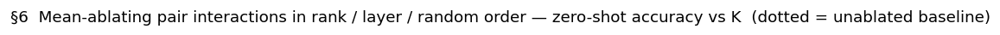

In [33]:
# Goal:  §6 -- the plot. rank/layer orders drawn individually; the 5 random runs as mean +/- band.
STYLE = {"rank ↓ (high Var first)": ("#2a78d6", "-"), "rank ↑ (low Var first)": ("#008300", "-"),
         "layer ↓ (last→first)":    ("#b3202b", "--"), "layer ↑ (first→last)":  ("#eb6834", "--")}
titled_6a = set()   # a blank top-row panel (fairface x RN50) must not swallow the column title
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.5 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d) not in CURVES:
            ax.set_visible(False); continue
        curves, base, P, chance = CURVES[(m, d)][:4]
        rnd = np.stack([curves[f"random {s}"][1] for s in range(N_RAND)])
        xr = curves["random 0"][0]
        ax.fill_between(xr, rnd.min(0), rnd.max(0), color="#c3c2b7", alpha=0.5, lw=0)
        ax.plot(xr, rnd.mean(0), color="#52514e", lw=1.2, label="random ×5 (mean)")
        for name, (col, ls) in STYLE.items():
            x, y = curves[name]
            ax.plot(x, y, color=col, ls=ls, lw=1.8, label=name)
        ax.axhline(base, color="#8a8a86", lw=0.8, ls=":", zorder=0)
        ax.axhline(chance, color="#8a8a86", lw=0.8, ls="-.", zorder=0)   # chance level
        ax.set_xscale("symlog"); ax.set_xlim(0, P); ax.set_ylim(0, max(base * 1.15, 5))
        if d not in titled_6a:
            ax.set_title(d, fontsize=8.5); titled_6a.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nzero-shot top-1 %", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("K pair interactions ablated", fontsize=7)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=5.8, loc="lower left", frameon=False)
fig.suptitle("§6  Mean-ablating pair interactions in rank / layer / random order — "
             "zero-shot accuracy vs K  (dotted = unablated baseline)", fontsize=11, y=1.005)
plt.tight_layout(); save_fig(fig, "06_ablation_rank_layer_random"); plt.show()

## §M — The metric, from first principles

### M.1 The pair interaction

For image $i$, text $j$, image-tower component $a$ and text-tower component $b$, write their
joint-space contributions as $x := c_a(i)$ and $y := c_b(j)$. Everything in this notebook is built on
their interaction $\langle x, y\rangle$.

Over the dataset each component has a mean and a PC basis (`svd_data_approx`: mean-centre, SVD,
truncate at the explained-variance level):

$$x = \mu_x + \sum_{i=1}^{r_x}\alpha_i\,p_i, \qquad y = \mu_y + \sum_{j=1}^{r_y}\beta_j\,q_j$$

$$\|p_i\| = \|q_j\| = 1, \qquad \alpha_i = \langle x-\mu_x,\,p_i\rangle, \qquad \beta_j = \langle y-\mu_y,\,q_j\rangle$$

$$\mathbb{E}[\alpha_i]=\mathbb{E}[\beta_j]=0, \qquad \operatorname{Var}(\alpha_i)=\sigma_i^2, \qquad \operatorname{Var}(\beta_j)=\tau_j^2$$

### M.2 Unrolling the dot product — four terms

$$\langle x,y\rangle = \Big\langle \mu_x + \sum_i \alpha_i p_i,\;\; \mu_y + \sum_j \beta_j q_j \Big\rangle$$

$$= \underbrace{\langle\mu_x,\mu_y\rangle}_{(1)\ \text{mean}\times\text{mean}} + \underbrace{\sum_j \beta_j\,\langle\mu_x,q_j\rangle}_{(2)\ \text{mean}_x\times\text{fluct}_y} + \underbrace{\sum_i \alpha_i\,\langle p_i,\mu_y\rangle}_{(3)\ \text{fluct}_x\times\text{mean}_y} + \underbrace{\sum_i\sum_j \alpha_i\beta_j\,\langle p_i,q_j\rangle}_{(4)\ \text{fluct}\times\text{fluct}}$$

The PC directions are **unit-norm**, so term (4)'s inner product is exactly a cosine:
$\langle p_i, q_j\rangle = \langle p_i,q_j\rangle / (\|p_i\|\|q_j\|) = \cos(p_i,q_j)$.

### M.3 Averaging — terms (2) and (3) die

$$\mathbb{E}\Big[\sum_j \beta_j\langle\mu_x,q_j\rangle\Big] = \sum_j \mathbb{E}[\beta_j]\,\langle\mu_x,q_j\rangle = 0, \qquad
\mathbb{E}\Big[\sum_i \alpha_i\langle p_i,\mu_y\rangle\Big] = \sum_i \mathbb{E}[\alpha_i]\,\langle p_i,\mu_y\rangle = 0$$

because PCA scores are centred by construction. Both scores being mean-zero gives
$\mathbb{E}[\alpha_i\beta_j] = \operatorname{Cov}(\alpha_i,\beta_j)$, hence the exact identity

$$\mathbb{E}[x \cdot y] = \underbrace{(\mu_x \cdot \mu_y)}_{\text{Baseline Mean Shift}} + \underbrace{\sum_i \sum_j \operatorname{Cov}(\alpha_i, \beta_j) \cos(p_i, q_j)}_{\text{Total Shared Variance}}$$

### M.4 Three consequences (they explain §6b's table)

1. **Covariance needs the joint distribution.** Under matched pairing $\alpha,\beta$ are coupled so
   $\operatorname{Cov}\neq 0$; under mismatched pairing $\operatorname{Cov}\to 0$ and
   $\mathbb{E}[x\cdot y]\to\mu_x\cdot\mu_y$. The Total Shared Variance *is* the part of the
   interaction that the pairing creates.

2. **$\Lambda_{\text{geo}}$ is the Cauchy–Schwarz bound, not the quantity.** Since
   $|\operatorname{Cov}(\alpha_i,\beta_j)| \le \sigma_i\tau_j$,

   $$\Big|\sum_{i,j}\operatorname{Cov}(\alpha_i,\beta_j)\cos(p_i,q_j)\Big| \le \sum_{i,j}\sigma_i\tau_j\big|\cos(p_i,q_j)\big|$$

   $\Lambda_{\text{geo}}$ swaps the measured covariance for its largest admissible value and drops the
   sign — it scores what a pair *could* share, not what it *does*. That is why it ranks poorly in
   §6b, and why the $\sigma\sigma$ weighting beats $\sigma^2\sigma^2$: $\sigma_i\tau_j$ is the bound.

3. **The mean shift cancels in the contrast**, and is invisible to $\arg\max_c$ (it is the same
   scalar for every class $c$):

   $$\mathbb{E}_{\mathcal{P}}[x\cdot y]-\mathbb{E}_{\mathcal{N}}[x\cdot y] = \sum_{i,j}\big[\operatorname{Cov}_{\mathcal{P}}(\alpha_i,\beta_j)-\operatorname{Cov}_{\mathcal{N}}(\alpha_i,\beta_j)\big]\cos(p_i,q_j) \approx \sum_{i,j}\operatorname{Cov}_{\mathcal{P}}(\alpha_i,\beta_j)\cos(p_i,q_j)$$

   **A prediction this licensed, and the data refuted.** From "$\arg\max_c$ cannot see $\mu_x\cdot\mu_y$"
   it was tempting to conclude that dropping it from a *ranking criterion* is free. §6b says otherwise:
   `Λ_CS(σσ) no μ` is markedly **worse** than `Λ_CS(σσ)+μ·μ` (61.1 vs 51.7 mean retained at K=100),
   and `Λ_geo no μ` is only a hair better than `Λ_geo+μ·μ` (57.2 vs 58.4). The inference was a
   non-sequitur: a term can contribute nothing to the decision yet still be *informative about which
   pairs matter* — pairs whose means align strongly are pairs that are engaged in the joint space at
   all, and that correlates with carrying the fluctuation signal too. **What a term contributes to the
   score and what it tells you about a pair are different questions.**

### M.5 Definition of $\mathbb{E}|S|$ and the $G$ criterion

$$S_{ab}(i,j) := \omega_{ab}(i,j)\,\cos\big(\hat c_a(i),\hat c_b(j)\big) = \frac{\big\langle \hat c_a(i), \hat c_b(j)\big\rangle}{\|\hat z_I(i)\|\,\|\hat z_T(j)\|}, \qquad \omega_{ab} = \frac{\|\hat c_a(i)\|\,\|\hat c_b(j)\|}{\|\hat z_I(i)\|\,\|\hat z_T(j)\|}$$

On a balanced 50/50 set — positives $\mathcal{P}$, negatives $\mathcal{N}$, $|\mathcal{P}|=|\mathcal{N}|=n$:

$$\mathbb{E}_{\mathcal{P}}\big[|S_{ab}|\big] := \frac{1}{n}\sum_{(i,j)\in\mathcal{P}}\big|S_{ab}(i,j)\big|, \qquad
G_{ab} := \mathbb{E}_{\mathcal{P}}\big[|S_{ab}|\big] - \mathbb{E}_{\mathcal{N}}\big[|S_{ab}|\big]$$

ranked **descending**. This is the accumulator rule "$-|S|$ if correct, $+|S|$ if wrong" up to sign:
$J_{ab} = \sum_{\mathcal{N}}|S_{ab}| - \sum_{\mathcal{P}}|S_{ab}| = -n\,G_{ab}$, so *lowest $J$* = *highest $G$*.
The $1\mp|S|$ variant adds the constant $2n$ to every pair and is therefore the **same ranking**
(checked in §6b: Spearman $\rho = 1.000000$).

**Why the absolute value, given M.3 gives an exact signed identity.** $|\Delta\mu|$ is (up to the
$\omega$ normalisation) the signed Total Shared Variance, yet $G$ beats it in §6b (32.5 vs 45.6 at
K=100). The reason is sign cancellation: a pair whose $S$ is positive for some matched classes and
negative for others has $\mathbb{E}_{\mathcal{P}}[S]\approx 0$, so $|\Delta\mu|$ calls it useless —
while $\mathbb{E}_{\mathcal{P}}[|S|]$ stays large. Such pairs still carry classification, because what
$\arg\max_c$ uses is the per-class pattern, not a globally consistent sign. $G$ measures engagement
magnitude conditional on the pairing; that is a different quantity from the identity, and the more
relevant one for ablation.

### §6b — Which ranking actually finds the pairs that carry the classification?

§6's `rank ↓` uses §1's `Var[S_ab]` over positive pairs and, as the curves show, it does **not**
collapse accuracy as fast as it should. That is a property of the criterion, not of the ablation:
`Var[S_ab]` is the variance across *(image, matched-caption)* pairs, so it mixes variation **across
images** with variation **across classes** — but `argmax_c` can only use the latter. A pair that
swings hugely from image to image while staying flat across `c` for each image contributes nothing
to the decision, yet §1 ranks it at the top.

Six criteria are put head-to-head on the same ablation, all "most important first":

| Criterion | What it measures |
|---|---|
| `Var[S_pos]` (§1) | loudness on matched captions — the current ranking |
| `Var[S_pos−S_neg]` | `= Var_pos + Var_neg`, the spread of the pos-minus-neg difference |
| `pooled Var (pos ∪ neg)` | variance of the pooled samples — includes the mean shift |
| `|Δμ|` | raw separation of the two means |
| `|PoS−0.5|` | standardised separation (§5's selectivity effect size) |
| **`between-class Var`** | `E_i[Var_c(S_ab(i,c))]` — the only part `argmax_c` can act on |
| **`E\|S\| gap: pos−neg`** | `E_pos[\|S\|] − E_neg[\|S\|]` — engages on matched captions, goes quiet on mismatched. This is the balanced-50/50 rule `J = Σ_neg\|S\| − Σ_pos\|S\|` (lowest `J` = most useful), rewritten as a descending key. Differs from `\|Δμ\|`: it differences `E[\|S\|]`, not `\|E[S]\|`, so a pair that fires *negatively* on a match still counts as engaged. The `1−\|S\|` / `1+\|S\|` **sum** variant adds a constant identical for every pair, so it is the same ranking — checked below. |
| **`Λ_geo(σ²σ²) no μ` / `Λ_CS(σσ) no μ`** | the same two with the Baseline Mean Shift dropped. §M.4: `μ_x·μ_y` is one scalar per pair, identical for every class, so `argmax_c` is blind to it and it cancels in the pos−neg contrast — it should be inert at best, dead weight at worst. |
| **`Graff −d_k`** / **`−d_∞ (affine)`** | the **affine** Grassmannian (Lim-Wong-Ye 2018). Our components *are* affine subspaces — `μ + span(PCs)` is literally `A + b` — so the embedding `A+b ↦ Span(A ∪ {b + e_{N+1}}) ⊂ Gr(k+1, N+1)` carries the mean **by construction**, rather than bolting on the dimensionally-mixed `Λ_geo + μ·μ`. Reduces to the linear Gr distance when both means are 0. |
| **`greedy PC match (σσ)`** | score B restricted to a **one-to-one PC matching**: take the strongest `σ_i σ_j \|cos(p_i,q_j)\|`, bank it, delete that `p_i` **and** that `q_j`, repeat until a list empties; sum the banked terms. Where `Λ_geo` sums all `r_x × r_y` PC combinations, this counts each PC at most once — the greedy sibling of the Hungarian **A**-metric. |
| **`log-loss Σlog(1∓\|S\|)`** | the *multiplicative* reading of the same rule: `Π_pos(1−\|S\|)·Π_neg(1+\|S\|)`, taken in log space so it stays a sum. Unlike the additive `J` this is **not** a constant offset — the log is nonlinear, so it punishes a large `\|S\|` on a wrong pair far harder than it rewards one on a correct pair. `1−\|S\|` is clamped at 1e-6 because `\|S\|` can exceed 1 for MLP pairs. |

**The lower the curve, the better the criterion.**

check — '1∓|S|' variant vs J:  Spearman ρ = 1.000000 | identical ordering: True
saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/06b_criteria_comparison.png


/tmp/ipykernel_807766/3485658784.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][0].legend(fontsize=5.5, loc="lower left", frameon=False)


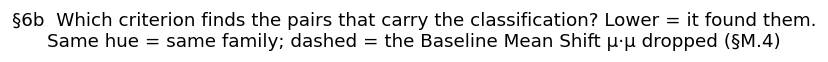

KeyError: 'criterion'

In [34]:
# Goal:  §6b -- compare the six ranking criteria on the same mean-ablation sweep.
# 12 criteria are computed; these 8 are drawn (a 9th generated hue is not a thing — the rest stay in
# the table). Hue = family, LINESTYLE = whether the Baseline Mean Shift is included, so each Λ sits
# directly against its own mean-less twin.
CRIT_STYLE2 = {
    "gap→target |±1−S|":       ("#4a3aa7", "-"),
    "gap→output |cos−S|":      ("#2a78d6", ":"),
    "spike q99.9|S|":          ("#d1651a", "-"),
    "d′ signed (Gauss sep)":   ("#e8118b", "-"),
    "Var[S_pos]  (§1)":        ("#2a78d6", "-"),
    "|Δμ| = |μ_pos−μ_neg|":    ("#008300", "-"),
    "E|S| gap: pos−neg":       ("#e87ba4", "-"),
    "greedy PC match (σσ)":    ("#eda100", "-"),
    "Λ_geo(σ²σ²)+μ·μ":         ("#1baf7a", "-"),
    "Λ_geo(σ²σ²) no μ":        ("#1baf7a", "--"),
    "Λ_CS(σσ)+μ·μ":            ("#4a3aa7", "-"),
    "Λ_CS(σσ) no μ":           ("#4a3aa7", "--"),
}
CRIT_COLOR = {k: v[0] for k, v in CRIT_STYLE2.items()}

# The "1 - |S| if correct else 1 + |S|" variant sums to  N + (sum_neg|S| - sum_pos|S|) = N + J:
# the 1s are an identical constant for every pair, so it is the SAME ranking. Verified, not assumed.
_a = pair_all(have[0], [d for d in DATASETS if (have[0], d, "pos") in R][0])
_J  = _a["absmean_neg"].astype(np.float64) - _a["absmean_pos"].astype(np.float64)
_J2 = (1 - _a["absmean_pos"].astype(np.float64)) + (1 + _a["absmean_neg"].astype(np.float64))
print("check — '1∓|S|' variant vs J:  Spearman ρ =",
      f"{spearmanr(_J.ravel(), _J2.ravel()).statistic:.6f}",
      "| identical ordering:", bool((np.argsort(_J, axis=None) == np.argsort(_J2, axis=None)).all()))
titled_6b = set()
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.5 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d) not in CURVES:
            ax.set_visible(False); continue
        curves, base, P, chance, crits = CURVES[(m, d)]
        rnd = np.stack([curves[f"random {s}"][1] for s in range(N_RAND)])
        xr = curves["random 0"][0]
        ax.fill_between(xr, rnd.min(0), rnd.max(0), color="#c3c2b7", alpha=0.5, lw=0)
        ax.plot(xr, rnd.mean(0), color="#52514e", lw=1.1, label="random ×5")
        for cname in crits:
            if cname not in CRIT_STYLE2: continue         # plotted subset; table has them all
            col, ls = CRIT_STYLE2[cname]
            x, y = curves[f"crit::{cname}"]
            ax.plot(x, y, color=col, ls=ls, lw=1.7, label=cname)
        ax.axhline(base, color="#8a8a86", lw=0.8, ls=":", zorder=0)
        ax.axhline(chance, color="#8a8a86", lw=0.8, ls="-.", zorder=0)
        ax.set_xscale("symlog"); ax.set_xlim(0, P); ax.set_ylim(0, max(base * 1.15, 5))
        if d not in titled_6b:
            ax.set_title(d, fontsize=8.5); titled_6b.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nzero-shot top-1 %", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("K pair interactions ablated", fontsize=7)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=5.5, loc="lower left", frameon=False)
fig.suptitle("§6b  Which criterion finds the pairs that carry the classification? Lower = it found them.\n"
             "Same hue = same family; dashed = the Baseline Mean Shift μ·μ dropped (§M.4)",
             fontsize=11, y=1.005)
plt.tight_layout(); save_fig(fig, "06b_criteria_comparison"); plt.show()

# Headline: the zero-shot accuracy degradation itself -- how much accuracy SURVIVES after ablating
# the top-K pairs each criterion selected, as a % of that cell's own unablated baseline.
def _at(x, y, K):
    i = int(np.searchsorted(x, K))
    return y[min(i, len(y) - 1)]

KS = (10, 100, 1000, 10000)
rows = []
for (m, d), (curves, base, P, chance, crits) in CURVES.items():
    # the layer sweeps (§6) join the table so the criteria are read against whole-layer ablation:
    # "layer ↓" = mean-ablate the LAST vision layer first and walk down to the earliest.
    for cname in list(crits) + ["layer ↓ (last→first)", "layer ↑ (first→last)", "random"]:
        if cname == "random":
            x = curves["random 0"][0]
            y = np.stack([curves[f"random {sd}"][1] for sd in range(N_RAND)]).mean(0)
        elif cname.startswith("layer"):
            x, y = curves[cname]
        else:
            x, y = curves[f"crit::{cname}"]
        rows.append(dict(model=m, dataset=d, criterion=cname,
                         **{f"K={K}": 100 * _at(x, y, K) / base for K in KS}))
per_cell = pd.DataFrame(rows)
downgrade = per_cell.groupby("criterion")[[f"K={K}" for K in KS]].mean().sort_values("K=100").round(1)
print("§6b  ZERO-SHOT ACCURACY RETAINED after mean-ablating the top-K pairs each criterion picked.")
print("     % of each cell's own unablated baseline; mean over all", per_cell.groupby(['model','dataset']).ngroups,
      "(model, dataset) cells.")
print("     LOWER = the criterion found the pairs that carry classification. 100 = no damage.\n")
display(downgrade)

# Per-DATASET breakdown at K=100 (mean over models), so the aggregate above is not taken on faith.
piv = per_cell.pivot_table(index="criterion", columns="dataset", values="K=100", aggfunc="mean").round(1)
piv = piv.loc[piv.mean(1).sort_values().index]
print("\n§6b  Same thing at K=100, PER DATASET (% of baseline retained, mean over models; lower = better):")
print(piv.to_string())
per_cell.round(1)

## §7 — Every pair in the (cos_sim, weight) plane

One point per component pair: `x = E_pos[cos(â,b̂)]`, `y = E_pos[ω_ab]`, **size ∝ `Var[S_ab]`**
(the §1 quantity), **colour + shape = family**. Because `S_ab = ω_ab · cos`, a pair's contribution to
the similarity is the *product* of its coordinates — the top-right corner is where a pair both agrees
in direction and carries norm. One panel per (model, dataset).

A mean alone hides whether a pair is *steady* or merely *averages* to that spot, so the spread of both
factors is shown two ways: **±1σ error bars** on the 40 loudest pairs here, and a companion **§7b**
plotting `σ(cos)` against `σ(ω)` for every pair — up means the weight swings sample to sample, right
means the direction agreement does. A vertical bar that runs off the bottom of the log axis is not a
glitch: it means `σ(ω) ≥ ω`, i.e. that pair's weight is as large as its own variability.

The requested red (`#e34948`) sat at ΔE 7.1 from the orange on the normal-vision floor (needs ≥15),
so the red is re-stepped to `#b3202b`; shape carries the same identity as a second channel.

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/07_cos_weight_plane.png


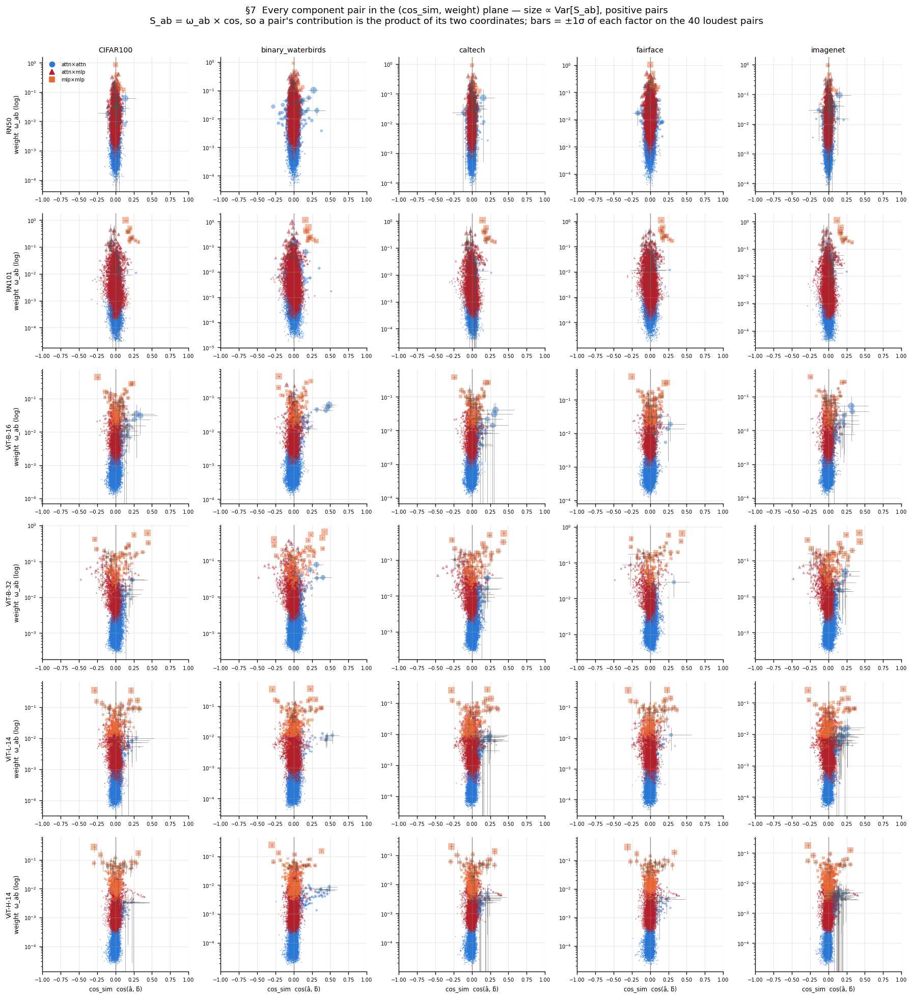

In [ ]:
# Goal:  §7 -- place every component pair on (mean cos) x (mean omega), sized by Var, coloured by family.
MAX_PTS  = 12000   # per panel; the top-500 by Var are always kept, the rest random-subsampled
N_ERRBAR = 40      # loudest pairs that get +-1 sigma bars on both axes

titled_7a = set()
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.7 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d, "pos") not in R:
            ax.set_visible(False); continue
        r = R[(m, d, "pos")]
        var = r["var"]; vmax = var.max()
        for fam, fmask in families(r).items():
            idx = np.flatnonzero(np.broadcast_to(fmask, var.shape).ravel())
            if len(idx) > MAX_PTS:                       # keep the loudest, subsample the rest
                order = idx[np.argsort(var.ravel()[idx])[::-1]]
                idx = np.concatenate([order[:500], np.random.default_rng(0).choice(order[500:], MAX_PTS - 500, replace=False)])
            x = r["cos"].ravel()[idx]; y = r["omega"].ravel()[idx]; v = var.ravel()[idx]
            ax.scatter(x, y, s=1.5 + 60 * (v / vmax) ** 0.35, c=FAM_COLOR[fam], marker=FAM_MARKER[fam],
                       alpha=0.45, lw=0, label=fam)
        # +-1 sigma on BOTH factors, for the loudest pairs only (223k error bars would be a smear).
        # A point's position is only a mean; these show whether that mean is stable or a shrug.
        top = np.argsort(var, axis=None)[::-1][:N_ERRBAR]
        tx, ty = np.unravel_index(top, var.shape)
        ax.errorbar(r["cos"][tx, ty], r["omega"][tx, ty],
                    xerr=np.sqrt(r["cos_var"][tx, ty]), yerr=np.sqrt(r["omega_var"][tx, ty]),
                    fmt="none", ecolor="#52514e", elinewidth=0.5, alpha=0.55, zorder=3)
        ax.set_yscale("log"); ax.set_xlim(-1, 1)
        ax.axvline(0, color="#8a8a86", lw=0.8, zorder=0)
        if d not in titled_7a:
            ax.set_title(d, fontsize=8.5); titled_7a.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nweight  ω_ab (log)", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("cos_sim  cos(â, b̂)", fontsize=7)
        ax.tick_params(labelsize=6)
handles = [Line2D([], [], ls="", marker=FAM_MARKER[f], color=FAM_COLOR[f], label=f) for f in FAM_COLOR]
axes[0][0].legend(handles=handles, fontsize=6, loc="upper left", frameon=False)
fig.suptitle("§7  Every component pair in the (cos_sim, weight) plane — size ∝ Var[S_ab], positive pairs\n"
             "S_ab = ω_ab × cos, so a pair's contribution is the product of its two coordinates; "
             "bars = ±1σ of each factor on the 40 loudest pairs", fontsize=11, y=1.005)
plt.tight_layout(); save_fig(fig, "07_cos_weight_plane"); plt.show()

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/07b_sigma_cos_vs_sigma_omega.png


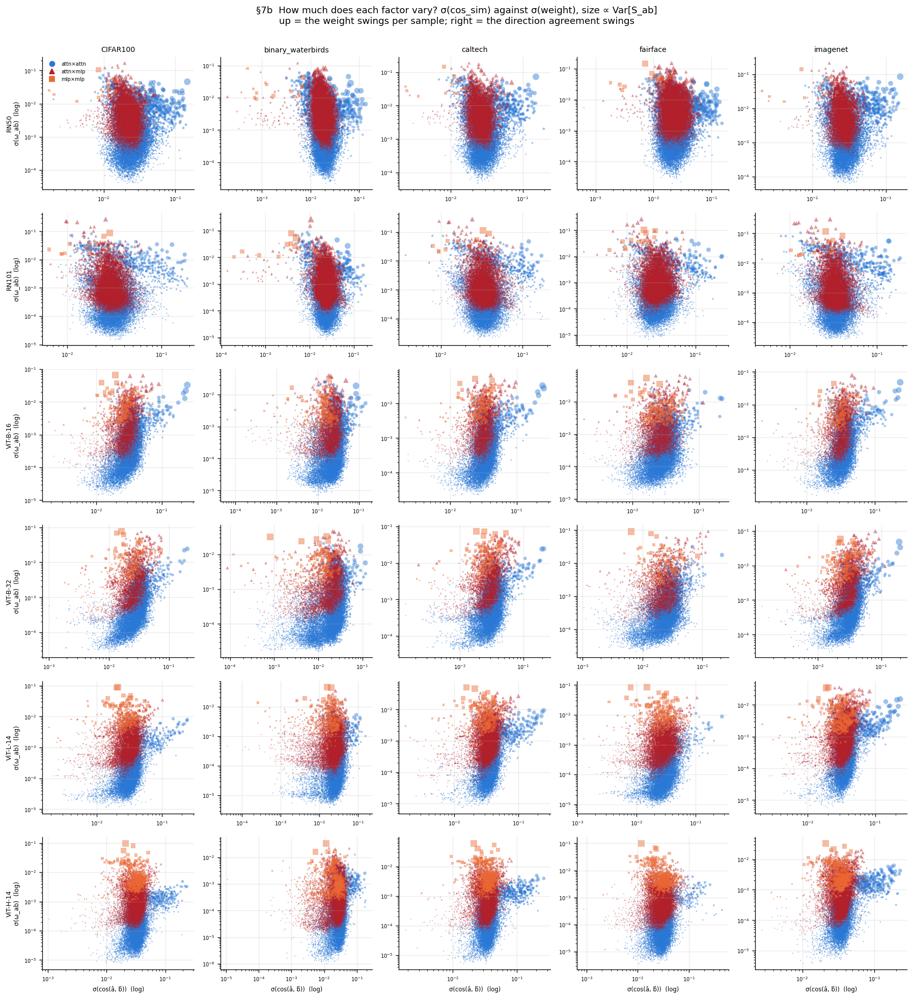

In [ ]:
# Goal:  §7b -- how much do the two FACTORS of S_ab themselves vary?  sigma(cos) against sigma(omega).
# Does:  a pair near the origin is a steady contributor; far out, its cos and/or weight swing per sample.
titled_7b = set()
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.7 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d, "pos") not in R:
            ax.set_visible(False); continue
        r = R[(m, d, "pos")]; var = r["var"]; vmax = var.max()
        for fam, fmask in families(r).items():
            idx = np.flatnonzero(np.broadcast_to(fmask, var.shape).ravel())
            if len(idx) > MAX_PTS:
                order = idx[np.argsort(var.ravel()[idx])[::-1]]
                idx = np.concatenate([order[:500],
                                      np.random.default_rng(0).choice(order[500:], MAX_PTS - 500, replace=False)])
            sx = np.sqrt(r["cos_var"].ravel()[idx]); sy = np.sqrt(r["omega_var"].ravel()[idx])
            v = var.ravel()[idx]
            ax.scatter(sx, sy, s=1.5 + 60 * (v / vmax) ** 0.35, c=FAM_COLOR[fam], marker=FAM_MARKER[fam],
                       alpha=0.45, lw=0, label=fam)
        ax.set_xscale("log"); ax.set_yscale("log")
        if d not in titled_7b:
            ax.set_title(d, fontsize=8.5); titled_7b.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nσ(ω_ab)  (log)", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("σ(cos(â, b̂))  (log)", fontsize=7)
        ax.tick_params(labelsize=6)
handles = [Line2D([], [], ls="", marker=FAM_MARKER[f], color=FAM_COLOR[f], label=f) for f in FAM_COLOR]
axes[0][0].legend(handles=handles, fontsize=6, loc="upper left", frameon=False)
fig.suptitle("§7b  How much does each factor vary? σ(cos_sim) against σ(weight), size ∝ Var[S_ab]\n"
             "up = the weight swings per sample; right = the direction agreement swings", fontsize=11, y=1.005)
plt.tight_layout(); save_fig(fig, "07b_sigma_cos_vs_sigma_omega"); plt.show()

## §8 — One tower's heads against the *other tower's full embedding*

The §1.2 marginal, `φ(a) = (â · ẑ_T)/(‖ẑ_I‖‖ẑ_T‖)`, factorises into exactly the same two numbers as a
pair does — a **weight** and a **cosine**:

$$ \varphi(a) \;=\; \underbrace{\frac{\|\hat a\|}{\|\hat z_I\|}}_{\text{weight}} \;\times\; \underbrace{\cos(\hat a,\, \hat z_T)}_{\text{cos\_sim}}, \qquad \sum_a \varphi(a) = \cos(\hat z_I, \hat z_T) $$

One point per **vision attention head**, drawn twice: once averaged over **positive** pairs and once
over **negative** pairs, joined by a line. The weight is a property of the head alone, so it does not
move between the two — **the horizontal shift is the head's entire class signal**. Heads far to the
right on positive pairs and near zero on negative pairs are the selective ones; the grey hyperbolae
are contours of constant φ(a).

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/08_head_vs_full_embedding.png


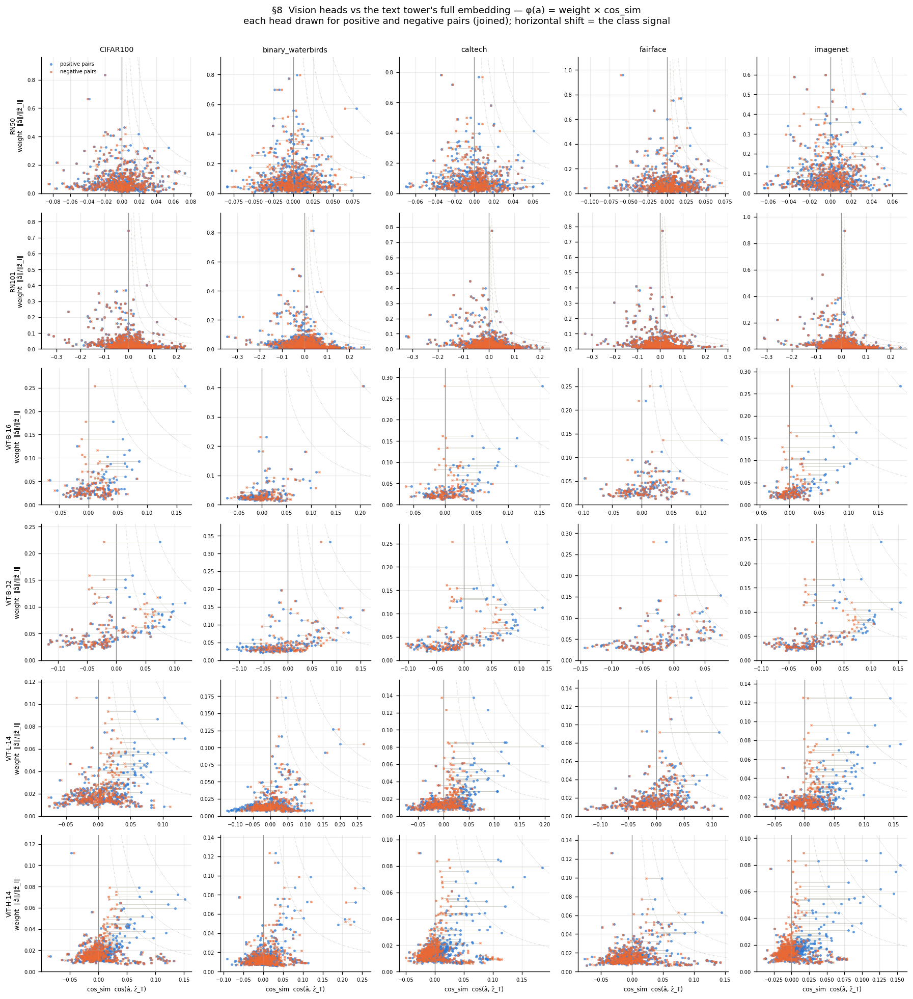

In [ ]:
# Goal:  §8 -- vision heads vs the TEXT tower's full embedding: weight x cosine, positive vs negative.
@torch.no_grad()
def head_vs_embedding(model, dataset, polarity, n_pairs=N_PAIRS):
    """Per vision attn head: mean ||a_hat||/||z_I|| and mean cos(a_hat, z_T) over `polarity` pairs."""
    p = _paths(model, dataset)
    lbl_v = np.load(p["lbl_v"]); lbl_t = np.load(p["lbl_t"])
    ii, jj = _sample_pairs(lbl_v, lbl_t, polarity, n_pairs, np.random.default_rng(0))
    A = _stack(torch.from_numpy(np.asarray(np.load(p["attn_v"], mmap_mode="r")[ii], dtype=np.float32)).to(device),
               torch.from_numpy(np.asarray(np.load(p["mlp_v"],  mmap_mode="r")[ii], dtype=np.float32)).to(device))
    B = _stack(torch.from_numpy(np.asarray(np.load(p["attn_t"], mmap_mode="r")[jj], dtype=np.float32)).to(device),
               torch.from_numpy(np.asarray(np.load(p["mlp_t"],  mmap_mode="r")[jj], dtype=np.float32)).to(device))
    zI, zT = A.sum(1), B.sum(1)
    w   = A.norm(dim=-1) / zI.norm(dim=-1)[:, None]                                  # [P,Kv]
    cos = torch.einsum("iad,id->ia", A, zT / zT.norm(dim=-1, keepdim=True)) / (A.norm(dim=-1) + 1e-30)
    return w.mean(0).cpu().numpy(), cos.mean(0).cpu().numpy()

HV = {}
for m in have:
    for d in DATASETS:
        if (m, d, "pos") not in R: continue
        for pol in POLARITY:
            HV[(m, d, pol)] = head_vs_embedding(m, d, pol)

titled_8 = set()
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.7 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d, "pos") not in R:
            ax.set_visible(False); continue
        r = R[(m, d, "pos")]; kv, _ = attn_block(r)
        for pol in POLARITY:
            w, c = HV[(m, d, pol)]
            ax.scatter(c[:kv], w[:kv], s=9, c=POL_COLOR[pol], marker=POL_MARKER[pol],
                       alpha=0.7, lw=0, label=f"{pol}itive pairs" if pol == "pos" else "negative pairs")
        wp, cp = HV[(m, d, "pos")]; wn, cn = HV[(m, d, "neg")]
        ax.plot([cn[:kv], cp[:kv]], [wn[:kv], wp[:kv]], color="#c3c2b7", lw=0.4, zorder=0)
        ax.axvline(0, color="#8a8a86", lw=0.8, zorder=0)
        # Limits come from the data; the phi contours are then clipped INTO that window. Drawing
        # phi/x unclipped lets it diverge near x=0 and drag the y-axis to ~30x the head weights.
        lo, hi = ax.get_xlim(); wmax = float(max(wp[:kv].max(), wn[:kv].max())) * 1.15
        ax.set_xlim(lo, hi); ax.set_ylim(0, wmax)
        phimax = float((wp[:kv] * cp[:kv]).max())
        for phi in (0.25 * phimax, 0.5 * phimax, phimax):   # contours of constant phi(a) = w * cos
            xs = np.linspace(max(lo, 1e-4), hi, 400)
            ys = phi / np.clip(xs, 1e-9, None)
            ok = (xs > 0) & (ys <= wmax)
            if ok.any():
                ax.plot(xs[ok], ys[ok], color="#c3c2b7", lw=0.6, ls=":", zorder=0)
        if d not in titled_8:
            ax.set_title(d, fontsize=8.5); titled_8.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nweight  ‖â‖/‖ẑ_I‖", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("cos_sim  cos(â, ẑ_T)", fontsize=7)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=6, loc="upper left", frameon=False)
fig.suptitle("§8  Vision heads vs the text tower's full embedding — φ(a) = weight × cos_sim\n"
             "each head drawn for positive and negative pairs (joined); horizontal shift = the class signal",
             fontsize=11, y=1.005)
plt.tight_layout(); save_fig(fig, "08_head_vs_full_embedding"); plt.show()

## §9 — Method C: Shapley values over the components (the counterfactual attribution)

Everything above splits the similarity with the **additive** identity `Σ_ab S_ab = cos(ẑ_I, ẑ_T)`,
which is exact — the denominator `‖ẑ_I‖‖ẑ_T‖` is one shared constant, so the numerator divides
cleanly. But that identity prices every component *at the full-coalition denominator*. The
counterfactual "what if this component were never there" is **not** linear: dropping `u_a` changes
`‖ẑ_I‖` for everyone, so `cos(ẑ_I − û_a, ẑ_T) ≠ cos(ẑ_I, ẑ_T) − φ(a)`.

Shapley values resolve exactly that. Players are the image tower's components
`{u_1, …, u_N}` (every head + every MLP slot); the characteristic function is

$$ v(S) \;=\; \cos\!\Big( \sum_{a \in S} u_a,\; B \Big), \qquad v(\varnothing) := 0 $$

with `B = ẑ_T` the paired text embedding, and

$$ \varphi_a \;=\; \sum_{S \subseteq N \setminus \{a\}} \frac{|S|!\,(N-|S|-1)!}{N!}\big[v(S \cup \{a\}) - v(S)\big] $$

**Why this is tractable.** `2^N` subsets is hopeless (N up to 545), but the standard permutation form
is not: sample random join orders, and for each one a single **cumulative sum** plus `N` cosines
gives every marginal contribution at once. The marginals **telescope** to `v(N) − v(∅) = cos(ẑ_I, ẑ_T)`,
so the *efficiency axiom holds exactly at any number of permutations* — Monte-Carlo error affects how
the credit is split between components, never the total. That is asserted below, not assumed.

**The question worth answering:** Shapley and the additive `φ(a)` both sum to the same total. Do they
*disagree* about which components matter? If they agree, the cheap linear attribution is vindicated
and the denominator non-linearity is a red herring. If they disagree, everything ranked by `φ(a)`
inherits the bias.

In [20]:
# Goal:  §9 -- Method C. Monte-Carlo Shapley values over the image tower's components vs the
#         additive marginal phi(a), with the efficiency axiom checked explicitly.
N_SHAP_PAIRS = 48    # (image, matched class-name) pairs Shapley is averaged over
N_PERM       = 128   # random join orders per pair
PERM_CHUNK   = 16

@torch.no_grad()
def shapley_components(model, dataset, polarity="pos", n_pairs=N_SHAP_PAIRS, n_perm=N_PERM, seed=0):
    """Shapley value of every IMAGE component under v(S) = cos(sum_{a in S} u_a, z_T), v({}) = 0.

    Returns (phi_shapley [Kv], phi_linear [Kv], cos_mean, efficiency_err).
    phi_linear is the additive share (a_hat . z_T)/(||z_I|| ||z_T||) that sums to the same total.
    """
    p = _paths(model, dataset)
    lbl_v = np.load(p["lbl_v"]); lbl_t = np.load(p["lbl_t"])
    ii, jj = _sample_pairs(lbl_v, lbl_t, polarity, n_pairs, np.random.default_rng(seed))
    A = _stack(torch.from_numpy(np.asarray(np.load(p["attn_v"], mmap_mode="r")[ii], dtype=np.float32)).to(device),
               torch.from_numpy(np.asarray(np.load(p["mlp_v"],  mmap_mode="r")[ii], dtype=np.float32)).to(device))
    B = _stack(torch.from_numpy(np.asarray(np.load(p["attn_t"], mmap_mode="r")[jj], dtype=np.float32)).to(device),
               torch.from_numpy(np.asarray(np.load(p["mlp_t"],  mmap_mode="r")[jj], dtype=np.float32)).to(device))
    zI, zT = A.sum(1), B.sum(1)
    P, Kv, d = A.shape
    g = torch.Generator(device="cpu").manual_seed(seed)

    phi = torch.zeros(P, Kv, dtype=torch.float64, device=device)
    for pi in range(P):
        u = A[pi]                                        # [Kv,d] the players
        b = zT[pi] / zT[pi].norm()                       # unit B
        for c0 in range(0, n_perm, PERM_CHUNK):
            npc = min(PERM_CHUNK, n_perm - c0)
            order = torch.stack([torch.randperm(Kv, generator=g) for _ in range(npc)]).to(device)  # [npc,Kv]
            seq = u[order]                               # [npc,Kv,d] players in join order
            cs = seq.cumsum(1)                           # [npc,Kv,d] running coalition sum
            val = (cs @ b) / (cs.norm(dim=-1) + 1e-30)   # [npc,Kv] = v(S_k), k = 1..Kv
            prev = torch.cat([torch.zeros(npc, 1, device=device), val[:, :-1]], 1)   # v({}) = 0
            marg = (val - prev).double()                 # marginal contribution at each position
            phi[pi].scatter_add_(0, order.reshape(-1), marg.reshape(-1))
    phi /= n_perm

    cos_true = (zI / zI.norm(dim=-1, keepdim=True) * zT / zT.norm(dim=-1, keepdim=True)).sum(-1)
    eff_err = (phi.sum(1) - cos_true.double()).abs().max().item()      # efficiency axiom
    lin = ((A @ (zT / zT.norm(dim=-1, keepdim=True))[:, :, None]).squeeze(-1)
           / zI.norm(dim=-1)[:, None]).double()                        # phi(a), sums to the same total
    return (phi.mean(0).cpu().numpy(), lin.mean(0).cpu().numpy(),
            cos_true.mean().item(), eff_err)

SHAP = {}
for m in have:
    for d in DATASETS:
        if (m, d, "pos") not in R: continue
        SHAP[(m, d)] = shapley_components(m, d)
        ph, li, cs, ee = SHAP[(m, d)]
        print(f"  {m:9s} x {d:18s} Σφ_shapley−cos = {ee:.2e}  (efficiency)   cos={cs:.4f}")

  RN50      x CIFAR100           Σφ_shapley−cos = 9.50e-08  (efficiency)   cos=0.1793
  RN50      x binary_waterbirds  Σφ_shapley−cos = 1.06e-07  (efficiency)   cos=0.2106
  RN50      x caltech            Σφ_shapley−cos = 1.02e-07  (efficiency)   cos=0.2286
  RN50      x fairface           Σφ_shapley−cos = 9.18e-08  (efficiency)   cos=0.1734
  RN50      x imagenet           Σφ_shapley−cos = 9.59e-08  (efficiency)   cos=0.2306
  RN101     x CIFAR100           Σφ_shapley−cos = 1.25e-07  (efficiency)   cos=0.4295
  RN101     x binary_waterbirds  Σφ_shapley−cos = 2.02e-07  (efficiency)   cos=0.4409
  RN101     x caltech            Σφ_shapley−cos = 1.62e-07  (efficiency)   cos=0.4633
  RN101     x fairface           Σφ_shapley−cos = 1.22e-07  (efficiency)   cos=0.4035
  RN101     x imagenet           Σφ_shapley−cos = 1.16e-07  (efficiency)   cos=0.4617
  ViT-B-16  x CIFAR100           Σφ_shapley−cos = 6.88e-08  (efficiency)   cos=0.2549
  ViT-B-16  x binary_waterbirds  Σφ_shapley−cos = 5.85

§9  Shapley (counterfactual) vs additive φ(a) — do they rank the components differently?
    max efficiency error over the grid: 2.02e-07  (exact ⇒ the MC estimate is unbiased in total, by construction)
    mean Pearson r = 0.9764 | mean Spearman ρ = 0.9620 | top-1 agrees in 28/30 cells


,model,dataset,efficiency |Σφ−cos|,Pearson r,Spearman ρ,top-1 same,top-10 Jaccard
0,RN50,CIFAR100,0.0,0.9950,0.9820,yes,1.0000
1,RN50,binary_waterbirds,0.0,0.9945,0.9771,yes,0.8182
2,RN50,caltech,0.0,0.9931,0.9762,yes,0.8182
3,RN50,fairface,0.0,0.9939,0.9899,yes,0.8182
4,RN50,imagenet,0.0,0.9952,0.9701,yes,0.8182
5,RN101,CIFAR100,0.0,0.9976,0.9585,yes,0.6667
6,RN101,binary_waterbirds,0.0,0.9974,0.9488,yes,0.8182
7,RN101,caltech,0.0,0.9977,0.9411,yes,0.5385
8,RN101,fairface,0.0,0.9974,0.9550,yes,0.5385
9,RN101,imagenet,0.0,0.9976,0.9469,yes,0.6667


saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/09_shapley_vs_additive.png


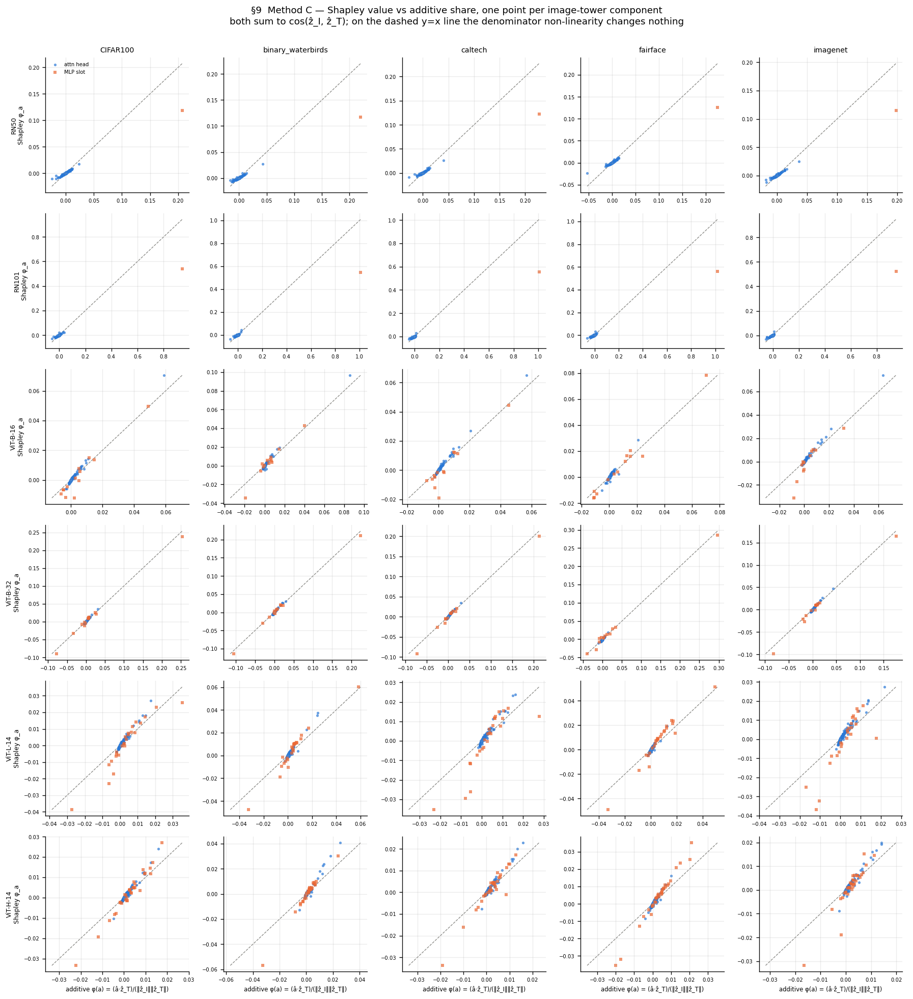

In [21]:
# Goal:  §9 -- do Shapley and the additive phi(a) actually disagree about which components matter?
rows = []
for (m, d), (ph, li, cs, ee) in SHAP.items():
    r = R[(m, d, "pos")]
    rows.append({"model": m, "dataset": d, "efficiency |Σφ−cos|": ee,
                 "Pearson r": np.corrcoef(ph, li)[0, 1],
                 "Spearman ρ": spearmanr(ph, li).statistic,
                 "top-1 same": "yes" if int(np.argmax(ph)) == int(np.argmax(li)) else "no",
                 "top-10 Jaccard": len(set(np.argsort(ph)[::-1][:10]) & set(np.argsort(li)[::-1][:10])) /
                                   len(set(np.argsort(ph)[::-1][:10]) | set(np.argsort(li)[::-1][:10]))})
shap_cmp = pd.DataFrame(rows)
print("§9  Shapley (counterfactual) vs additive φ(a) — do they rank the components differently?")
print(f"    max efficiency error over the grid: {shap_cmp['efficiency |Σφ−cos|'].max():.2e}  "
      f"(exact ⇒ the MC estimate is unbiased in total, by construction)")
print(f"    mean Pearson r = {shap_cmp['Pearson r'].mean():.4f} | mean Spearman ρ = "
      f"{shap_cmp['Spearman ρ'].mean():.4f} | top-1 agrees in "
      f"{(shap_cmp['top-1 same'] == 'yes').sum()}/{len(shap_cmp)} cells")
display(shap_cmp.round(4))

titled_9 = set()
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.7 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d) not in SHAP:
            ax.set_visible(False); continue
        ph, li, cs, ee = SHAP[(m, d)]
        r = R[(m, d, "pos")]
        is_attn = r["kind_v"] == "attn"
        for msk, col, mk, lab in [(is_attn, "#2a78d6", "o", "attn head"), (~is_attn, "#eb6834", "s", "MLP slot")]:
            ax.scatter(li[msk], ph[msk], s=10, c=col, marker=mk, alpha=0.7, lw=0, label=lab)
        lo = float(min(li.min(), ph.min())); hi = float(max(li.max(), ph.max()))
        ax.plot([lo, hi], [lo, hi], color="#8a8a86", lw=0.8, ls="--", zorder=0)   # y = x
        if d not in titled_9:
            ax.set_title(d, fontsize=8.5); titled_9.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nShapley φ_a", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("additive φ(a) = (â·ẑ_T)/(‖ẑ_I‖‖ẑ_T‖)", fontsize=7)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=6, loc="upper left", frameon=False)
fig.suptitle("§9  Method C — Shapley value vs additive share, one point per image-tower component\n"
             "both sum to cos(ẑ_I, ẑ_T); on the dashed y=x line the denominator non-linearity changes nothing",
             fontsize=11, y=1.005)
plt.tight_layout(); save_fig(fig, "09_shapley_vs_additive"); plt.show()

## §9b — Discriminative score $S = \mathbb{E}_{pos}[S_{ab}] - \mathbb{E}_{neg}[S_{ab}]$ per component pair

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/09b_pos_minus_neg_score.png


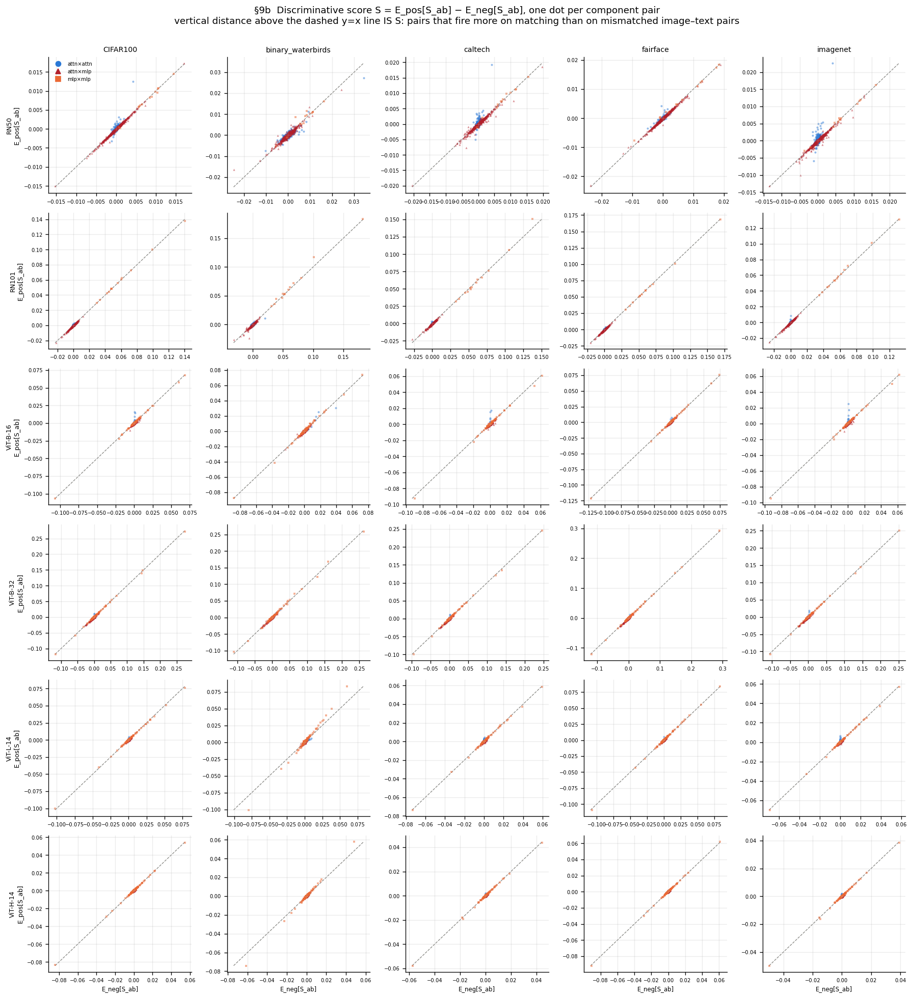

§9b  most-discriminative component pair per cell (max S = E_pos[S_ab] − E_neg[S_ab]):


,model,dataset,top pair,S=E_pos−E_neg,E_pos,E_neg
0,RN50,CIFAR100,V L14H22 ↔ T L10H4,0.0082,0.0124,0.0042
1,RN50,binary_waterbirds,V L14H22 ↔ T L12H-1,0.0084,-0.0163,-0.0247
2,RN50,caltech,V L14H22 ↔ T L10H4,0.0150,0.0192,0.0042
3,RN50,fairface,V L14H12 ↔ T L10H0,0.0047,0.0042,-0.0005
4,RN50,imagenet,V L14H22 ↔ T L10H4,0.0185,0.0226,0.0041
5,RN101,CIFAR100,V L31H16 ↔ T L11H3,0.0023,0.0034,0.0011
6,RN101,binary_waterbirds,V L0H-1 ↔ T L11H-1,0.0157,0.1174,0.1016
7,RN101,caltech,V L0H-1 ↔ T L12H-1,0.0135,0.1507,0.1372
8,RN101,fairface,V L31H14 ↔ T L9H4,0.0020,0.0039,0.0019
9,RN101,imagenet,V L31H16 ↔ T L11H3,0.0081,0.0087,0.0006


In [22]:
# Goal:  §9b -- per component pair, the discriminative score S = E_pos[S_ab] - E_neg[S_ab].
#         Same panel style as §9: one dot per pair, E_neg (x) vs E_pos (y); the signed vertical
#         distance from the dashed y=x line IS S. Coloured by family; the loudest pairs by |S| are
#         always drawn, the rest subsampled (like §7).
MAX_PTS_9b = 12000   # per panel; the top-500 by |S| always kept, the rest random-subsampled

rows_9b = []
titled_9b = set()
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.7 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d, "pos") not in R or (m, d, "neg") not in R:
            ax.set_visible(False); continue
        r  = R[(m, d, "pos")]
        ep = R[(m, d, "pos")]["mean"]                    # E_pos[S_ab]   [Kv,Kt]
        en = R[(m, d, "neg")]["mean"]                    # E_neg[S_ab]
        S  = ep - en                                     # the score
        aS = np.abs(S)
        for fam, fmask in families(r).items():
            idx = np.flatnonzero(np.broadcast_to(fmask, S.shape).ravel())
            if len(idx) > MAX_PTS_9b:                    # keep the loudest by |S|, subsample the rest
                order = idx[np.argsort(aS.ravel()[idx])[::-1]]
                idx = np.concatenate([order[:500],
                        np.random.default_rng(0).choice(order[500:], MAX_PTS_9b - 500, replace=False)])
            ax.scatter(en.ravel()[idx], ep.ravel()[idx], s=6, c=FAM_COLOR[fam], marker=FAM_MARKER[fam],
                       alpha=0.5, lw=0, label=fam)
        lo = float(min(en.min(), ep.min())); hi = float(max(en.max(), ep.max()))
        ax.plot([lo, hi], [lo, hi], color="#8a8a86", lw=0.8, ls="--", zorder=0)   # y = x  ->  S = 0
        # the single most-discriminative pair (max S), for the printed summary
        x, y = np.unravel_index(int(np.argmax(S)), S.shape)
        rows_9b.append({"model": m, "dataset": d,
                        "top pair": f"V L{r['layer_v'][x]}H{r['head_v'][x]} ↔ T L{r['layer_t'][y]}H{r['head_t'][y]}",
                        "S=E_pos−E_neg": float(S[x, y]), "E_pos": float(ep[x, y]), "E_neg": float(en[x, y])})
        if d not in titled_9b:
            ax.set_title(d, fontsize=8.5); titled_9b.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nE_pos[S_ab]", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("E_neg[S_ab]", fontsize=7)
        ax.tick_params(labelsize=6)
handles = [Line2D([], [], ls="", marker=FAM_MARKER[f], color=FAM_COLOR[f], label=f) for f in FAM_COLOR]
axes[0][0].legend(handles=handles, fontsize=6, loc="upper left", frameon=False)
fig.suptitle("§9b  Discriminative score S = E_pos[S_ab] − E_neg[S_ab], one dot per component pair\n"
             "vertical distance above the dashed y=x line IS S: pairs that fire more on matching "
             "than on mismatched image–text pairs", fontsize=11, y=1.005)
plt.tight_layout(); save_fig(fig, "09b_pos_minus_neg_score"); plt.show()

print("§9b  most-discriminative component pair per cell (max S = E_pos[S_ab] − E_neg[S_ab]):")
display(pd.DataFrame(rows_9b).round(4))

## §10 — Interaction evolution: cumulative reconstruction of the image–text cosine

For a (model, dataset) we walk the component **pairs** in a ranked order and accumulate their
similarity contribution `S_ab = ω_ab·cos(â,b̂)`. Because `Σ_ab S_ab = cos(ẑ_I, ẑ_T)` holds
**exactly over the full grid (attn heads AND mlp slots)**, the cumulative curve *lands on* the final
cosine — that landing is the agreement-with-final-results check.

Three curves per panel — **positive** (image × its class-name), **negative** (image × a wrong
class-name), **all** (pos+neg pooled) — each with a **±1σ band across cases** (how much the running
similarity varies image-to-image). Dashed horizontals mark each polarity's exact final cosine.
Shown for **all three orderings**: strength `|E[S_ab]|`, variance `Var[S_ab]` (the §1 ranking), and
`|Δμ|=|μ_pos−μ_neg|` (the §6b ablation-impact winner). The lower row shows, for the top pairs, the
per-pair **strength** `E[S_ab]` with **±σ** error bars for both polarities — the direct picture of
strength vs. variability (loud ≠ selective).

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/10_evolution_ViT-B-16_imagenet.png


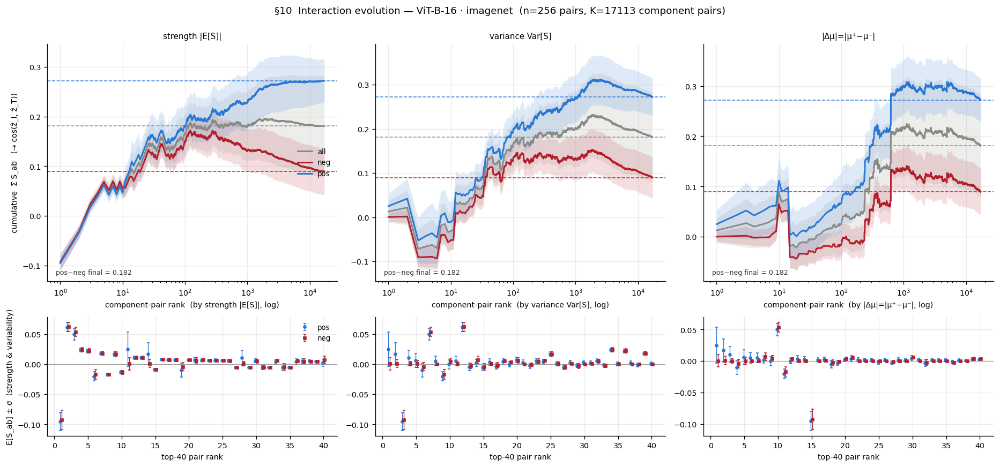

In [23]:
# Goal:  §10 -- raw S_ab (full grid) -> cumulative curves under 3 orderings, with across-case bands.
@torch.no_grad()
def evolution_data(model, dataset, n_pairs=N_PAIRS, top_n=40):
    """Recompute raw S for pos & neg (same images), then build the cumulative reconstruction
    curves + ±sigma bands for pos / neg / all, under each of the 3 pair orderings."""
    Sp, *_ = _pair_S(model, dataset, "pos", n_pairs)     # [n, Kv, Kt] on device
    Sn, *_ = _pair_S(model, dataset, "neg", n_pairs)
    n, Kv, Kt = Sp.shape
    Sp = Sp.reshape(n, -1); Sn = Sn.reshape(n, -1)       # [n, K]  full grid (heads + mlp)
    Sall = torch.cat([Sp, Sn], 0)                        # [2n, K] pooled

    mean_p, mean_n = Sp.mean(0), Sn.mean(0)              # [K]  strength per pair
    var_p          = Sp.var(0, unbiased=True)
    crit = {
        "strength |E[S]|":  (0.5 * (mean_p + mean_n)).abs(),
        "variance Var[S]":  var_p,
        "|Δμ|=|μ⁺−μ⁻|":     (mean_p - mean_n).abs(),
    }
    finals = {"pos": float(Sp.sum(1).mean()), "neg": float(Sn.sum(1).mean()),
              "all": float(Sall.sum(1).mean())}

    def curves(order):                                    # order: LongTensor [K] descending
        out = {}
        for name, X in (("pos", Sp), ("neg", Sn), ("all", Sall)):
            cum = X[:, order].cumsum(1)                   # [rows, K]
            out[name] = (cum.mean(0).cpu().numpy(), cum.std(0).cpu().numpy())
        return out

    res = {"finals": finals, "n": n, "K": Sp.shape[1], "orderings": {}}
    std_p, std_n = var_p.sqrt(), Sn.var(0, unbiased=True).sqrt()
    for cname, cval in crit.items():
        order = torch.argsort(cval, descending=True)
        top = order[:top_n].cpu().numpy()
        res["orderings"][cname] = dict(
            curves=curves(order),
            top_rank=np.arange(1, top_n + 1),
            top_mean_p=mean_p[top].cpu().numpy(), top_std_p=std_p[top].cpu().numpy(),
            top_mean_n=mean_n[top].cpu().numpy(), top_std_n=std_n[top].cpu().numpy(),
        )
    if device.startswith("cuda"): torch.cuda.empty_cache()
    return res


POL_C = {"pos": "#2a78d6", "neg": "#b3202b", "all": "#8a8a86"}

def plot_evolution(model, dataset, n_pairs=N_PAIRS, top_n=40):
    d = evolution_data(model, dataset, n_pairs, top_n)
    ords = list(d["orderings"])
    fig, axes = plt.subplots(2, len(ords), figsize=(5.2 * len(ords), 7.2),
                             gridspec_kw={"height_ratios": [2, 1]})
    for j, oname in enumerate(ords):
        o = d["orderings"][oname]
        ax = axes[0, j]
        x = np.arange(1, d["K"] + 1)
        for pol in ("all", "neg", "pos"):
            mu, sd = o["curves"][pol]
            ax.plot(x, mu, lw=1.8, color=POL_C[pol], label=pol, zorder=3)
            ax.fill_between(x, mu - sd, mu + sd, color=POL_C[pol], alpha=0.15, lw=0, zorder=1)
            ax.axhline(d["finals"][pol], ls="--", lw=1, color=POL_C[pol], alpha=0.9, zorder=2)
        ax.set_xscale("log"); ax.set_xlabel(f"component-pair rank  (by {oname}, log)")
        ax.set_title(oname)
        if j == 0:
            ax.set_ylabel("cumulative  Σ S_ab   (→ cos(ẑ_I, ẑ_T))")
            ax.legend(frameon=False, fontsize=8, loc="center right")
        # margin annotation
        ax.annotate(f"pos−neg final = {d['finals']['pos']-d['finals']['neg']:.3f}",
                    xy=(0.03, 0.03), xycoords="axes fraction", fontsize=7.5, color="#333")

        axb = axes[1, j]
        r = o["top_rank"]
        axb.errorbar(r - 0.12, o["top_mean_p"], yerr=o["top_std_p"], fmt="o", ms=3, lw=0.8,
                     color=POL_C["pos"], label="pos", capsize=1.5)
        axb.errorbar(r + 0.12, o["top_mean_n"], yerr=o["top_std_n"], fmt="s", ms=3, lw=0.8,
                     color=POL_C["neg"], label="neg", capsize=1.5)
        axb.axhline(0, lw=0.7, color="#999")
        axb.set_xlabel(f"top-{top_n} pair rank");
        if j == 0:
            axb.set_ylabel("E[S_ab] ± σ  (strength & variability)")
            axb.legend(frameon=False, fontsize=8)
    fig.suptitle(f"§10  Interaction evolution — {model} · {dataset}  "
                 f"(n={d['n']} pairs, K={d['K']} component pairs)", y=1.0, fontsize=11)
    plt.tight_layout(); save_fig(fig, f"10_evolution_{model}_{dataset}"); plt.show()

# default render
plot_evolution("ViT-B-16", "imagenet")

### §10 across models (fixed dataset)
Same figure per model, so the reconstruction shape and the pos–neg margin can be compared across
architectures. Raw `S` is recomputed per model (the moments cache does not store it), so this cell
is the heaviest in the notebook — trim `MODELS_EVO` if needed.

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/10_evolution_RN50_imagenet.png


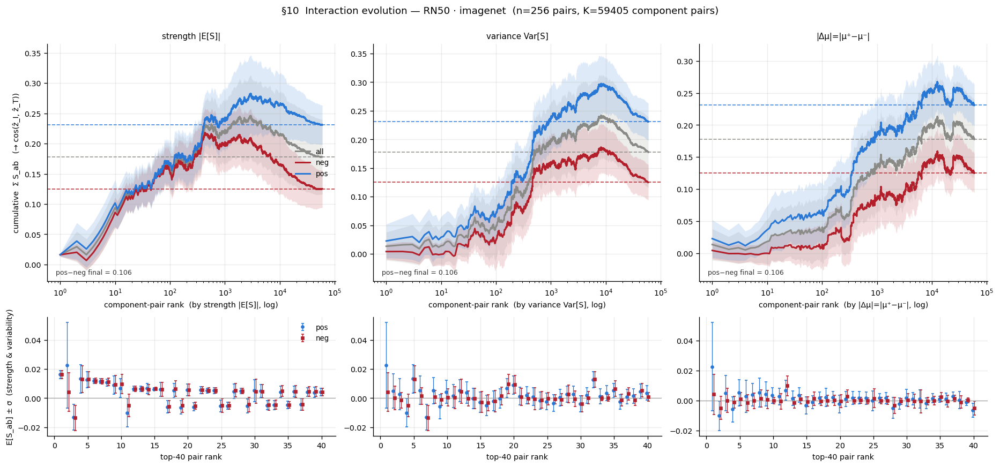

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/10_evolution_ViT-B-16_imagenet.png


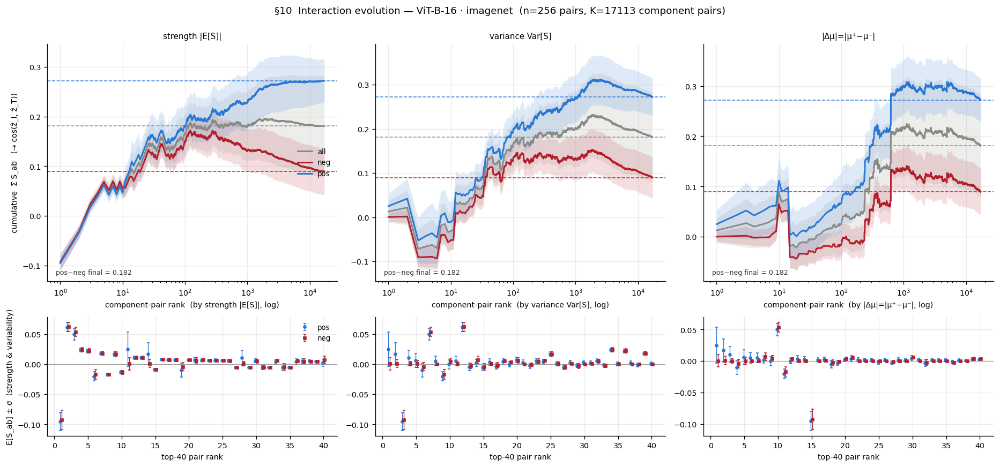

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/10_evolution_ViT-B-32_imagenet.png


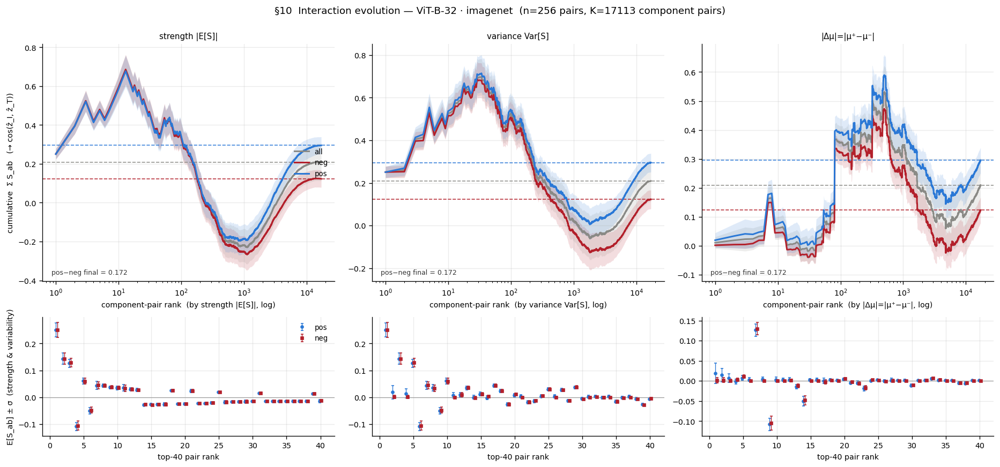

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/10_evolution_ViT-L-14_imagenet.png


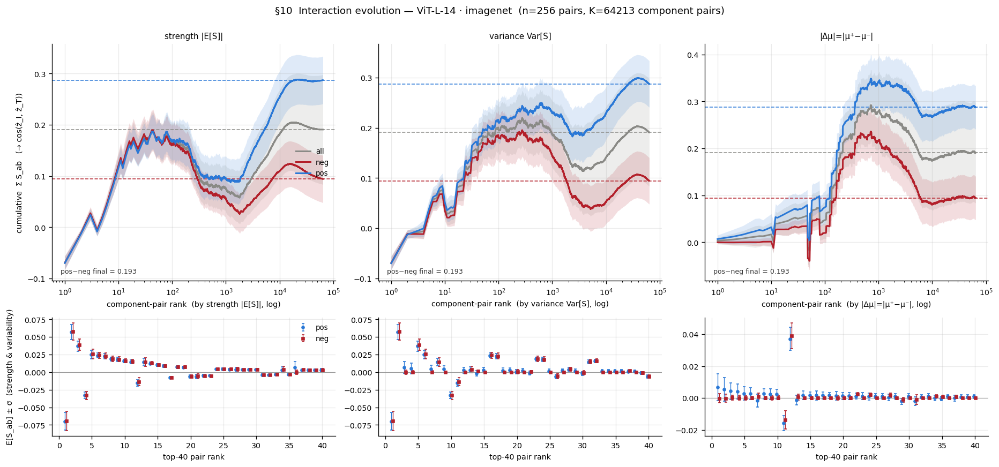

In [24]:
# Goal:  §10 -- run the evolution figure across models on one dataset.
DATASET_EVO = "imagenet"
MODELS_EVO  = ["RN50", "ViT-B-16", "ViT-B-32", "ViT-L-14"]
for m in MODELS_EVO:
    if (m, DATASET_EVO, "pos") in R:
        plot_evolution(m, DATASET_EVO)

### §10b — Evolution *using classes*
Instead of pooling into pos/neg, draw one cumulative curve **per class** (image × that class-name,
averaged over the class's images), ranked by strength. Each class builds the image–text cosine
through a different set of interactions; the grey band is the pooled-negative reference. Where a
class curve rises above the negatives is where its discriminative interactions kick in.

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/10b_evolution_classes_ViT-B-16_imagenet.png


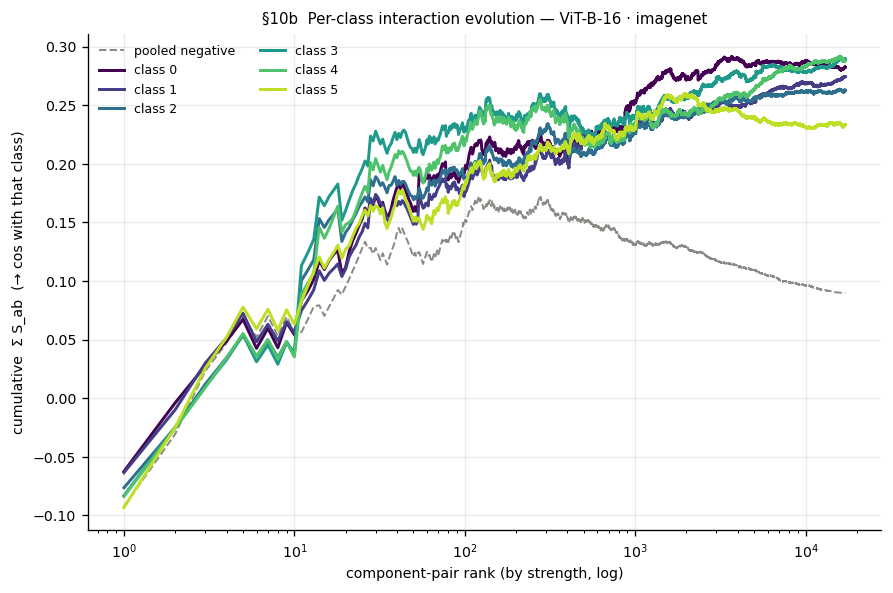

In [25]:
# Goal:  §10b -- per-class cumulative reconstruction (positive pairs), one line per class.
@torch.no_grad()
def _S_pairs(model, dataset, ii, jj, order=None):
    """Mean over the given aligned (image ii, class-row jj) pairs of the cumulative S curve."""
    p = _paths(model, dataset)
    A_all = np.load(p["attn_v"], mmap_mode="r"); M_all = np.load(p["mlp_v"], mmap_mode="r")
    B_all = np.load(p["attn_t"], mmap_mode="r"); Mt_all = np.load(p["mlp_t"], mmap_mode="r")
    cum_sum, cnt = None, 0
    for b0 in range(0, len(ii), BATCH):
        i, j = ii[b0:b0 + BATCH], jj[b0:b0 + BATCH]
        A = _stack(torch.from_numpy(np.asarray(A_all[i], dtype=np.float32)).to(device),
                   torch.from_numpy(np.asarray(M_all[i], dtype=np.float32)).to(device))
        B = _stack(torch.from_numpy(np.asarray(B_all[j], dtype=np.float32)).to(device),
                   torch.from_numpy(np.asarray(Mt_all[j], dtype=np.float32)).to(device))
        zI, zT = A.sum(1), B.sum(1)
        nA, nB = A.norm(dim=-1), B.norm(dim=-1)
        cos_ab = torch.bmm(A, B.transpose(1, 2)) / (nA[:, :, None] * nB[:, None, :] + 1e-30)
        omega  = (nA[:, :, None] * nB[:, None, :]) / (zI.norm(dim=-1) * zT.norm(dim=-1))[:, None, None]
        S = (omega * cos_ab).reshape(len(i), -1)         # [b, K]
        S = S[:, order] if order is not None else S
        s = S.cumsum(1).sum(0)
        cum_sum = s if cum_sum is None else cum_sum + s
        cnt += len(i)
    return (cum_sum / cnt).cpu().numpy()

def plot_evolution_classes(model, dataset, n_classes=6, n_img=64):
    p = _paths(model, dataset)
    lbl_v = np.load(p["lbl_v"]); lbl_t = np.load(p["lbl_t"])
    rng = np.random.default_rng(0)
    # ordering = strength on the pooled pos/neg S (reuse §10 ranking)
    Sp, *_ = _pair_S(model, dataset, "pos", N_PAIRS); Sn, *_ = _pair_S(model, dataset, "neg", N_PAIRS)
    str0 = (0.5 * (Sp.reshape(Sp.shape[0], -1).mean(0) + Sn.reshape(Sn.shape[0], -1).mean(0))).abs()
    order = torch.argsort(str0, descending=True); K = str0.numel()
    del Sp, Sn

    classes = [c for c in np.unique(lbl_t) if np.any(lbl_v == c)][:n_classes]
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(classes)))
    fig, ax = plt.subplots(figsize=(7.5, 5))
    x = np.arange(1, K + 1)
    # pooled-negative reference band
    ii = rng.permutation(np.flatnonzero(np.isin(lbl_v, np.unique(lbl_t))))[:256]
    jn = np.array([rng.choice(np.flatnonzero(lbl_t != lbl_v[i])) for i in ii])
    neg = _S_pairs(model, dataset, ii, jn, order)
    ax.plot(x, neg, lw=1.2, color="#8a8a86", ls="--", label="pooled negative", zorder=2)
    for c, col in zip(classes, cmap):
        img = np.flatnonzero(lbl_v == c); img = rng.permutation(img)[:n_img]
        jrow = np.full(len(img), np.flatnonzero(lbl_t == c)[0])
        cur = _S_pairs(model, dataset, img, jrow, order)
        ax.plot(x, cur, lw=1.8, color=col, label=f"class {int(c)}", zorder=3)
    ax.set_xscale("log"); ax.set_xlabel("component-pair rank (by strength, log)")
    ax.set_ylabel("cumulative  Σ S_ab  (→ cos with that class)")
    ax.set_title(f"§10b  Per-class interaction evolution — {model} · {dataset}")
    ax.legend(frameon=False, fontsize=7.5, ncol=2, loc="upper left")
    plt.tight_layout(); save_fig(fig, f"10b_evolution_classes_{model}_{dataset}"); plt.show()

plot_evolution_classes("ViT-B-16", "imagenet")

### §10c — Evolution ranked by the signed pos−neg metric $S = \mathbb{E}_{pos}[S_{ab}] - \mathbb{E}_{neg}[S_{ab}]$

Same §10 anatomy, but the component **pairs** are walked in the order of the **signed** §9b score
$S=\mu_{pos}-\mu_{neg}$ (descending), not $|\Delta\mu|$. Descending on the *signed* score means the
pairs that **open** the positive–negative margin come first and the pairs that **close** it (where a
wrong class-name is favoured, $\mu_{neg}>\mu_{pos}$) come last — so the pos curve pulls away from the
neg curve early and the two only reconverge to their exact finals over the anti-discriminative tail.
Bottom: per-pair strength $\mathbb{E}[S_{ab}]\pm\sigma$ for both polarities over the top pairs, with
the score $S$ itself overlaid.

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/10c_evolution_signed_ViT-B-16_imagenet.png


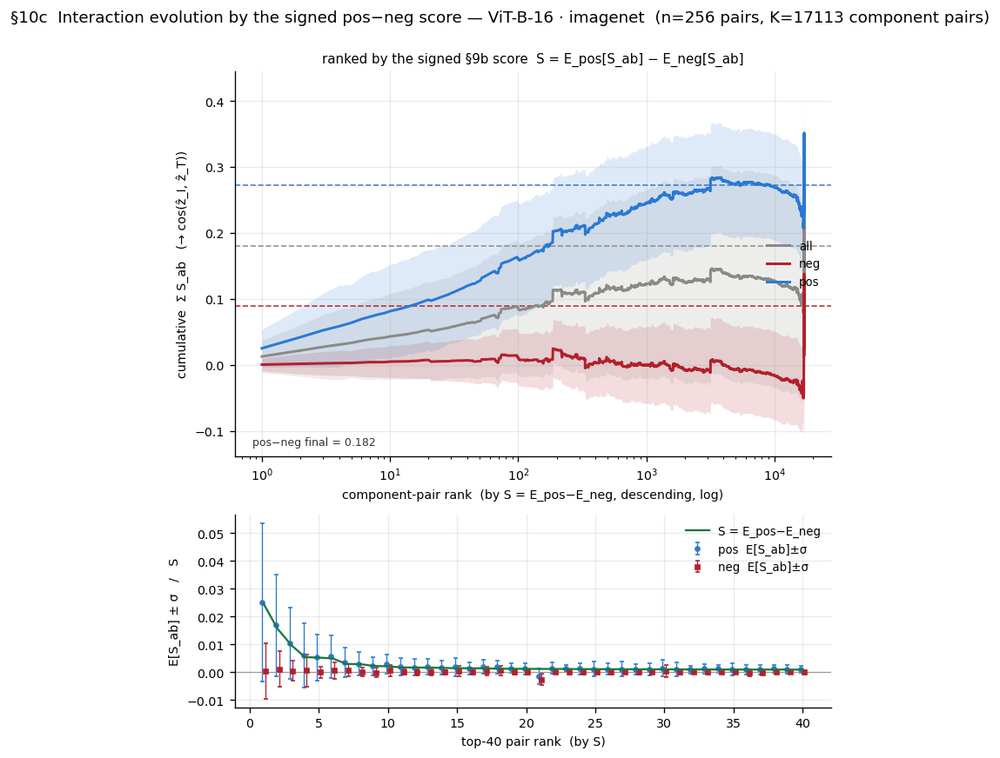

In [26]:
# Goal:  §10c -- §10-style cumulative reconstruction, walking component pairs by the SIGNED §9b
#         score S = E_pos[S_ab] - E_neg[S_ab] (descending). One ordering: margin-openers first.
@torch.no_grad()
def evolution_signed_data(model, dataset, n_pairs=N_PAIRS, top_n=40):
    """Raw S for pos & neg (same images), ordered by the signed per-pair score S = mu_pos - mu_neg."""
    Sp, *_ = _pair_S(model, dataset, "pos", n_pairs)     # [n, Kv, Kt]
    Sn, *_ = _pair_S(model, dataset, "neg", n_pairs)
    n = Sp.shape[0]
    Sp = Sp.reshape(n, -1); Sn = Sn.reshape(n, -1)       # [n, K] full grid (heads + mlp)
    Sall = torch.cat([Sp, Sn], 0)
    mean_p, mean_n = Sp.mean(0), Sn.mean(0)
    std_p,  std_n  = Sp.std(0, unbiased=True), Sn.std(0, unbiased=True)
    S_metric = mean_p - mean_n                           # the signed §9b score, per component pair
    order = torch.argsort(S_metric, descending=True)     # margin-openers first, margin-closers last
    finals = {"pos": float(Sp.sum(1).mean()), "neg": float(Sn.sum(1).mean()), "all": float(Sall.sum(1).mean())}
    curves = {}
    for name, X in (("pos", Sp), ("neg", Sn), ("all", Sall)):
        cum = X[:, order].cumsum(1)
        curves[name] = (cum.mean(0).cpu().numpy(), cum.std(0).cpu().numpy())
    top = order[:top_n].cpu().numpy()
    out = dict(finals=finals, n=n, K=Sp.shape[1], curves=curves, top_rank=np.arange(1, top_n + 1),
               top_S=S_metric[top].cpu().numpy(),
               top_mean_p=mean_p[top].cpu().numpy(), top_std_p=std_p[top].cpu().numpy(),
               top_mean_n=mean_n[top].cpu().numpy(), top_std_n=std_n[top].cpu().numpy())
    if device.startswith("cuda"): torch.cuda.empty_cache()
    return out

def plot_evolution_signed(model, dataset, n_pairs=N_PAIRS, top_n=40):
    d = evolution_signed_data(model, dataset, n_pairs, top_n)
    fig, axes = plt.subplots(2, 1, figsize=(6.6, 7.2), gridspec_kw={"height_ratios": [2, 1]})
    x = np.arange(1, d["K"] + 1)
    ax = axes[0]
    for pol in ("all", "neg", "pos"):
        mu, sd = d["curves"][pol]
        ax.plot(x, mu, lw=1.8, color=POL_C[pol], label=pol, zorder=3)
        ax.fill_between(x, mu - sd, mu + sd, color=POL_C[pol], alpha=0.15, lw=0, zorder=1)
        ax.axhline(d["finals"][pol], ls="--", lw=1, color=POL_C[pol], alpha=0.9, zorder=2)
    ax.set_xscale("log"); ax.set_xlabel("component-pair rank  (by S = E_pos−E_neg, descending, log)")
    ax.set_ylabel("cumulative  Σ S_ab   (→ cos(ẑ_I, ẑ_T))")
    ax.set_title("ranked by the signed §9b score  S = E_pos[S_ab] − E_neg[S_ab]")
    ax.legend(frameon=False, fontsize=8, loc="center right")
    ax.annotate(f"pos−neg final = {d['finals']['pos'] - d['finals']['neg']:.3f}",
                xy=(0.03, 0.03), xycoords="axes fraction", fontsize=7.5, color="#333")

    axb = axes[1]
    r = d["top_rank"]
    axb.errorbar(r - 0.12, d["top_mean_p"], yerr=d["top_std_p"], fmt="o", ms=3, lw=0.8,
                 color=POL_C["pos"], label="pos  E[S_ab]±σ", capsize=1.5)
    axb.errorbar(r + 0.12, d["top_mean_n"], yerr=d["top_std_n"], fmt="s", ms=3, lw=0.8,
                 color=POL_C["neg"], label="neg  E[S_ab]±σ", capsize=1.5)
    axb.plot(r, d["top_S"], lw=1.4, color="#1b7a3d", label="S = E_pos−E_neg", zorder=4)
    axb.axhline(0, lw=0.7, color="#999")
    axb.set_xlabel(f"top-{top_n} pair rank  (by S)")
    axb.set_ylabel("E[S_ab] ± σ   /   S")
    axb.legend(frameon=False, fontsize=8)
    fig.suptitle(f"§10c  Interaction evolution by the signed pos−neg score — {model} · {dataset}  "
                 f"(n={d['n']} pairs, K={d['K']} component pairs)", y=1.0, fontsize=11)
    plt.tight_layout(); save_fig(fig, f"10c_evolution_signed_{model}_{dataset}"); plt.show()

# default render
plot_evolution_signed("ViT-B-16", "imagenet")

## §11 — Top pairs by "smallest gap" criteria → zero-shot accuracy

Two ways to call a component pair `(a,b)` a *top* pair, each a **mean absolute gap** averaged over a
**balanced positive + negative set (equal size)**, top = **smallest** gap:

1. **gap to the final output** — how close the pair's own contribution is to the full similarity:
   $$C^{\text{out}}_{ab}=\tfrac12\big(\mathbb{E}_{\text{pos}}|\cos(\hat z_I,\hat z_T)-S_{ab}|
                                    +\mathbb{E}_{\text{neg}}|\cos(\hat z_I,\hat z_T)-S_{ab}|\big)$$
2. **gap to the target** — how close the pair's contribution is to the label you *want*
   (**+1** on a positive pair, **−1** on a negative pair):
   $$C^{\text{tgt}}_{ab}=\tfrac12\big(\mathbb{E}_{\text{pos}}|1-S_{ab}|+\mathbb{E}_{\text{neg}}|{-1}-S_{ab}|\big)$$

We **keep the top-K** pairs of each (mean-ablate the rest = sum over the kept pairs, the numerically
exact §6 evaluation) and plot **zero-shot top-1 vs K**, with **strength** `|E[S_ab]|` and a
**random-keep** band for reference. Dotted = unablated baseline, dash-dot = chance.

> Notes. `S_ab` is tiny (~1e-3), so both gaps are dominated by a constant and the *ranking* comes
> from the linearised terms: minimising `C^out` ⇔ maximising `E[S_ab]` co-varying with `cos`;
> minimising `C^tgt` ⇔ maximising the **signed** `Δμ = E_pos[S]−E_neg[S]` (the §6b ablation winner).
> So `C^tgt` selects *discriminative* pairs, while `C^out` selects pairs that merely *mimic* the
> similarity — the plots show only the former recovers accuracy.

In [27]:
# Goal:  §11 -- both "smallest gap" criteria, keep top-K, zero-shot accuracy vs K.
# Prereqs: R (cells 2-5) and the §6 defs _load_towers/_masked_sum/_acc (cell 23).
N_IMG_C, N_CKPT_C, N_RAND_C = 512, 16, 5

@torch.no_grad()
def gap_criteria(model, dataset, n_pairs=N_PAIRS):
    """Return (C_out, C_tgt): per-pair balanced mean |gap| to the full output and to the ±1 target."""
    Sp, *_ = _pair_S(model, dataset, "pos", n_pairs)      # [n,Kv,Kt]; Σ_pairs S = cos exactly
    Sn, *_ = _pair_S(model, dataset, "neg", n_pairs)
    simp, simn = Sp.sum((1, 2))[:, None, None], Sn.sum((1, 2))[:, None, None]
    C_out = 0.5 * ((simp - Sp).abs().mean(0) + (simn - Sn).abs().mean(0))
    C_tgt = 0.5 * ((1.0 - Sp).abs().mean(0) + (-1.0 - Sn).abs().mean(0))
    if device.startswith("cuda"): torch.cuda.empty_cache()
    return C_out.cpu().numpy(), C_tgt.cpu().numpy()

@torch.no_grad()
def keep_topk_accuracy(model, dataset, crit, ascending=True, n_img=N_IMG_C, n_ckpt=N_CKPT_C,
                       _towers=None):
    """Keep the top-K pairs by `crit` (ascending=smallest first); zero-shot top-1 vs K.
    Pass `_towers` to reuse a loaded/normalised (A,B,lbl_img,lbl_txt,base,chance) tuple."""
    if _towers is None:
        A, B, lbl_img, lbl_txt = _load_towers(model, dataset, n_img)
        zI, zT = A.sum(1), B.sum(1)
        A = A / zI.norm(dim=-1)[:, None, None]; B = B / zT.norm(dim=-1)[:, None, None]
        sim_full = (zI / zI.norm(dim=-1, keepdim=True)) @ (zT / zT.norm(dim=-1, keepdim=True)).T
        base = _acc(sim_full, lbl_img, lbl_txt); chance = 100.0 / len(np.unique(lbl_txt))
        _towers = (A, B, lbl_img, lbl_txt, base, chance)
    A, B, lbl_img, lbl_txt, base, chance = _towers
    Kv, Kt = crit.shape; P = Kv * Kt
    order = np.argsort(crit, axis=None)
    if not ascending: order = order[::-1]
    logK = np.unique(np.geomspace(1, P, n_ckpt).astype(int))
    xs, ys = [0], [chance]                                # keep 0 pairs -> exactly chance
    for K in logK:
        mask = torch.zeros(P, device=device)
        mask[torch.as_tensor(order[:int(K)].copy(), device=device)] = 1.0
        xs.append(int(K)); ys.append(_acc(_masked_sum(A, B, mask.view(Kv, Kt)), lbl_img, lbl_txt))
    return np.array(xs), np.array(ys), base, chance, P, _towers

# ---- build curves over the grid ----
CLOSE = {}
for m in have:
    for d in DATASETS:
        if (m, d, "pos") not in R: continue
        C_out, C_tgt = gap_criteria(m, d)
        a = pair_all(m, d); strength = np.abs((a["mean_pos"] + a["mean_neg"]) / 2)
        xo, yo, base, chance, P, tw = keep_topk_accuracy(m, d, C_out, ascending=True)
        xt, yt, *_               = keep_topk_accuracy(m, d, C_tgt, ascending=True, _towers=tw)
        xs, ys, *_               = keep_topk_accuracy(m, d, strength, ascending=False, _towers=tw)
        rnd = [keep_topk_accuracy(m, d, np.random.default_rng(100 + s).random(C_out.shape),
                                  ascending=True, _towers=tw)[1] for s in range(N_RAND_C)]
        CLOSE[(m, d)] = dict(xo=xo, yo=yo, xt=xt, yt=yt, xs=xs, ys=ys, rnd=np.stack(rnd),
                             base=base, chance=chance, P=P)
        print(f"  {m:9s} x {d:18s} base={base:5.1f}%  gap_tgt@100={yt[np.searchsorted(xt,100)]:5.1f}  "
              f"gap_out@100={yo[np.searchsorted(xo,100)]:4.1f}")
print("done —", len(CLOSE), "cells")

NameError: name '_load_towers' is not defined

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/11_smallest_gap_zeroshot.png


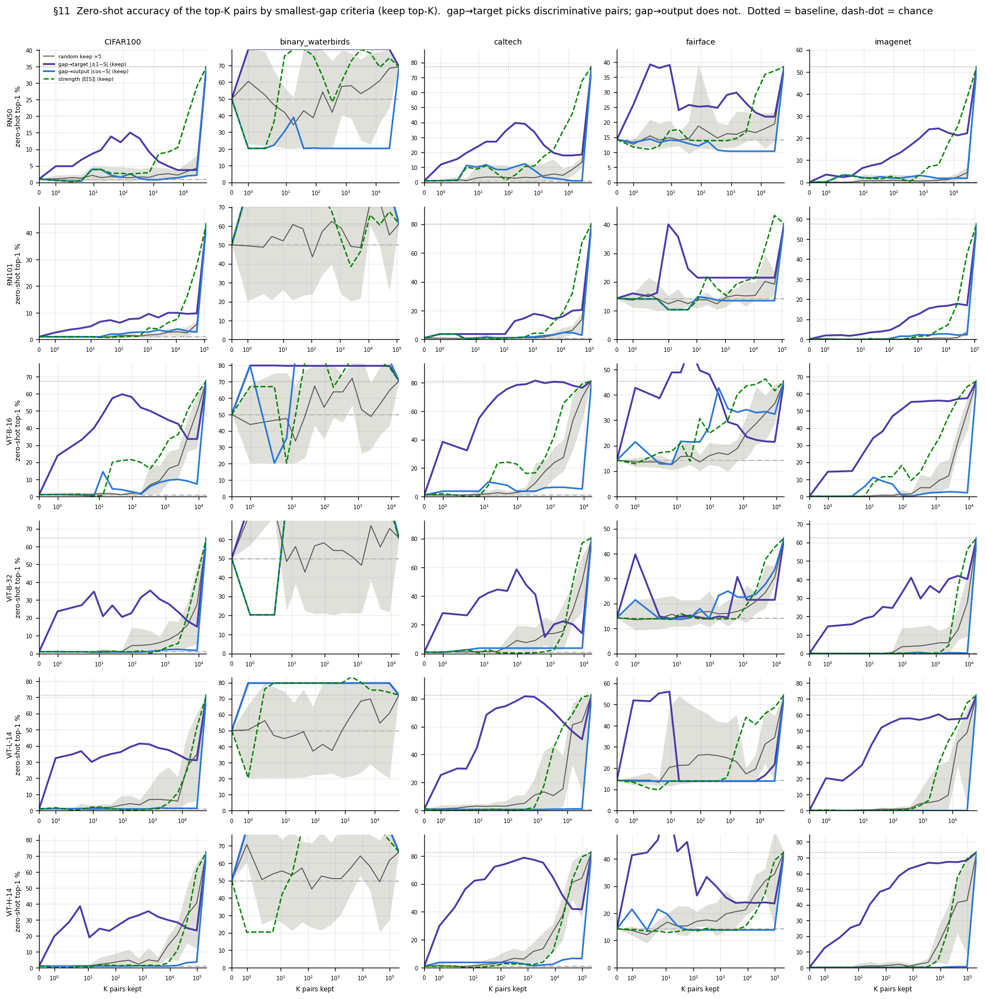

§11  Zero-shot accuracy RETAINED keeping top-K pairs (% of each cell's baseline; higher = better):


,K=10,K=100,K=1000
criterion,,,
gap→target,64.4,68.3,67.5
strength,29.7,33.0,41.9
gap→output,32.6,32.4,31.6
random,22.3,25.5,31.1


In [ ]:
# Goal:  §11 -- plot zero-shot accuracy vs K kept, one panel per (model, dataset).
titled = set()
fig, axes = plt.subplots(len(have), len(DATASETS), figsize=(15, 2.5 * len(have)), squeeze=False)
for ri, m in enumerate(have):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d) not in CLOSE:
            ax.set_visible(False); continue
        c = CLOSE[(m, d)]
        ax.fill_between(c["xo"], c["rnd"].min(0), c["rnd"].max(0), color="#c3c2b7", alpha=0.5, lw=0)
        ax.plot(c["xo"], c["rnd"].mean(0), color="#52514e", lw=1.0, label="random keep ×5")
        ax.plot(c["xt"], c["yt"], color="#4a3aa7", lw=2.0, label="gap→target |±1−S| (keep)")
        ax.plot(c["xo"], c["yo"], color="#2a78d6", lw=1.8, label="gap→output |cos−S| (keep)")
        ax.plot(c["xs"], c["ys"], color="#008300", lw=1.5, ls="--", label="strength |E[S]| (keep)")
        ax.axhline(c["base"], color="#8a8a86", lw=0.8, ls=":", zorder=0)
        ax.axhline(c["chance"], color="#8a8a86", lw=0.8, ls="-.", zorder=0)
        ax.set_xscale("symlog"); ax.set_xlim(0, c["P"]); ax.set_ylim(0, max(c["base"] * 1.15, 5))
        if d not in titled: ax.set_title(d, fontsize=8.5); titled.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nzero-shot top-1 %", fontsize=7.5)
        if ri == len(have) - 1: ax.set_xlabel("K pairs kept", fontsize=7)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=5.6, loc="upper left", frameon=False)
fig.suptitle("§11  Zero-shot accuracy of the top-K pairs by smallest-gap criteria (keep top-K).  "
             "gap→target picks discriminative pairs; gap→output does not.  Dotted = baseline, dash-dot = chance",
             fontsize=10.5, y=1.005)
plt.tight_layout(); save_fig(fig, "11_smallest_gap_zeroshot"); plt.show()

# summary: accuracy (% of baseline) retained when KEEPING top-K, per criterion
def _at(x, y, K): return y[min(int(np.searchsorted(x, K)), len(y) - 1)]
KS = (10, 100, 1000)
rows = []
for (m, d), c in CLOSE.items():
    for name, (x, y) in [("gap→target", (c["xt"], c["yt"])), ("gap→output", (c["xo"], c["yo"])),
                         ("strength", (c["xs"], c["ys"])), ("random", (c["xo"], c["rnd"].mean(0)))]:
        rows.append(dict(model=m, dataset=d, criterion=name,
                         **{f"K={K}": 100 * _at(x, y, K) / c["base"] for K in KS}))
summ = pd.DataFrame(rows).groupby("criterion")[[f"K={K}" for K in KS]].mean().round(1).sort_values("K=100", ascending=False)
print("§11  Zero-shot accuracy RETAINED keeping top-K pairs (% of each cell's baseline; higher = better):")
display(summ)

## §12 — Anatomy & concepts of the top pairs (gap→target)

Everything here dissects the **top-K component pairs by the §11 gap→target criterion** (the ones that
carry the classification). For a selected `(MODEL_SEL, DATASET_SEL)` we ask:

- **§12a** what are they — attn×attn / attn×mlp / mlp×mlp, and from which **layers** (vision & text)?
- **§12b** how PC-aligned are the two sides — **score_b = Λ_geo = Σ_i Σ_j σ_i²σ_j² |cos(p_i,q_j)|**
  (abs-cosine of PCs × variance explained, the head-alignment score).
- **§12c** what **concepts** do they cover — PClens top **texts** and top **images** for each side.
- **§12d** do the top pairs **change across datasets** (top-K overlap + rank correlation)?
- **§12e** **destruction** when mean-ablating the top-K vs K.
- **§12f** **project** the top-10 pairs' component means into the **3D PCA of the final embedding**,
  per modality and in the shared image+text space.

In [ ]:
# Goal:  §12 -- helpers: top pairs by gap→target, component labels, PClens concept loaders.
# Prereqs: §11 (gap_criteria), cells 2-5 (R), cell 18 (pc_bundles/pc_criterion), cell 23 (§6 eval defs).
from sklearn.decomposition import PCA

MODEL_SEL, DATASET_SEL = "ViT-B-16", "imagenet"
TOPK      = 50     # pairs for the composition / score_b / stability views
N_CONCEPT = 12     # pairs shown in the concept table
N_PROJ    = 10     # pairs projected in §12f
EXPL_DIR  = f"{OUT_DIR}/svd_data_approx_var99"

def top_pairs(model, dataset, k, crit=None):
    """Top-k (vision_idx, text_idx) pairs by smallest gap→target; returns pairs, crit matrix, (Kv,Kt)."""
    if crit is None:
        _, crit = gap_criteria(model, dataset)          # C_tgt
    Kv, Kt = crit.shape
    order = np.argsort(crit, axis=None)                  # ascending = smallest gap = top
    ab = [(int(o // Kt), int(o % Kt)) for o in order[:k]]
    return ab, crit, (Kv, Kt)

def comp_meta(model, dataset):
    r = R[(model, dataset, "pos")]
    return (r["kind_v"], r["layer_v"], r["head_v"]), (r["kind_t"], r["layer_t"], r["head_t"])

def comp_label(kind, layer, head):
    return f"L{int(layer)}·H{int(head)}" if kind == "attn" else f"L{int(layer)}·MLP"

def load_expl(model, dataset, tower):
    """PClens jsonl -> dict keyed ('attn',layer,head) / ('mlp',layer) -> entry."""
    f = (f"{EXPL_DIR}/{dataset}_{model}_all_image.jsonl" if tower == "image"
         else f"{EXPL_DIR}/{dataset}_classnames_{model}_all_text.jsonl")
    d = {}
    for line in open(f):
        e = json.loads(line)
        if e["component"] == "attn":  d[("attn", e["layer"], e["head"])] = e
        elif e["component"] == "mlp": d[("mlp", e["layer"])] = e
    return d

def _entry(expl, kind, layer, head):
    return expl.get((kind, int(layer), int(head))) if kind == "attn" else expl.get(("mlp", int(layer)))

_STOP = set("an image of a the with and or in on to for is are it its of thing things "
            "made pattern patterns something".split())

def pc_texts(entry, n_pc=2, n_txt=3):
    """Top texts across the top PCs -> list of (pc_idx, [texts])."""
    out = []
    for i, pc in enumerate(entry["embeddings_sort"][:n_pc]):
        txts = [list(t.values())[0] for t in pc["text"][:n_txt]]
        out.append((i, txts))
    return out

def pc_image_classes(entry, n_pc=2, n_img=3):
    out = []
    for i, pc in enumerate(entry["embeddings_sort"][:n_pc]):
        cls = [t.get(f"class_max_{j}") for j, t in enumerate(pc["image"][:n_img])]
        out.append((i, cls))
    return out

def _tokens(texts):
    w = set()
    for t in texts:
        for tok in t.lower().replace(".", "").replace(",", "").split():
            if tok not in _STOP and len(tok) > 2: w.add(tok)
    return w

print("helpers ready · selection:", MODEL_SEL, DATASET_SEL)

helpers ready · selection: ViT-B-16 imagenet


### §12a — Composition of the top pairs: family & layers

In [ ]:
# Goal:  §12a -- family (attn×attn/attn×mlp/mlp×mlp) and per-side layer distribution of the top-K.
ab, Ctgt, (Kv, Kt) = top_pairs(MODEL_SEL, DATASET_SEL, TOPK)
(kv, lv, hv), (kt, lt, ht) = comp_meta(MODEL_SEL, DATASET_SEL)

def fam(a, b):
    return f"{'attn' if kv[a]=='attn' else 'mlp'}×{'attn' if kt[b]=='attn' else 'mlp'}"
fams = [fam(a, b) for a, b in ab]
famct = pd.Series(fams).value_counts()
row = pd.DataFrame([{
    "top-K": TOPK,
    "attn×attn %": 100 * famct.get("attn×attn", 0) / TOPK,
    "attn×mlp %":  100 * (famct.get("attn×mlp", 0) + famct.get("mlp×attn", 0)) / TOPK,
    "mlp×mlp %":   100 * famct.get("mlp×mlp", 0) / TOPK,
    "vis mlp-side %": 100 * np.mean([kv[a] == "mlp" for a, _ in ab]),
    "txt mlp-side %": 100 * np.mean([kt[b] == "mlp" for _, b in ab]),
    "vis layer med": int(np.median([lv[a] for a, _ in ab])),
    "txt layer med": int(np.median([lt[b] for _, b in ab])),
}]).round(1)
print(f"§12a  Composition of the top-{TOPK} gap→target pairs — {MODEL_SEL} · {DATASET_SEL}")
display(row)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
famct.reindex(["attn×attn", "attn×mlp", "mlp×attn", "mlp×mlp"]).dropna().plot.bar(
    ax=axes[0], color="#2a78d6"); axes[0].set_title("pair family"); axes[0].tick_params(axis='x', rotation=20)
axes[1].hist([lv[a] for a, _ in ab], bins=np.arange(int(lv.max()) + 2) - 0.5, color="#008300")
axes[1].set_title("vision layer"); axes[1].set_xlabel("layer")
axes[2].hist([lt[b] for _, b in ab], bins=np.arange(int(lt.max()) + 2) - 0.5, color="#b3202b")
axes[2].set_title("text layer"); axes[2].set_xlabel("layer")
fig.suptitle(f"§12a  top-{TOPK} pair composition — {MODEL_SEL} · {DATASET_SEL}", y=1.03)
plt.tight_layout(); save_fig(fig, f"12a_composition_{MODEL_SEL}_{DATASET_SEL}"); plt.show()

NameError: name 'gap_criteria' is not defined

### §12b — PC alignment of the top pairs (score_b = Λ_geo)

§12b  score_b (Λ_geo) — ViT-B-16 · imagenet
  top-50: median=8.042e-06  mean=2.013e-05
  all pairs: median=5.135e-09  mean=2.676e-07
  top-50 are in the 100th pct of score_b on average
  Spearman(gap→target, score_b) = -0.195   (gap small = top, so negative ⇒ top pairs are MORE aligned)
saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/12b_scoreb_ViT-B-16_imagenet.png


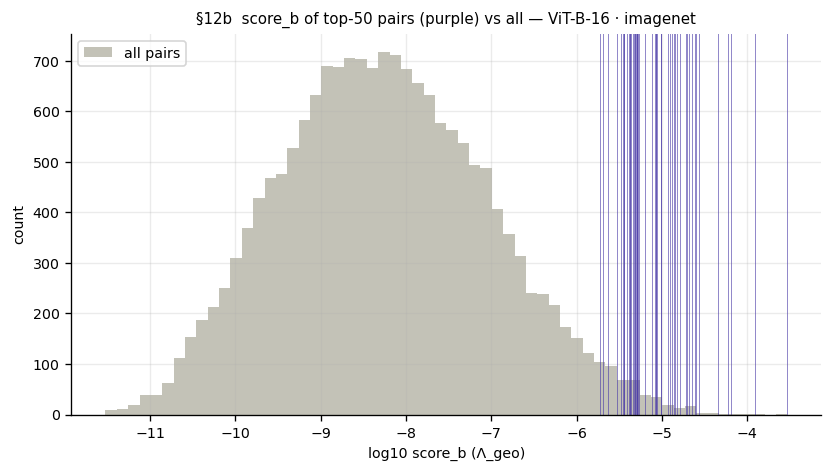

In [ ]:
# Goal:  §12b -- score_b = Σσ²σ²|cos(PC,PC)| for the top pairs vs all pairs; are they PC-aligned?
scoreb = pc_criterion(MODEL_SEL, DATASET_SEL)["shared_var2"]     # [Kv,Kt] = Λ_geo
sb_top = np.array([scoreb[a, b] for a, b in ab])
sb_all = scoreb.ravel()
from scipy.stats import spearmanr as _sp
rho = _sp(Ctgt.ravel(), scoreb.ravel()).statistic          # criterion vs score_b (note: Ctgt small=top)
print(f"§12b  score_b (Λ_geo) — {MODEL_SEL} · {DATASET_SEL}")
print(f"  top-{TOPK}: median={np.median(sb_top):.3e}  mean={sb_top.mean():.3e}")
print(f"  all pairs: median={np.median(sb_all):.3e}  mean={sb_all.mean():.3e}")
print(f"  top-{TOPK} are in the {100*np.mean(sb_all[:,None] < sb_top[None,:].mean()):.0f}th pct of score_b on average")
print(f"  Spearman(gap→target, score_b) = {rho:.3f}   (gap small = top, so negative ⇒ top pairs are MORE aligned)")
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(sb_all + 1e-12), bins=60, color="#c3c2b7", label="all pairs")
for v in sb_top: ax.axvline(np.log10(v + 1e-12), color="#4a3aa7", lw=0.6, alpha=0.6)
ax.set_xlabel("log10 score_b (Λ_geo)"); ax.set_ylabel("count")
ax.set_title(f"§12b  score_b of top-{TOPK} pairs (purple) vs all — {MODEL_SEL} · {DATASET_SEL}")
ax.legend(); plt.tight_layout(); save_fig(fig, f"12b_scoreb_{MODEL_SEL}_{DATASET_SEL}"); plt.show()

### §12c — Concept analysis via PClens (top texts + images, both sides)

In [ ]:
# Goal:  §12c -- for each top pair, PClens top texts/images of the vision & text component + agreement.
EXPL_V = load_expl(MODEL_SEL, DATASET_SEL, "image")
EXPL_T = load_expl(MODEL_SEL, DATASET_SEL, "text")
rows = []
for rank, (a, b) in enumerate(ab[:N_CONCEPT], 1):
    ev = _entry(EXPL_V, kv[a], lv[a], hv[a]); et = _entry(EXPL_T, kt[b], lt[b], ht[b])
    if ev is None or et is None: continue
    vt = pc_texts(ev, 2, 3); tt = pc_texts(et, 2, 3)
    vi = pc_image_classes(ev, 1, 3); ti = pc_image_classes(et, 1, 3)
    jac = len(_tokens(sum([t for _, t in vt], [])) & _tokens(sum([t for _, t in tt], []))) / \
          (len(_tokens(sum([t for _, t in vt], [])) | _tokens(sum([t for _, t in tt], []))) + 1e-9)
    rows.append(dict(
        rank=rank,
        vision=comp_label(kv[a], lv[a], hv[a]),
        vision_text="; ".join(vt[0][1]),
        vision_imgcls="; ".join(str(c) for c in vi[0][1]),
        text=comp_label(kt[b], lt[b], ht[b]),
        text_text="; ".join(tt[0][1]),
        score_b=f"{scoreb[a,b]:.2e}",
        word_jac=round(jac, 2),
    ))
concepts = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
print(f"§12c  Concepts of the top-{N_CONCEPT} gap→target pairs — {MODEL_SEL} · {DATASET_SEL}")
print(f"  mean vision↔text top-text word Jaccard = {concepts['word_jac'].mean():.2f}")
display(concepts)

§12c  Concepts of the top-12 gap→target pairs — ViT-B-16 · imagenet
  mean vision↔text top-text word Jaccard = 0.09


,rank,vision,vision_text,vision_imgcls,text,text_text,score_b,word_jac
0,1,L11·H5,An image of a reptile.; An image of a small lizard.; An ...,Samoyed; Samoyed; Old English Sheepdog,L9·H6,An image of an Otterhound.; An image of a Flat-Coated Re...,2.96e-04,0.00
1,2,L11·H5,An image of a reptile.; An image of a small lizard.; An ...,Samoyed; Samoyed; Old English Sheepdog,L11·H7,An image of a fluffy dog.; An image of a dog.; An image ...,1.24e-04,0.25
2,3,L11·H5,An image of a reptile.; An image of a small lizard.; An ...,Samoyed; Samoyed; Old English Sheepdog,L10·H6,An image of a Scottish Terrier.; An image of a Lakeland ...,6.45e-05,0.00
3,4,L11·H10,An image of a black and brown animal.; An image of a bro...,small white butterfly; Arctic fox; sulphur-crested cockatoo,L11·H2,An image of an orange-brown animal.; An image of a rust-...,5.96e-05,0.27
4,5,L11·H7,An image of a tall drinking vessel.; An image of a drink...,can opener; letter opener; crate,L9·H0,An image of a pitcher with a spout.; An image of a woodw...,2.51e-05,0.18
5,6,L11·H5,An image of a reptile.; An image of a small lizard.; An ...,Samoyed; Samoyed; Old English Sheepdog,L11·H0,An image of a large breed canine.; An image of a large-b...,4.51e-05,0.12
6,7,L11·H4,An image of a dog with a friendly expression.; An image ...,wooden spoon; plastic bag; corn,L11·H0,An image of a large breed canine.; An image of a large-b...,1.96e-05,0.04
7,8,L11·H7,An image of a tall drinking vessel.; An image of a drink...,can opener; letter opener; crate,L8·H0,An image of a sphere.; An image of a spherical shape.; A...,1.40e-05,0.00
8,9,L11·H5,An image of a reptile.; An image of a small lizard.; An ...,Samoyed; Samoyed; Old English Sheepdog,L9·H4,An image of a Newfoundland dog.; An image of a Flat-Coat...,2.06e-05,0.06
9,10,L11·H5,An image of a reptile.; An image of a small lizard.; An ...,Samoyed; Samoyed; Old English Sheepdog,L7·H2,An image of an animal with a large face.; An image of an...,1.94e-05,0.06


### §12d — Do the top pairs change across datasets?

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/12d_cross_dataset_ViT-B-16.png


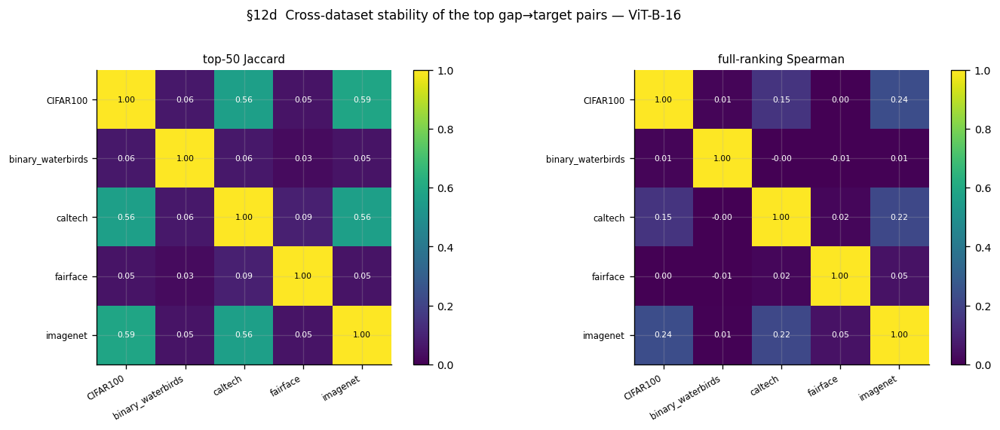

§12d  mean off-diagonal: Jaccard=0.21, Spearman=0.07


In [ ]:
# Goal:  §12d -- top-K overlap (Jaccard) and full-ranking Spearman across datasets, fixed model.
ds_have = [d for d in DATASETS if (MODEL_SEL, d, "pos") in R]
sets, ranks = {}, {}
for d in ds_have:
    ab_d, C_d, _ = top_pairs(MODEL_SEL, d, TOPK)
    sets[d] = set(ab_d); ranks[d] = C_d.ravel()
J = pd.DataFrame(index=ds_have, columns=ds_have, dtype=float)
S = pd.DataFrame(index=ds_have, columns=ds_have, dtype=float)
for d1 in ds_have:
    for d2 in ds_have:
        J.loc[d1, d2] = len(sets[d1] & sets[d2]) / len(sets[d1] | sets[d2])
        S.loc[d1, d2] = _sp(ranks[d1], ranks[d2]).statistic
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, M, t in [(axes[0], J, f"top-{TOPK} Jaccard"), (axes[1], S, "full-ranking Spearman")]:
    im = ax.imshow(M.values.astype(float), vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(ds_have))); ax.set_xticklabels(ds_have, rotation=30, ha="right", fontsize=7)
    ax.set_yticks(range(len(ds_have))); ax.set_yticklabels(ds_have, fontsize=7)
    for i in range(len(ds_have)):
        for j in range(len(ds_have)):
            ax.text(j, i, f"{M.values[i,j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if M.values[i, j] < 0.6 else "black")
    ax.set_title(t); fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"§12d  Cross-dataset stability of the top gap→target pairs — {MODEL_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"12d_cross_dataset_{MODEL_SEL}"); plt.show()
print(f"§12d  mean off-diagonal: Jaccard={J.values[~np.eye(len(ds_have),dtype=bool)].mean():.2f}, "
      f"Spearman={S.values[~np.eye(len(ds_have),dtype=bool)].mean():.2f}")

### §12e — Destruction: mean-ablate (drop) the top-K vs zero-shot accuracy

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/12e_destruction_ViT-B-16_imagenet.png


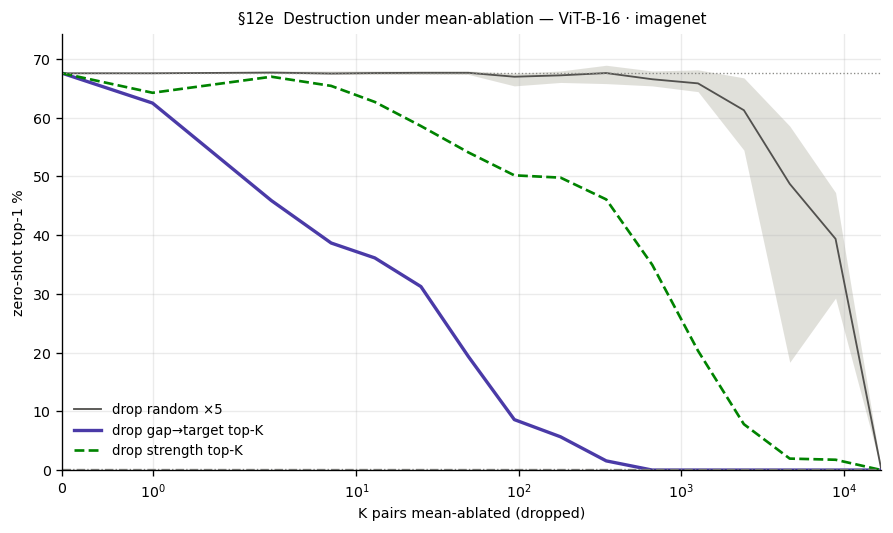

In [ ]:
# Goal:  §12e -- mean-ablate the top-K pairs (sum over the KEPT complement) and track accuracy vs K.
@torch.no_grad()
def drop_topk_curve(model, dataset, crit, ascending=True, n_img=512, n_ckpt=16):
    A, B, li, lt = _load_towers(model, dataset, n_img)
    zI, zT = A.sum(1), B.sum(1)
    A = A / zI.norm(dim=-1)[:, None, None]; B = B / zT.norm(dim=-1)[:, None, None]
    sim_full = (zI / zI.norm(dim=-1, keepdim=True)) @ (zT / zT.norm(dim=-1, keepdim=True)).T
    base = _acc(sim_full, li, lt); chance = 100.0 / len(np.unique(lt))
    Kv, Kt = crit.shape; P = Kv * Kt
    order = np.argsort(crit, axis=None)
    if not ascending: order = order[::-1]
    logK = np.unique(np.geomspace(1, P, n_ckpt).astype(int))
    xs, ys = [0], [base]
    for K in logK:
        drop = torch.zeros(P, device=device); drop[torch.as_tensor(order[:int(K)].copy(), device=device)] = 1.0
        keep = (1.0 - drop).view(Kv, Kt)
        xs.append(int(K)); ys.append(_acc(_masked_sum(A, B, keep), li, lt))
    return np.array(xs), np.array(ys), base, chance, P

_, Ctgt_sel = gap_criteria(MODEL_SEL, DATASET_SEL)
a_sel = pair_all(MODEL_SEL, DATASET_SEL); strength_sel = np.abs((a_sel["mean_pos"] + a_sel["mean_neg"]) / 2)
xt, yt, base, chance, P = drop_topk_curve(MODEL_SEL, DATASET_SEL, Ctgt_sel, ascending=True)
xs, ys, *_             = drop_topk_curve(MODEL_SEL, DATASET_SEL, strength_sel, ascending=False)
rnd = np.stack([drop_topk_curve(MODEL_SEL, DATASET_SEL,
               np.random.default_rng(200 + s).random(Ctgt_sel.shape), ascending=True)[1] for s in range(5)])
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.fill_between(xt, rnd.min(0), rnd.max(0), color="#c3c2b7", alpha=0.5, lw=0)
ax.plot(xt, rnd.mean(0), color="#52514e", lw=1.1, label="drop random ×5")
ax.plot(xt, yt, color="#4a3aa7", lw=2.0, label="drop gap→target top-K")
ax.plot(xs, ys, color="#008300", lw=1.6, ls="--", label="drop strength top-K")
ax.axhline(base, color="#8a8a86", lw=0.8, ls=":"); ax.axhline(chance, color="#8a8a86", lw=0.8, ls="-.")
ax.set_xscale("symlog"); ax.set_xlim(0, P); ax.set_ylim(0, base * 1.1)
ax.set_xlabel("K pairs mean-ablated (dropped)"); ax.set_ylabel("zero-shot top-1 %")
ax.set_title(f"§12e  Destruction under mean-ablation — {MODEL_SEL} · {DATASET_SEL}")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); save_fig(fig, f"12e_destruction_{MODEL_SEL}_{DATASET_SEL}"); plt.show()

### §12f — Project the top-10 pairs into the 3D PCA of the final embedding

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/12f_projection_ViT-B-16_imagenet.png


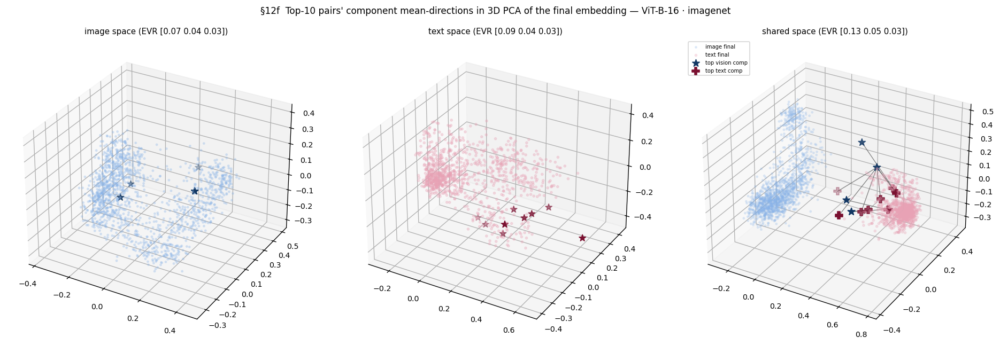

§12f  lines connect the vision & text component of each top pair in the shared space.


In [ ]:
# Goal:  §12f -- top-10 pairs' component means in the 3D PCA of the final embedding: per modality + shared.
p = _paths(MODEL_SEL, DATASET_SEL)
img_final = np.load(p["attn_v"], mmap_mode="r")  # reconstruct final = sum of atoms (normalized)
img_final = (np.load(p["attn_v"], mmap_mode="r").sum((1, 2)) + np.load(p["mlp_v"], mmap_mode="r").sum(1))
img_final = (img_final / np.linalg.norm(img_final, axis=1, keepdims=True)).astype(np.float32)
txt_atoms_a = np.load(p["attn_t"], mmap_mode="r"); txt_atoms_m = np.load(p["mlp_t"], mmap_mode="r")
txt_final = (txt_atoms_a.sum((1, 2)) + txt_atoms_m.sum(1))
txt_final = (txt_final / np.linalg.norm(txt_final, axis=1, keepdims=True)).astype(np.float32)

Vv, S2v, MUv = pc_bundles(MODEL_SEL, DATASET_SEL, "image")
Vt, S2t, MUt = pc_bundles(MODEL_SEL, DATASET_SEL, "text")
ab10, _, _ = top_pairs(MODEL_SEL, DATASET_SEL, N_PROJ)
vidx = [a for a, _ in ab10]; tidx = [b for _, b in ab10]
# component mean DIRECTIONS (unit-normed) -> comparable to the unit-norm final embeddings,
# otherwise the tiny-norm means collapse to the centroid and the pair lines are invisible.
mu_v = MUv[vidx] / (np.linalg.norm(MUv[vidx], axis=1, keepdims=True) + 1e-9)
mu_t = MUt[tidx] / (np.linalg.norm(MUt[tidx], axis=1, keepdims=True) + 1e-9)

def fit_proj(fit_X, *proj):
    pca = PCA(3).fit(fit_X)
    return [pca.transform(x) for x in proj], pca.explained_variance_ratio_

# subsample clouds for legibility
rng = np.random.default_rng(0)
ig = img_final[rng.choice(len(img_final), min(1500, len(img_final)), replace=False)]
tg = txt_final[rng.choice(len(txt_final), min(1000, len(txt_final)), replace=False)]

fig = plt.figure(figsize=(16, 5.2))
# per-modality image
(P_ig, P_mv), ev = fit_proj(img_final, ig, mu_v)
ax = fig.add_subplot(131, projection="3d")
ax.scatter(*P_ig.T, s=4, alpha=0.25, color="#8ab4e8"); ax.scatter(*P_mv.T, s=60, marker="*", color="#123763")
ax.set_title(f"image space (EVR {ev.round(2)})", fontsize=9)
# per-modality text
(P_tg, P_mt), ev = fit_proj(txt_final, tg, mu_t)
ax = fig.add_subplot(132, projection="3d")
ax.scatter(*P_tg.T, s=6, alpha=0.3, color="#e8a2b5"); ax.scatter(*P_mt.T, s=60, marker="*", color="#7a1030")
ax.set_title(f"text space (EVR {ev.round(2)})", fontsize=9)
# shared
shared_fit = np.concatenate([img_final, txt_final], 0)
(S_ig, S_tg, S_mv, S_mt), ev = fit_proj(shared_fit, ig, tg, mu_v, mu_t)
ax = fig.add_subplot(133, projection="3d")
ax.scatter(*S_ig.T, s=4, alpha=0.2, color="#8ab4e8", label="image final")
ax.scatter(*S_tg.T, s=6, alpha=0.25, color="#e8a2b5", label="text final")
ax.scatter(*S_mv.T, s=70, marker="*", color="#123763", label="top vision comp")
ax.scatter(*S_mt.T, s=70, marker="P", color="#7a1030", label="top text comp")
for i in range(len(ab10)):
    ax.plot(*np.stack([S_mv[i], S_mt[i]]).T, color="#555", lw=0.8, alpha=0.7)
ax.set_title(f"shared space (EVR {ev.round(2)})", fontsize=9); ax.legend(fontsize=6, loc="upper left")
fig.suptitle(f"§12f  Top-{N_PROJ} pairs' component mean-directions in 3D PCA of the final embedding — "
             f"{MODEL_SEL} · {DATASET_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"12f_projection_{MODEL_SEL}_{DATASET_SEL}"); plt.show()
print("§12f  lines connect the vision & text component of each top pair in the shared space.")

## §13 — Extreme-value ("spike") pairs: pairs that fire big on a few samples

A pair is a *spike* pair if its contribution `S_ab` takes **big values on a few samples**, regardless
of pos/neg. Over the pooled (pos+neg, equal size) samples we score each pair four ways:

| score | formula | reads |
|---|---|---|
| **q99.9\|S\|** | 99.9th pct of \|S_ab\| | big value on the top ~0.1% of samples (primary) |
| **m4^¼** | `E[(S−μ)⁴]^{1/4}` | magnitude-keeping, 4th-power up-weights the rare extremes |
| **kurtosis** | `E[(S−μ)⁴]/σ⁴` | scale-free tailedness (few, but ignores magnitude) |
| **crest** | `max\|S\| / RMS` | peak relative to the pair's own typical level |

These are also wired into the §6/§6b sweep (`gap→target`, `gap→output`, `spike q99.9|S|` are drawn in
§6b; all four spike scores appear in its retained-accuracy table). Here we (a) benchmark the family
with keep/drop zero-shot, (b) show what the top-spike pairs are, and (c) show **which samples spike**.

In [37]:
# Goal:  §13 -- spike-score family for (MODEL_SEL, DATASET_SEL); reuses §11 keep_topk / §12e drop / §12 helpers.
@torch.no_grad()
def spike_family(model, dataset, n_pairs=N_PAIRS):
    Sp, *_ = _pair_S(model, dataset, "pos", n_pairs)
    Sn, *_ = _pair_S(model, dataset, "neg", n_pairs)
    S = torch.cat([Sp, Sn], 0); mu = S.mean(0); c = S - mu
    m2 = (c ** 2).mean(0); m4 = (c ** 4).mean(0)
    kk = max(1, min(int(round(0.999 * S.shape[0])), S.shape[0]))
    fam = {"q99.9|S|": S.abs().kthvalue(kk, dim=0).values,
           "m4^¼":     m4.clamp_min(0) ** 0.25,
           "kurtosis": m4 / (m2 ** 2 + 1e-30),
           "crest":    S.abs().amax(0) / (m2.sqrt() + 1e-30)}
    if device.startswith("cuda"): torch.cuda.empty_cache()
    return {k: v.cpu().numpy() for k, v in fam.items()}

SPK = spike_family(MODEL_SEL, DATASET_SEL)
SPK_STYLE = {"q99.9|S|": "#d1651a", "m4^¼": "#1baf7a", "kurtosis": "#4a3aa7", "crest": "#b3202b"}
print("§13  spike scores computed for", MODEL_SEL, DATASET_SEL, "| pairs =", SPK["q99.9|S|"].size)

§13  spike scores computed for ViT-B-16 imagenet | pairs = 17113


### §13a — Do spike pairs carry classification? keep-top-K and drop-top-K zero-shot

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/13a_spike_zeroshot_ViT-B-16_imagenet.png


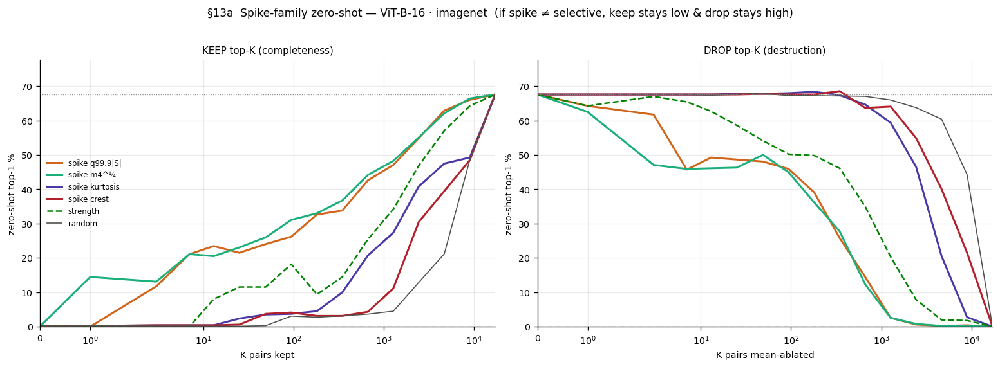

In [38]:
# Goal:  §13a -- keep & drop top-K by each spike score (+ strength, random) vs zero-shot accuracy.
a_sel = pair_all(MODEL_SEL, DATASET_SEL); strength_sel = np.abs((a_sel["mean_pos"] + a_sel["mean_neg"]) / 2)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
# KEEP (higher spike = top -> ascending=False)
for name, s in SPK.items():
    x, y, base, chance, P, _ = keep_topk_accuracy(MODEL_SEL, DATASET_SEL, s, ascending=False)
    axes[0].plot(x, y, color=SPK_STYLE[name], lw=1.8, label=f"spike {name}")
xk, yk, base, chance, P, _ = keep_topk_accuracy(MODEL_SEL, DATASET_SEL, strength_sel, ascending=False)
axes[0].plot(xk, yk, color="#008300", lw=1.5, ls="--", label="strength")
rndk = np.stack([keep_topk_accuracy(MODEL_SEL, DATASET_SEL, np.random.default_rng(300+s).random(SPK['q99.9|S|'].shape),
                                    ascending=True)[1] for s in range(5)])
axes[0].plot(xk, rndk.mean(0), color="#52514e", lw=1.0, label="random")
axes[0].set_title("KEEP top-K (completeness)"); axes[0].set_xlabel("K pairs kept")
# DROP (destruction)
for name, s in SPK.items():
    x, y, base, chance, P = drop_topk_curve(MODEL_SEL, DATASET_SEL, s, ascending=False)
    axes[1].plot(x, y, color=SPK_STYLE[name], lw=1.8, label=f"spike {name}")
xd, yd, base, chance, P = drop_topk_curve(MODEL_SEL, DATASET_SEL, strength_sel, ascending=False)
axes[1].plot(xd, yd, color="#008300", lw=1.5, ls="--", label="strength")
rndd = np.stack([drop_topk_curve(MODEL_SEL, DATASET_SEL, np.random.default_rng(400+s).random(SPK['q99.9|S|'].shape),
                                 ascending=True)[1] for s in range(5)])
axes[1].plot(xd, rndd.mean(0), color="#52514e", lw=1.0, label="random")
axes[1].set_title("DROP top-K (destruction)"); axes[1].set_xlabel("K pairs mean-ablated")
for ax in axes:
    ax.axhline(base, color="#8a8a86", lw=0.8, ls=":"); ax.axhline(chance, color="#8a8a86", lw=0.8, ls="-.")
    ax.set_xscale("symlog"); ax.set_xlim(0, P); ax.set_ylim(0, base * 1.15); ax.set_ylabel("zero-shot top-1 %")
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle(f"§13a  Spike-family zero-shot — {MODEL_SEL} · {DATASET_SEL}  "
             f"(if spike ≠ selective, keep stays low & drop stays high)", y=1.02)
plt.tight_layout(); save_fig(fig, f"13a_spike_zeroshot_{MODEL_SEL}_{DATASET_SEL}"); plt.show()

### §13b — What are the top spike pairs? composition, score_b, overlap with gap→target

§13b  top-50 spike (q99.9|S|) pairs — ViT-B-16 · imagenet
  family: {'mlp×mlp': 21, 'attn×attn': 17, 'mlp×attn': 8, 'attn×mlp': 4}
  vision layer median=11, text layer median=11
  median score_b=1.42e-05  (all-pairs median=5.14e-09)
  Jaccard(top spike, top gap→target) = 0.18   (low ⇒ spike is a DIFFERENT axis)
saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/13b_spike_composition_ViT-B-16_imagenet.png


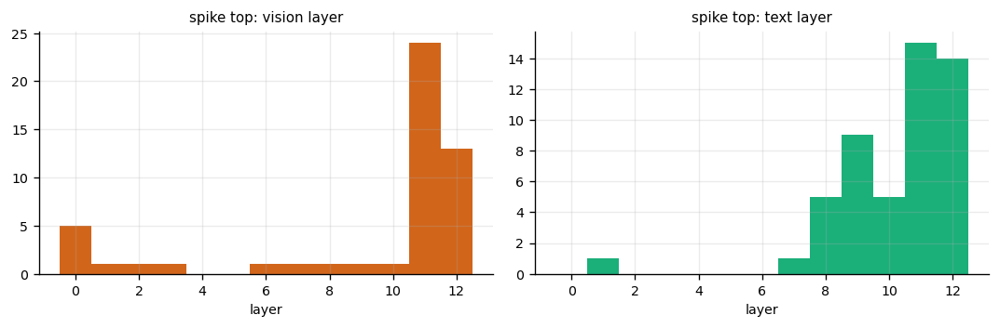

In [39]:
# Goal:  §13b -- top-K by primary spike score: family/layers, score_b, and overlap with the gap→target top.
PRIMARY = "q99.9|S|"
sp = SPK[PRIMARY]; Kv, Kt = sp.shape
order = np.argsort(sp, axis=None)[::-1]                       # highest spike first
ab_sp = [(int(o // Kt), int(o % Kt)) for o in order[:TOPK]]
(kv, lv, hv), (kt, lt, ht) = comp_meta(MODEL_SEL, DATASET_SEL)
famct = pd.Series([f"{'attn' if kv[a]=='attn' else 'mlp'}×{'attn' if kt[b]=='attn' else 'mlp'}"
                   for a, b in ab_sp]).value_counts()
scoreb = pc_criterion(MODEL_SEL, DATASET_SEL)["shared_var2"]
ab_tgt = set(top_pairs(MODEL_SEL, DATASET_SEL, TOPK)[0])
overlap = len(set(ab_sp) & ab_tgt) / len(set(ab_sp) | ab_tgt)
print(f"§13b  top-{TOPK} spike ({PRIMARY}) pairs — {MODEL_SEL} · {DATASET_SEL}")
print("  family:", famct.to_dict())
print(f"  vision layer median={int(np.median([lv[a] for a,_ in ab_sp]))}, "
      f"text layer median={int(np.median([lt[b] for _,b in ab_sp]))}")
print(f"  median score_b={np.median([scoreb[a,b] for a,b in ab_sp]):.2e}  (all-pairs median={np.median(scoreb):.2e})")
print(f"  Jaccard(top spike, top gap→target) = {overlap:.2f}   (low ⇒ spike is a DIFFERENT axis)")
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist([lv[a] for a, _ in ab_sp], bins=np.arange(int(lv.max())+2)-0.5, color="#d1651a")
axes[0].set_title("spike top: vision layer"); axes[0].set_xlabel("layer")
axes[1].hist([lt[b] for _, b in ab_sp], bins=np.arange(int(lt.max())+2)-0.5, color="#1baf7a")
axes[1].set_title("spike top: text layer"); axes[1].set_xlabel("layer")
plt.tight_layout(); save_fig(fig, f"13b_spike_composition_{MODEL_SEL}_{DATASET_SEL}"); plt.show()

### §13c — Which samples spike? the extreme images per top spike pair

In [ ]:
# Goal:  §13c -- for each top spike pair, the few images with the most extreme |S_ab| (own true class).
@torch.no_grad()
def extreme_samples(model, dataset, a, b, n_img=3000, topn=6):
    p = _paths(model, dataset)
    lbl_v = np.load(p["lbl_v"]); lbl_t = np.load(p["lbl_t"])
    ok = np.flatnonzero(np.isin(lbl_v, np.unique(lbl_t)))
    ii = np.random.default_rng(0).permutation(ok)[:n_img]
    jj = np.array([np.flatnonzero(lbl_t == lbl_v[i])[0] for i in ii])   # each image × its true class
    A = _stack(torch.from_numpy(np.asarray(np.load(p["attn_v"], mmap_mode="r")[ii], dtype=np.float32)).to(device),
               torch.from_numpy(np.asarray(np.load(p["mlp_v"],  mmap_mode="r")[ii], dtype=np.float32)).to(device))
    B = _stack(torch.from_numpy(np.asarray(np.load(p["attn_t"], mmap_mode="r")[jj], dtype=np.float32)).to(device),
               torch.from_numpy(np.asarray(np.load(p["mlp_t"],  mmap_mode="r")[jj], dtype=np.float32)).to(device))
    ah = A[:, a] / A.sum(1).norm(dim=-1, keepdim=True)
    bh = B[:, b] / B.sum(1).norm(dim=-1, keepdim=True)
    s = (ah * bh).sum(-1).cpu().numpy()                                  # S_ab per image
    top = np.argsort(np.abs(s))[::-1][:topn]
    return ii[top], lbl_v[ii][top], s[top]

# class names (best effort)
cnf = f"{OUT_DIR}/{DATASET_SEL}_classnames.txt"
CN = [l.strip() for l in open(cnf)] if os.path.exists(cnf) else None
def cname(c): return CN[int(c)] if CN and int(c) < len(CN) else f"class{int(c)}"

rows = []
for rank, (a, b) in enumerate(ab_sp[:6], 1):
    idx, lbl, sval = extreme_samples(MODEL_SEL, DATASET_SEL, a, b)
    rows.append(dict(rank=rank,
                     pair=f"{comp_label(kv[a],lv[a],hv[a])} × {comp_label(kt[b],lt[b],ht[b])}",
                     spike=f"{SPK[PRIMARY][a,b]:.3e}",
                     extreme_imgs=", ".join(str(int(i)) for i in idx[:4]),
                     extreme_classes=", ".join(cname(c) for c in lbl[:4]),
                     S_vals=", ".join(f"{v:.2e}" for v in sval[:4])))
print(f"§13c  Extreme (spiking) samples for the top spike pairs — {MODEL_SEL} · {DATASET_SEL}")
pd.set_option("display.max_colwidth", 55)
display(pd.DataFrame(rows))

§13c  Extreme (spiking) samples for the top spike pairs — ViT-B-16 · imagenet


,rank,pair,spike,extreme_imgs,extreme_classes,S_vals
0,1,L12·MLP × L12·MLP,1.646e-01,"4609, 4580, 4606, 4584","dust jacket, website, dust jacket, website","-1.92e-01, -1.90e-01, -1.80e-01, -1.78e-01"
1,2,L11·H5 × L9·H6,9.438e-02,"1791, 1790, 1573, 153","European polecat, European polecat, cockroach, Amer...","1.25e-01, 1.20e-01, 1.12e-01, 1.12e-01"
2,3,L0·MLP × L12·MLP,8.839e-02,"4584, 4580, 4609, 4581","website, website, dust jacket, website","1.12e-01, 1.07e-01, 1.02e-01, 9.64e-02"
3,4,L11·MLP × L12·MLP,7.853e-02,"4584, 4609, 4580, 4040","website, dust jacket, website, sombrero","9.43e-02, 9.10e-02, 8.97e-02, 8.56e-02"
4,5,L11·H5 × L11·H7,7.254e-02,"1516, 188, 1517, 186","longhorn beetle, box turtle, longhorn beetle, box t...","9.26e-02, 8.79e-02, 8.43e-02, 8.19e-02"
5,6,L11·H10 × L11·H2,6.412e-02,"74, 70, 72, 4753","indigo bunting, indigo bunting, indigo bunting, orange","1.17e-01, 1.16e-01, 1.04e-01, 1.01e-01"


## §14 — Signed 2-Gaussian separability score (d′) — zero-shot & reconstruction

Per pair, fit class-conditional Gaussians to `S_ab`: `N(μ₊,σ₊²)` on positives, `N(μ₋,σ₋²)` on
negatives. The ranking score is the **signed d′**

$$G_{ab}=\frac{\mu_+-\mu_-}{\sqrt{\sigma_+^2+\sigma_-^2}}$$

which satisfies the three asks: (1) large `G` ⇒ the two Gaussians barely overlap (one is "the positive
one"), `Φ(G)=P(\text{pos}>\text{neg})`; (2) dividing by `√(σ₊²+σ₋²)` maximizes the *distributional*
distance (means far **and** tight); (3) it is **signed**, so a positive Gaussian sitting to the right
of the negative one scores high and a reversed pair scores negative. The full "distance between two
Gaussians" (adds the variance-shape term) is the **signed Bhattacharyya** `D_B`. Both come straight
from the cached moments. This is the signed cousin of §6b's `|PoS−0.5|` and the variance-normalized
cousin of `|Δμ|` (the previous best). We test it on **zero-shot** (keep/drop) and **reconstruction**
(fraction of the positive image–text cosine recovered vs K).

In [ ]:
# Goal:  §14 -- define G (signed d′) & D_B from cache; illustrate the fitted 2 Gaussians for top/low pairs.
a = pair_all(MODEL_SEL, DATASET_SEL)
mp, mn = a["mean_pos"].astype(np.float64), a["mean_neg"].astype(np.float64)
vp, vn = a["var_pos"].astype(np.float64), a["var_neg"].astype(np.float64)
G  = (mp - mn) / np.sqrt(vp + vn + 1e-300)
DB = np.sign(mp - mn) * (0.25 * (mp - mn) ** 2 / (vp + vn + 1e-300)
                         + 0.5 * np.log((vp + vn) / (2 * np.sqrt(vp * vn) + 1e-300) + 1e-300))
Kv, Kt = G.shape
order_G = np.argsort(G, axis=None)[::-1]
topG = [(int(o // Kt), int(o % Kt)) for o in order_G[:TOPK]]
(kv, lv, hv), (kt, lt, ht) = comp_meta(MODEL_SEL, DATASET_SEL)
print(f"§14  top signed-d′ pairs — {MODEL_SEL} · {DATASET_SEL}")
from math import erf as _erf
for r, (a_, b_) in enumerate(topG[:6], 1):
    phi = 0.5 * (1 + _erf(G[a_, b_] / 2 ** 0.5))
    print(f"  {r}. {comp_label(kv[a_],lv[a_],hv[a_])} x {comp_label(kt[b_],lt[b_],ht[b_])}  "
          f"G={G[a_,b_]:.2f}  P(pos>neg)={phi:.3f}  mu+={mp[a_,b_]:.2e} mu-={mn[a_,b_]:.2e}")

from scipy.stats import norm as _n
xs_pair = topG[:3] + [(int(o // Kt), int(o % Kt)) for o in np.argsort(np.abs(G), axis=None)[:3]]
Sp, *_ = _pair_S(MODEL_SEL, DATASET_SEL, "pos", N_PAIRS)
Sn, *_ = _pair_S(MODEL_SEL, DATASET_SEL, "neg", N_PAIRS)
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (a_, b_) in zip(axes.ravel(), xs_pair):
    sp = Sp[:, a_, b_].cpu().numpy(); sn = Sn[:, a_, b_].cpu().numpy()
    lo, hi = min(sp.min(), sn.min()), max(sp.max(), sn.max())
    xx = np.linspace(lo, hi, 200)
    ax.hist(sp, bins=25, density=True, color="#2a78d6", alpha=0.35)
    ax.hist(sn, bins=25, density=True, color="#b3202b", alpha=0.35)
    ax.plot(xx, _n.pdf(xx, mp[a_, b_], np.sqrt(vp[a_, b_])), color="#123763", lw=2, label="pos N")
    ax.plot(xx, _n.pdf(xx, mn[a_, b_], np.sqrt(vn[a_, b_])), color="#7a1030", lw=2, label="neg N")
    ax.set_title(f"{comp_label(kv[a_],lv[a_],hv[a_])}×{comp_label(kt[b_],lt[b_],ht[b_])}  G={G[a_,b_]:.2f}",
                 fontsize=8)
axes[0, 0].legend(fontsize=7)
fig.suptitle(f"§14  Fitted 2 Gaussians — top row = high d′ (separated), bottom = low d′ (overlapping) — "
             f"{MODEL_SEL} · {DATASET_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"14_gauss_illustration_{MODEL_SEL}_{DATASET_SEL}"); plt.show()

NameError: name 'MODEL_SEL' is not defined

In [ ]:
# Goal:  §14 -- zero-shot: keep-top-K and drop-top-K by d′ / Bhattacharyya vs |Δμ| (best prev), gap→target, strength.
strength = np.abs((mp + mn) / 2)
CRITS14 = {"d′ (Gauss sep)": (G, False), "Bhattacharyya": (DB, False),
           "|Δμ| (best prev)": (np.abs(mp - mn), False), "gap→target = signed Δμ": (mp - mn, False),
           "strength |E[S]|": (strength, False)}
COL14 = {"d′ (Gauss sep)": "#e8118b", "Bhattacharyya": "#8b2fb3", "|Δμ| (best prev)": "#008300",
         "gap→target = signed Δμ": "#4a3aa7", "strength |E[S]|": "#eb6834"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
tbl = {}
for name, (crit, asc) in CRITS14.items():
    xk, yk, base, chance, P, tw = keep_topk_accuracy(MODEL_SEL, DATASET_SEL, crit, ascending=asc)
    xd, yd, *_ = drop_topk_curve(MODEL_SEL, DATASET_SEL, crit, ascending=asc)
    axes[0].plot(xk, yk, color=COL14[name], lw=1.8, label=name)
    axes[1].plot(xd, yd, color=COL14[name], lw=1.8, label=name)
    def _at(x, y, K): return y[min(int(np.searchsorted(x, K)), len(y) - 1)]
    tbl[name] = {"keep@100": _at(xk, yk, 100), "keep@1000": _at(xk, yk, 1000),
                 "drop@100": _at(xd, yd, 100), "drop@1000": _at(xd, yd, 1000)}
rk = np.stack([keep_topk_accuracy(MODEL_SEL, DATASET_SEL, np.random.default_rng(500+s).random(G.shape),
                                  ascending=True)[1] for s in range(5)])
axes[0].plot(xk, rk.mean(0), color="#52514e", lw=1.0, label="random")
for ax, t in zip(axes, ["KEEP top-K", "DROP top-K (destruction)"]):
    ax.axhline(base, color="#8a8a86", lw=0.8, ls=":"); ax.axhline(chance, color="#8a8a86", lw=0.8, ls="-.")
    ax.set_xscale("symlog"); ax.set_xlim(0, P); ax.set_ylim(0, base * 1.15)
    ax.set_xlabel("K pairs"); ax.set_ylabel("zero-shot top-1 %"); ax.set_title(t)
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle(f"§14  Zero-shot of signed-d′ vs the best previous criteria — {MODEL_SEL} · {DATASET_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"14_gauss_zeroshot_{MODEL_SEL}_{DATASET_SEL}"); plt.show()
print("§14  zero-shot (% baseline retained):")
display((pd.DataFrame(tbl).T / base * 100).round(1))

NameError: name 'mp' is not defined

In [28]:
# Goal:  §14 -- reconstruction: cumulative fraction of the positive image–text cosine recovered vs K.
# Σ_ab mean_pos = E_pos[cos]; walk pairs in each criterion's order and accumulate mean_pos.
total = mp.sum()
fig, ax = plt.subplots(figsize=(8, 4.6))
recon_tbl = {}
orders14 = dict(CRITS14)
orders14["oracle (mean_pos)"] = (mp, False)      # greedy value-optimal
COL14b = dict(COL14); COL14b["oracle (mean_pos)"] = "#111111"
for name, (crit, asc) in orders14.items():
    o = np.argsort(crit, axis=None)
    if not asc: o = o[::-1]
    cum = np.cumsum(mp.ravel()[o]) / total
    xx = np.arange(1, cum.size + 1)
    ax.plot(xx, cum, color=COL14b[name], lw=1.7, ls="--" if name == "oracle (mean_pos)" else "-", label=name)
    k80 = int(np.searchsorted(cum, 0.8)) + 1
    recon_tbl[name] = {"K→50%": int(np.searchsorted(cum, 0.5)) + 1, "K→80%": k80,
                       "frac@100": round(float(cum[min(99, cum.size-1)]), 2)}
ax.axhline(1.0, color="#8a8a86", lw=0.8, ls=":"); ax.set_xscale("symlog")
ax.set_xlabel("K pairs kept (in criterion order)"); ax.set_ylabel("fraction of E_pos[cos] reconstructed")
ax.set_title(f"§14  Reconstruction of the positive cosine value vs K — {MODEL_SEL} · {DATASET_SEL}")
ax.legend(fontsize=7, frameon=False)
plt.tight_layout(); save_fig(fig, f"14_gauss_reconstruction_{MODEL_SEL}_{DATASET_SEL}"); plt.show()
print("§14  reconstruction of E_pos[cos] (K to reach 50%/80%; fraction after 100 pairs):")
display(pd.DataFrame(recon_tbl).T)

NameError: name 'mp' is not defined

### §14b — Every pair on one line: are pos/neg two Gaussians between ±1?

One horizontal line per pair, the per-sample `S_ab` drawn as **blue (positive)** and **red (negative)**
dots, `μ₊`/`μ₋` marked with ticks. **Left**: the literal `−1…+1` target axis (dashed at −1, 0, +1) —
it shows how far even the best pairs sit from the ±1 ideal. **Right**: the same rows zoomed to the data
range, where the two-Gaussian split is visible. Rows = the most-separated pairs (high signed d′) on top,
the least/reversed ones at the bottom.

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/14b_pair_line_ViT-B-16_imagenet.png




In [29]:
# Goal:  §14b -- per-pair 1D strip of S_ab samples (blue=pos, red=neg) on the [-1,1] target line + zoom.
a = pair_all(MODEL_SEL, DATASET_SEL)
mp, mn = a["mean_pos"].astype(float), a["mean_neg"].astype(float)
vp, vn = a["var_pos"].astype(float), a["var_neg"].astype(float)
Gm = (mp - mn) * (vp + vn + 1e-300); Kv, Kt = Gm.shape
oG = np.argsort(Gm, axis=None)[::-1]
sel = list(oG[:100]) + list(oG[-100:])                      # 10 most-separated + 4 least/reversed
Sp, *_ = _pair_S(MODEL_SEL, DATASET_SEL, "pos", N_PAIRS)
Sn, *_ = _pair_S(MODEL_SEL, DATASET_SEL, "neg", N_PAIRS)
(kv, lv, hv), (kt, lt, ht) = comp_meta(MODEL_SEL, DATASET_SEL)
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(14, 0.5 * len(sel) + 1.5), sharey=True,
                         gridspec_kw={"width_ratios": [1, 1.15]})
labels = []
for row, flat in enumerate(sel):
    aa, bb = divmod(int(flat), Kt)
    sp = Sp[:, aa, bb].cpu().numpy(); sn = Sn[:, aa, bb].cpu().numpy()
    for ax in axes:
        ax.scatter(sn, row + rng.uniform(-0.16, 0.16, sn.size), s=6, c="#b3202b", alpha=0.45, linewidths=0)
        ax.scatter(sp, row + rng.uniform(-0.16, 0.16, sp.size), s=6, c="#2a78d6", alpha=0.45, linewidths=0)
        ax.plot(mn[aa, bb], row, marker="|", ms=15, c="#7a1030", mew=2.2)
        ax.plot(mp[aa, bb], row, marker="|", ms=15, c="#123763", mew=2.2)
    labels.append(f"{comp_label(kv[aa],lv[aa],hv[aa])}×{comp_label(kt[bb],lt[bb],ht[bb])}  G={Gm[aa,bb]:+.2f}")
axes[0].set_xlim(-1.05, 1.05)
for x in (-1, 0, 1): axes[0].axvline(x, ls="--", lw=0.9, c="#888")
axes[0].set_title("literal −1…+1 target line  (S_ab sits near 0)"); axes[0].set_xlabel("S_ab   (target +1 pos / −1 neg)")
axes[1].axvline(0, ls="--", lw=0.9, c="#888"); axes[1].set_title("zoom to data range (separation visible)")
axes[1].set_xlabel("S_ab")
axes[0].set_yticks(range(len(sel))); axes[0].set_yticklabels(labels, fontsize=6.5)
axes[0].invert_yaxis()
from matplotlib.lines import Line2D
axes[1].legend([Line2D([], [], marker="o", ls="", color="#2a78d6"),
                Line2D([], [], marker="o", ls="", color="#b3202b")],
               ["positive samples", "negative samples"], fontsize=7, loc="lower right")
fig.suptitle(f"§14b  pos/neg S_ab per pair on one line — {MODEL_SEL} · {DATASET_SEL}", y=1.0)
plt.tight_layout(); save_fig(fig, f"14b_pair_line_{MODEL_SEL}_{DATASET_SEL}"); plt.show()


§14c  ViT-B-16 · CIFAR100   base=67.58%  chance=1.00%  (P=17113 pairs)
   KEEP top-K  (↑ better)              K=      1       5      10      50     100     all
     S = E_pos−E_neg (signed)     23.83   35.35   44.53   60.16   57.03   67.58
     |Δμ| = |E_pos−E_neg|         23.83   30.66   31.05   40.62   43.75   67.58
     strength |(μ⁺+μ⁻)/2|          1.17    1.76    0.20   21.48   18.16   67.58
     random                        0.98    0.59    0.78    0.59    1.37   67.58
   DROP top-K  (↓ = more important)    K=      1       5      10      50     100     all
     S = E_pos−E_neg (signed)     57.81   29.88   23.63    6.45    2.73    0.98
     |Δμ| = |E_pos−E_neg|         57.81   44.53   33.98   28.71   16.41    0.98
     strength |(μ⁺+μ⁻)/2|         58.98   68.55   63.09   39.26   44.53    0.98
     random                       67.58   67.58   67.58   67.19   67.58    0.98

§14c  ViT-B-16 · binary_waterbirds   base=70.51%  chance=50.00%  (P=17113 pairs)
   KEEP top-K  (↑ better)   

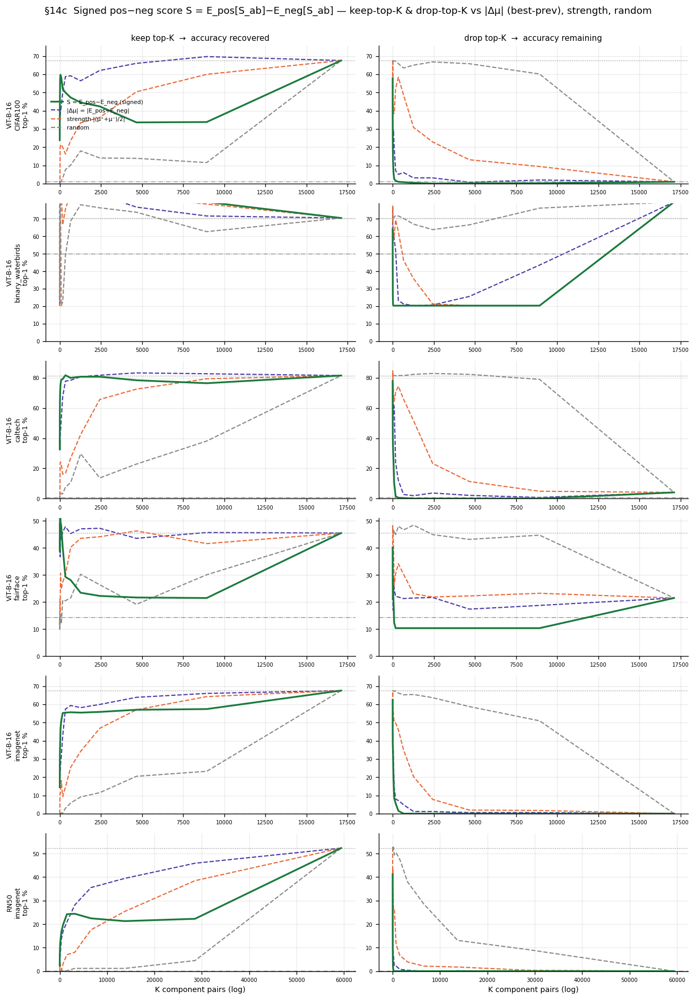

In [ ]:
# Goal:  §14c -- keep-top-K & drop-top-K zero-shot for the SIGNED score S = E_pos[S_ab]-E_neg[S_ab]
#         vs |Δμ| (best-prev), strength, random. Exact-K table + log-K curves. Reuses §6/§11/§12e.
SIGNED_GRID = [("ViT-B-16", d) for d in DATASETS] + [("RN50", "imagenet")]  # editable; must be in R
K_TABLE      = [1, 5, 10, 50, 100, None]      # None = all pairs
N_CKPT_14c   = 16

@torch.no_grad()
def keep_drop_signed(model, dataset, n_img=512, n_ckpt=N_CKPT_14c):
    A, B, li, lt = _load_towers(model, dataset, n_img)
    zI, zT = A.sum(1), B.sum(1)
    A = A / zI.norm(dim=-1)[:, None, None]; B = B / zT.norm(dim=-1)[:, None, None]
    base = _acc((zI / zI.norm(dim=-1, keepdim=True)) @ (zT / zT.norm(dim=-1, keepdim=True)).T, li, lt)
    chance = 100.0 / len(np.unique(lt)); Kv, Kt = A.shape[1], B.shape[1]; P = Kv * Kt
    a = pair_all(model, dataset)
    mp, mn = a["mean_pos"].astype(np.float64), a["mean_neg"].astype(np.float64)
    CRIT = {"S = E_pos−E_neg (signed)": mp - mn,
            "|Δμ| = |E_pos−E_neg|":     np.abs(mp - mn),
            "strength |(μ⁺+μ⁻)/2|":     np.abs((mp + mn) / 2),
            "random":                    np.random.default_rng(7).random((Kv, Kt))}
    def keep(order, K):
        m = torch.zeros(P, device=device); m[torch.as_tensor(order[:K].copy(), device=device)] = 1.0
        return _acc(_masked_sum(A, B, m.view(Kv, Kt)), li, lt)
    def drop(order, K):
        m = torch.ones(P, device=device);  m[torch.as_tensor(order[:K].copy(), device=device)] = 0.0
        return _acc(_masked_sum(A, B, m.view(Kv, Kt)), li, lt)
    Ktab = [K if K is not None else P for K in K_TABLE]
    logK = np.unique(np.geomspace(1, P, n_ckpt).astype(int))
    out = dict(base=base, chance=chance, P=P, Ktab=Ktab, logK=logK,
               keep_t={}, drop_t={}, keep_c={}, drop_c={})
    for name, c in CRIT.items():
        order = np.argsort(c, axis=None)[::-1]                 # descending = most important first
        out["keep_t"][name] = [keep(order, K) for K in Ktab]
        out["drop_t"][name] = [drop(order, K) for K in Ktab]
        out["keep_c"][name] = np.array([keep(order, int(K)) for K in logK])
        out["drop_c"][name] = np.array([drop(order, int(K)) for K in logK])
    if device.startswith("cuda"): torch.cuda.empty_cache()
    return out

SIGNED = {}
for m, d in SIGNED_GRID:
    if (m, d, "pos") not in R: continue
    SIGNED[(m, d)] = keep_drop_signed(m, d); r = SIGNED[(m, d)]
    hdr = "  ".join(f"{('all' if K == r['P'] else K):>6}" for K in r["Ktab"])
    print(f"\n§14c  {m} · {d}   base={r['base']:.2f}%  chance={r['chance']:.2f}%  (P={r['P']} pairs)")
    print(f"   KEEP top-K  (↑ better)              K= {hdr}")
    for name in r["keep_t"]:
        print(f"     {name:<28}" + "  ".join(f"{v:6.2f}" for v in r["keep_t"][name]))
    print(f"   DROP top-K  (↓ = more important)    K= {hdr}")
    for name in r["drop_t"]:
        print(f"     {name:<28}" + "  ".join(f"{v:6.2f}" for v in r["drop_t"][name]))

CR_COL = {"S = E_pos−E_neg (signed)": "#1b7a3d", "|Δμ| = |E_pos−E_neg|": "#4a3aa7",
          "strength |(μ⁺+μ⁻)/2|": "#eb6834", "random": "#8a8a86"}
gm = list(SIGNED)
fig, axes = plt.subplots(len(gm), 2, figsize=(11, 2.6 * len(gm)), squeeze=False)
for ri, (m, d) in enumerate(gm):
    r = SIGNED[(m, d)]; x = r["logK"]
    for col, key, ttl in [(0, "keep_c", "keep top-K  →  accuracy recovered"),
                          (1, "drop_c", "drop top-K  →  accuracy remaining")]:
        ax = axes[ri][col]
        for name in r[key]:
            sig = "signed" in name
            ax.plot(x, r[key][name], lw=2.0 if sig else 1.3, ls="-" if sig else "--",
                    color=CR_COL[name], label=name, zorder=3 if sig else 2)
        ax.axhline(r["base"], color="#8a8a86", lw=0.8, ls=":")
        ax.axhline(r["chance"], color="#8a8a86", lw=0.8, ls="-.")
         ax.set_ylim(0, r["base"] * 1.12)
        if ri == 0: ax.set_title(ttl, fontsize=9)
        if ri == len(gm) - 1: ax.set_xlabel("K component pairs (log)")
        if col == 0: ax.set_ylabel(f"{m}\n{d}\ntop-1 %", fontsize=7.5)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=6.5, frameon=False, loc="center left")
fig.suptitle("§14c  Signed pos−neg score S = E_pos[S_ab]−E_neg[S_ab] — keep-top-K & drop-top-K "
             "vs |Δμ| (best-prev), strength, random", fontsize=11, y=1.002)
plt.tight_layout(); save_fig(fig, "14c_signed_keep_drop"); plt.show()

## §15 — Mean-ablation: drop the most-aligned vs most-misaligned pairs (signed d′)

Using the signed 2-Gaussian score `G` (§14), we mean-ablate pairs **most-aligned first** (highest `+G`
— well-separated, positives→positive) versus **most-misaligned first** (lowest/negative `G` — the
*reversed* pairs whose negatives run more positive than their positives), and track zero-shot vs K
against the unablated baseline, for **all 4 models × all datasets**.

If `G` is meaningful, dropping the **aligned** pairs should **collapse accuracy fast**, while dropping
the **misaligned** ones should stay near baseline (or even rise — they were fighting the decision).

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/15_align_vs_misalign_ablation.png


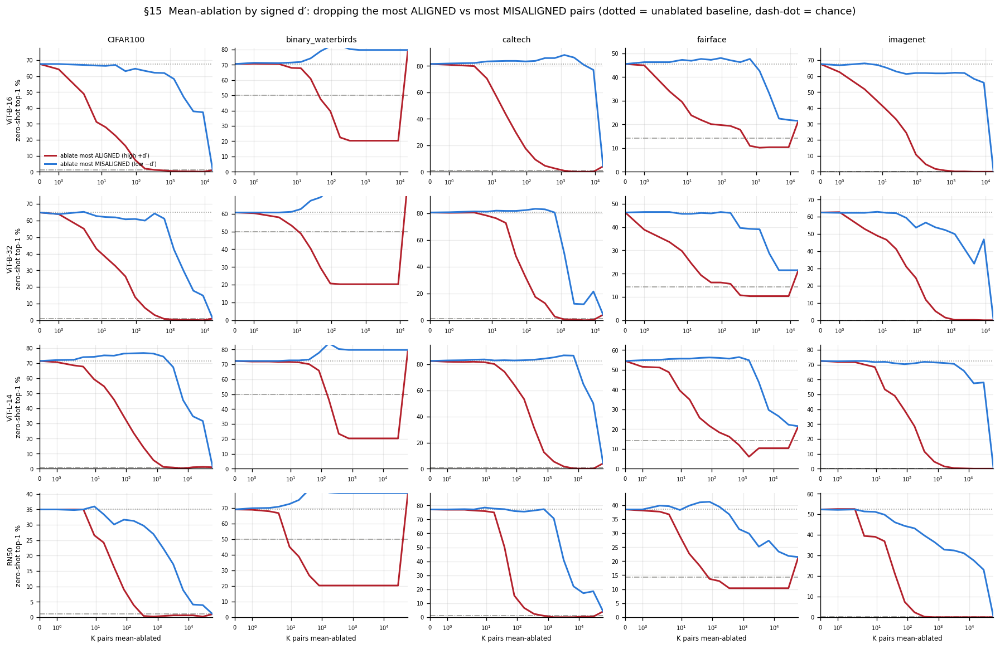

In [52]:
# Goal:  §15 -- ablate most-aligned (high d′) vs most-misaligned (low d′) first, vs baseline, whole grid.
MODELS4 = ["ViT-B-16", "ViT-B-32", "ViT-L-14", "RN50"]   # the 4 models; swap to `have` for all 6

def gauss_d(model, dataset):
    a = pair_all(model, dataset)
    mp, mn = a["mean_pos"].astype(float), a["mean_neg"].astype(float)
    vp, vn = a["var_pos"].astype(float), a["var_neg"].astype(float)
    return (mp - mn) / np.sqrt(vp + vn + 1e-300)

titled = set()
fig, axes = plt.subplots(len(MODELS4), len(DATASETS), figsize=(15, 2.4 * len(MODELS4)), squeeze=False)
for ri, m in enumerate(MODELS4):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if (m, d, "pos") not in R:
            ax.set_visible(False); continue
        G = gauss_d(m, d)
        xa, ya, base, chance, P = drop_topk_curve(m, d, G, ascending=False)   # most ALIGNED first
        xm, ym, *_             = drop_topk_curve(m, d, G, ascending=True)      # most MISALIGNED first
        ax.plot(xa, ya, color="#b3202b", lw=1.8, label="ablate most ALIGNED (high +d′)")
        ax.plot(xm, ym, color="#2a78d6", lw=1.8, label="ablate most MISALIGNED (low −d′)")
        ax.axhline(base, color="#8a8a86", lw=0.9, ls=":", zorder=0)
        ax.axhline(chance, color="#8a8a86", lw=0.9, ls="-.", zorder=0)
        ax.set_xscale("symlog"); ax.set_xlim(0, P); ax.set_ylim(0, max(base * 1.15, 5))
        if d not in titled: ax.set_title(d, fontsize=8.5); titled.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nzero-shot top-1 %", fontsize=7.5)
        if ri == len(MODELS4) - 1: ax.set_xlabel("K pairs mean-ablated", fontsize=7)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=6, loc="lower left", frameon=False)
fig.suptitle("§15  Mean-ablation by signed d′: dropping the most ALIGNED vs most MISALIGNED pairs "
             "(dotted = unablated baseline, dash-dot = chance)", fontsize=11, y=1.004)
plt.tight_layout(); save_fig(fig, "15_align_vs_misalign_ablation"); plt.show()

### §15b — Waterbirds & FairFace: worst-class accuracy under the same ablation

The bias-sensitive datasets get the robustness metric too: **worst-class accuracy** (min over classes
of the per-class recall), alongside overall. If dropping the **misaligned** pairs is genuine bias
removal, the **worst-class** curve (dashed) should rise, not just the overall one. Solid = overall,
dashed = worst-class; red = ablate most-aligned first, blue = ablate most-misaligned first; grey
dotted/dashed = unablated overall/worst baselines.

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/15b_worst_class_ablation.png


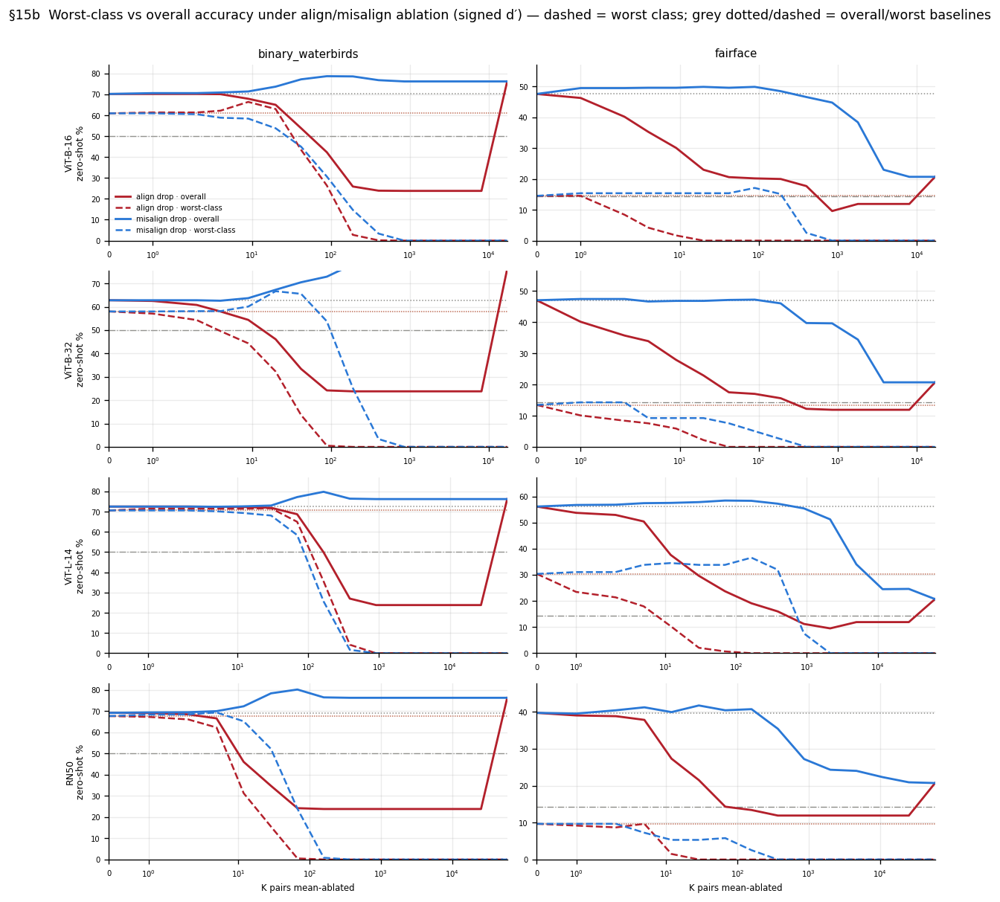

In [53]:
# Goal:  §15b -- overall AND worst-class accuracy vs K, align vs misalign drop, for waterbirds & fairface.
BIAS_DS = ["binary_waterbirds", "fairface"]

@torch.no_grad()
def _acc_worst(sim, lbl_img, lbl_txt):
    pred = lbl_txt[sim.argmax(1).cpu().numpy()]
    overall = 100.0 * (pred == lbl_img).mean()
    accs = [(pred[lbl_img == c] == c).mean() for c in np.unique(lbl_img) if (lbl_img == c).any()]
    return overall, 100.0 * float(np.min(accs))

@torch.no_grad()
def drop_curve_worst(model, dataset, crit, ascending, n_img=1000, n_ckpt=14):
    A, B, li, lt = _load_towers(model, dataset, n_img)
    zI, zT = A.sum(1), B.sum(1)
    A = A / zI.norm(dim=-1)[:, None, None]; B = B / zT.norm(dim=-1)[:, None, None]
    sf = (zI / zI.norm(dim=-1, keepdim=True)) @ (zT / zT.norm(dim=-1, keepdim=True)).T
    bo, bw = _acc_worst(sf, li, lt); chance = 100.0 / len(np.unique(lt))
    Kv, Kt = crit.shape; P = Kv * Kt
    order = np.argsort(crit, axis=None); order = order if ascending else order[::-1]
    logK = np.unique(np.geomspace(1, P, n_ckpt).astype(int))
    xs, yo, yw = [0], [bo], [bw]
    for K in logK:
        drop = torch.zeros(P, device=device); drop[torch.as_tensor(order[:int(K)].copy(), device=device)] = 1.0
        o, w = _acc_worst(_masked_sum(A, B, (1.0 - drop).view(Kv, Kt)), li, lt)
        xs.append(int(K)); yo.append(o); yw.append(w)
    return np.array(xs), np.array(yo), np.array(yw), bo, bw, chance, P

titled = set()
fig, axes = plt.subplots(len(MODELS4), len(BIAS_DS), figsize=(10, 2.5 * len(MODELS4)), squeeze=False)
for ri, m in enumerate(MODELS4):
    for ci, d in enumerate(BIAS_DS):
        ax = axes[ri][ci]
        if (m, d, "pos") not in R:
            ax.set_visible(False); continue
        G = gauss_d(m, d)
        xa, ao, aw, bo, bw, chance, P = drop_curve_worst(m, d, G, ascending=False)   # aligned first
        xm, mo, mw, *_                = drop_curve_worst(m, d, G, ascending=True)      # misaligned first
        ax.plot(xa, ao, color="#b3202b", lw=1.7, label="align drop · overall")
        ax.plot(xa, aw, color="#b3202b", lw=1.5, ls="--", label="align drop · worst-class")
        ax.plot(xm, mo, color="#2a78d6", lw=1.7, label="misalign drop · overall")
        ax.plot(xm, mw, color="#2a78d6", lw=1.5, ls="--", label="misalign drop · worst-class")
        ax.axhline(bo, color="#8a8a86", lw=0.9, ls=":", zorder=0)
        ax.axhline(bw, color="#c0705a", lw=0.9, ls=(0, (1, 1)), zorder=0)
        ax.axhline(chance, color="#8a8a86", lw=0.8, ls="-.", zorder=0)
        ax.set_xscale("symlog"); ax.set_xlim(0, P); ax.set_ylim(0, max(bo * 1.2, 5))
        if d not in titled: ax.set_title(d, fontsize=9); titled.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nzero-shot %", fontsize=7.5)
        if ri == len(MODELS4) - 1: ax.set_xlabel("K pairs mean-ablated", fontsize=7)
        ax.tick_params(labelsize=6)
axes[0][0].legend(fontsize=6, loc="lower left", frameon=False)
fig.suptitle("§15b  Worst-class vs overall accuracy under align/misalign ablation (signed d′) — "
             "dashed = worst class; grey dotted/dashed = overall/worst baselines", fontsize=10.5, y=1.004)
plt.tight_layout(); save_fig(fig, "15b_worst_class_ablation"); plt.show()

## §16 — Gradient-based component attribution $\varphi_c=\langle P_i e_i,\,a_c^{(i)}\rangle$

First-order loss attribution of every image-tower component (head / MLP): how much the contrastive loss
would change if you scaled that component's PRS contribution `a_c`. With the saved decomposition
(`Σ_c a_c = x_i`), transport+normalization are baked in, so `g_c = P_i e_i` and

$$\varphi_c^{(i)}=\big\langle e_i-(x_i^\top e_i)x_i,\; a_c^{(i)}\big\rangle,\qquad
e_i=\tfrac{1}{N\tau}\Big(\textstyle\sum_j p_{ij}y_j-y_{\mathrm{pos}(i)}\Big)$$

(image→text / zero-shot-classification term of `e_i`; τ=0.01. The text→image term adds a column-softmax
`q` — one line.) `−e_i` is the exact per-sample target direction, so this is the loss-grounded version
of `gap→target`/`d′`. **Four aggregations** per component: net helpfulness `−E[φ]`, involvement `E|φ|`,
input-dependence `Var[φ]`, grad-alignment `E[cos(a_c,−e)]`. We describe them, benchmark on zero-shot
keep/drop + reconstruction, validate `φ` against the **true** mean-ablation loss change, and fan out.

§16a  φ attribution — ViT-B-16 · imagenet  (K=157 components, n=512 imgs)
  most HELPFUL (−E[φ] high): ['L0·MLP:+1.2e-01', 'L11·MLP:+5.0e-02', 'L11·H7:+3.1e-02', 'L11·H8:+2.7e-02', 'L2·MLP:+2.4e-02', 'L10·MLP:+1.8e-02']
  most HARMFUL (−E[φ] low ): ['L11·H5:-1.2e-01', 'L11·H10:-8.4e-02', 'L11·H4:-5.8e-02', 'L10·H4:-3.0e-02', 'L1·MLP:-1.9e-02', 'L4·MLP:-1.6e-02']
  #helpful=68  #harmful=89  attn-side helpful%=25
saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/16a_phi_components_ViT-B-16_imagenet.png


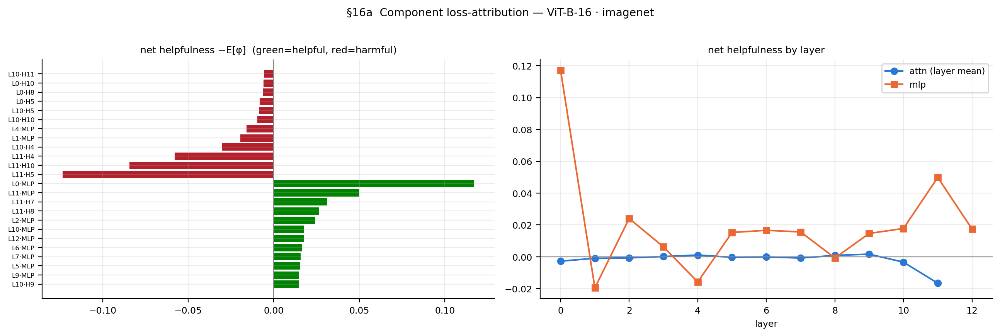

In [1]:
# Goal:  §16a -- compute phi & the 4 aggregations for the image tower; describe top helpful/harmful comps.
import torch.nn.functional as _F
TAU16, N_IMG16 = 0.01, 512

def img_comps(model, dataset, n_img=N_IMG16, seed=0):
    p = _paths(model, dataset)
    lbl = np.load(p["lbl_v"])
    Ymat = np.load(f"{OUT_DIR}/{dataset}_classifier_{model}.npy")          # [d, C]
    Y = torch.from_numpy(Ymat.T.astype(np.float32)).to(device); Y = Y / Y.norm(dim=1, keepdim=True)
    ok = np.flatnonzero(lbl < Y.shape[0])
    ii = np.random.default_rng(seed).permutation(ok)[:n_img]
    attn = np.load(p["attn_v"], mmap_mode="r"); mlp = np.load(p["mlp_v"], mmap_mode="r")
    L, H, M = attn.shape[1], attn.shape[2], mlp.shape[1]
    A = torch.from_numpy(np.asarray(attn[ii], dtype=np.float32)).to(device).reshape(len(ii), L * H, -1)
    Mt = torch.from_numpy(np.asarray(mlp[ii], dtype=np.float32)).to(device)
    A_comp = torch.cat([A, Mt], 1)                                          # [n, K, d]
    x = A_comp.sum(1)
    kind, layer, head = comp_index(L, H, M)
    lab = torch.as_tensor(lbl[ii].astype(np.int64)).to(device)
    return A_comp, x, Y, lab, (kind, layer, head)

def e_tangent(x, Y, lab, tau=TAU16):
    S = x @ Y.t() / tau
    e = (S.softmax(1) @ Y - Y[lab]) / tau                                   # img→text classification grad
    return e - (x * e).sum(1, keepdim=True) * x, S

def phi_scores(A_comp, e_tan):
    phi = torch.einsum("nkd,nd->nk", A_comp, e_tan)                         # [n, K]
    An, en = A_comp.norm(dim=2), e_tan.norm(dim=1, keepdim=True)
    return dict(phi=phi,
                helpful=(-phi.mean(0)).cpu().numpy(),
                involve=phi.abs().mean(0).cpu().numpy(),
                depend=phi.var(0).cpu().numpy(),
                align=(-phi / (An * en + 1e-30)).mean(0).cpu().numpy())

A16, x16, Y16, lab16, META16 = img_comps(MODEL_SEL, DATASET_SEL)
etan16, S16 = e_tangent(x16, Y16, lab16)
SC16 = phi_scores(A16, etan16)
kind, layer, head = META16
def clabel(c): return comp_label(kind[c], layer[c], head[c])
K16 = A16.shape[1]

hn = SC16["helpful"]
top_help = np.argsort(hn)[::-1][:12]; top_harm = np.argsort(hn)[:12]
print(f"§16a  φ attribution — {MODEL_SEL} · {DATASET_SEL}  (K={K16} components, n={A16.shape[0]} imgs)")
print("  most HELPFUL (−E[φ] high):", [f"{clabel(c)}:{hn[c]:+.1e}" for c in top_help[:6]])
print("  most HARMFUL (−E[φ] low ):", [f"{clabel(c)}:{hn[c]:+.1e}" for c in top_harm[:6]])
print(f"  #helpful={int((hn>0).sum())}  #harmful={int((hn<0).sum())}  "
      f"attn-side helpful%={100*np.mean([kind[c]=='attn' for c in top_help]):.0f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sel = list(top_help[::-1]) + list(top_harm)
cols = ["#008300"] * len(top_help) + ["#b3202b"] * len(top_harm)
ax[0].barh(range(len(sel)), [hn[c] for c in sel], color=cols)
ax[0].set_yticks(range(len(sel))); ax[0].set_yticklabels([clabel(c) for c in sel], fontsize=6)
ax[0].axvline(0, c="#888", lw=0.8); ax[0].set_title("net helpfulness −E[φ]  (green=helpful, red=harmful)")
Ls = sorted(set(layer[kind == "attn"]))
ax[1].plot(Ls, [hn[(layer == l) & (kind == "attn")].mean() for l in Ls], marker="o", color="#2a78d6", label="attn (layer mean)")
mlpc = np.flatnonzero(kind == "mlp")
ax[1].plot(layer[mlpc], hn[mlpc], marker="s", color="#eb6834", label="mlp")
ax[1].axhline(0, c="#888", lw=0.8); ax[1].set_xlabel("layer"); ax[1].set_title("net helpfulness by layer")
ax[1].legend(fontsize=8)
fig.suptitle(f"§16a  Component loss-attribution — {MODEL_SEL} · {DATASET_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"16a_phi_components_{MODEL_SEL}_{DATASET_SEL}"); plt.show()

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/16b_phi_benchmark_ViT-B-16_imagenet.png
§16b  zero-shot (% baseline retained):


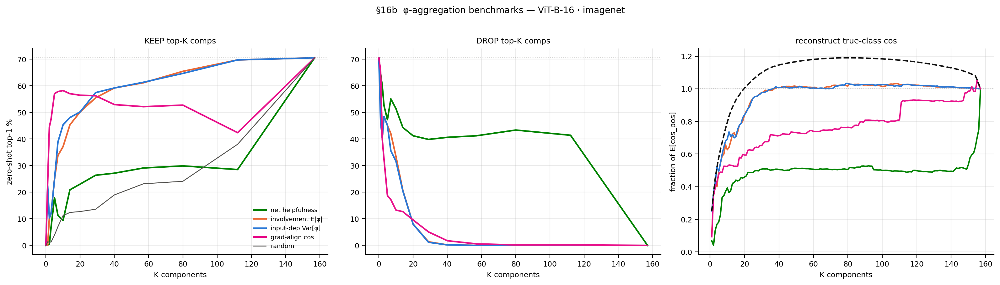

,keep@10,keep@50,drop@10,drop@50
net helpfulness,13.3,41.3,72.9,58.4
involvement E|φ|,52.6,86.7,47.4,0.0
input-dep Var[φ],64.3,87.0,44.9,0.0
grad-align cos,82.5,74.0,18.8,0.8


In [2]:
# Goal:  §16b -- component keep/drop zero-shot for the 4 aggregations + reconstruction of the true-class cosine.
def comp_curve(A_comp, x, Y, lab, score, mode, n_ckpt=16):
    K = A_comp.shape[1]; order = np.argsort(score)[::-1]                    # most-important first
    def acc(xh): return 100.0 * (xh @ Y.t()).argmax(1).eq(lab).float().mean().item()
    base = acc(x); chance = 100.0 / Y.shape[0]
    logK = np.unique(np.geomspace(1, K, n_ckpt).astype(int))
    xs = [0]; ys = [acc(torch.zeros_like(x)) if mode == "keep" else base]
    for Kk in logK:
        sel = torch.as_tensor(order[:int(Kk)].copy(), device=device)
        if mode == "keep":
            xh = A_comp[:, sel, :].sum(1)
        else:
            mask = torch.ones(K, dtype=torch.bool, device=device); mask[sel] = False
            xh = A_comp[:, mask, :].sum(1)
        xs.append(int(Kk)); ys.append(acc(xh))
    return np.array(xs), np.array(ys), base, chance

AGG = {"net helpfulness": SC16["helpful"], "involvement E|φ|": SC16["involve"],
       "input-dep Var[φ]": SC16["depend"], "grad-align cos": SC16["align"]}
ACOL = {"net helpfulness": "#008300", "involvement E|φ|": "#eb6834",
        "input-dep Var[φ]": "#2a78d6", "grad-align cos": "#e8118b"}
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
tbl = {}
for nm, sc in AGG.items():
    xk, yk, base, chance = comp_curve(A16, x16, Y16, lab16, sc, "keep")
    xd, yd, *_ = comp_curve(A16, x16, Y16, lab16, sc, "drop")
    ax[0].plot(xk, yk, color=ACOL[nm], lw=1.8, label=nm)
    ax[1].plot(xd, yd, color=ACOL[nm], lw=1.8, label=nm)
    tbl[nm] = {"keep@10": yk[np.searchsorted(xk, 10)], "keep@50": yk[np.searchsorted(xk, 50)],
               "drop@10": yd[np.searchsorted(xd, 10)], "drop@50": yd[np.searchsorted(xd, 50)]}
rnd = np.stack([comp_curve(A16, x16, Y16, lab16, np.random.default_rng(600+s).random(K16), "keep")[1] for s in range(5)])
ax[0].plot(comp_curve(A16, x16, Y16, lab16, SC16["helpful"], "keep")[0], rnd.mean(0), color="#52514e", lw=1, label="random")
# reconstruction of the true-class cosine
comp_pos = torch.einsum("nkd,nd->nk", A16, Y16[lab16]).mean(0).cpu().numpy()
total = comp_pos.sum()
for nm, sc in list(AGG.items()) + [("oracle (contribution)", comp_pos)]:
    o = np.argsort(sc)[::-1]; cum = np.cumsum(comp_pos[o]) / total
    ax[2].plot(np.arange(1, K16 + 1), cum, color=ACOL.get(nm, "#111"),
               ls="--" if nm.startswith("oracle") else "-", lw=1.6, label=nm)
ax[2].axhline(1, c="#888", lw=0.8, ls=":")
for a, t in zip(ax, ["KEEP top-K comps", "DROP top-K comps", "reconstruct true-class cos"]):
    a.set_title(t); a.set_xlabel("K components")
ax[0].set_ylabel("zero-shot top-1 %"); ax[2].set_ylabel("fraction of E[cos_pos]")
ax[0].axhline(base, c="#8a8a86", lw=0.8, ls=":"); ax[1].axhline(base, c="#8a8a86", lw=0.8, ls=":")
ax[0].legend(fontsize=7, frameon=False)
fig.suptitle(f"§16b  φ-aggregation benchmarks — {MODEL_SEL} · {DATASET_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"16b_phi_benchmark_{MODEL_SEL}_{DATASET_SEL}"); plt.show()
print("§16b  zero-shot (% baseline retained):")
display((pd.DataFrame(tbl).T / base * 100).round(1))

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/16c_phi_validation_ViT-B-16_imagenet.png
§16c  φ↔true-Δℒ  Spearman=0.838  Pearson=-0.559  (L_full=1.182)


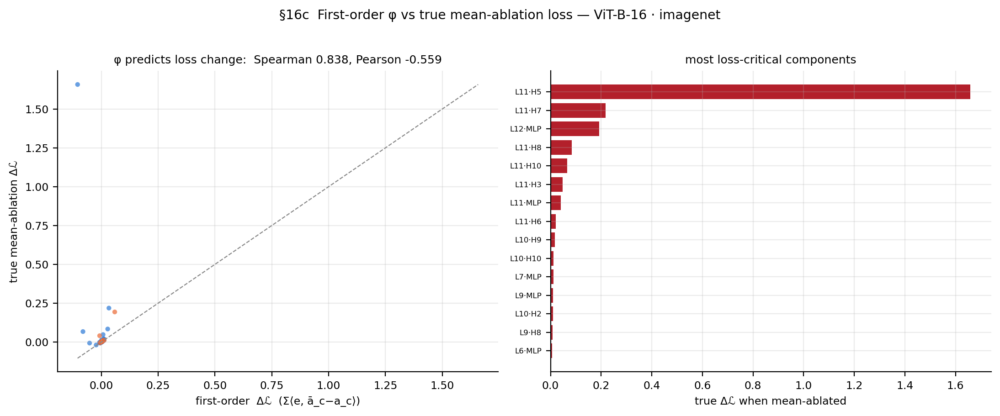

In [3]:
# Goal:  §16c -- validate first-order φ against the TRUE mean-ablation loss change per component.
def class_loss(xh): return _F.cross_entropy(xh @ Y16.t() / TAU16, lab16).item()
L_full = class_loss(x16)
abar = A16.mean(0)                                                          # [K, d] mean contribution
dL_true, dL_pred = np.zeros(K16), np.zeros(K16)
for c in range(K16):
    xh = x16 - A16[:, c, :] + abar[c]                                       # mean-ablate component c
    dL_true[c] = class_loss(xh) - L_full
    dL_pred[c] = ((etan16 * (abar[c] - A16[:, c, :])).sum(1)).mean().item() # first-order Δℒ
from scipy.stats import spearmanr as _spq, pearsonr as _pr
rho = _spq(dL_pred, dL_true).statistic; pe = _pr(dL_pred, dL_true)[0]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
cc = np.array(["#eb6834" if k == "mlp" else "#2a78d6" for k in kind])
ax[0].scatter(dL_pred, dL_true, s=14, c=cc, alpha=0.7, linewidths=0)
lim = [min(dL_pred.min(), dL_true.min()), max(dL_pred.max(), dL_true.max())]
ax[0].plot(lim, lim, c="#888", lw=0.8, ls="--")
ax[0].set_xlabel("first-order  Δℒ  (Σ⟨e, ā_c−a_c⟩)"); ax[0].set_ylabel("true mean-ablation Δℒ")
ax[0].set_title(f"φ predicts loss change:  Spearman {rho:.3f}, Pearson {pe:.3f}")
order = np.argsort(dL_true)[::-1][:15]
ax[1].barh(range(len(order)), dL_true[order], color="#b3202b")
ax[1].set_yticks(range(len(order))); ax[1].set_yticklabels([clabel(c) for c in order], fontsize=6)
ax[1].invert_yaxis(); ax[1].set_xlabel("true Δℒ when mean-ablated"); ax[1].set_title("most loss-critical components")
fig.suptitle(f"§16c  First-order φ vs true mean-ablation loss — {MODEL_SEL} · {DATASET_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"16c_phi_validation_{MODEL_SEL}_{DATASET_SEL}"); plt.show()
print(f"§16c  φ↔true-Δℒ  Spearman={rho:.3f}  Pearson={pe:.3f}  (L_full={L_full:.3f})")

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/16d_phi_grid.png


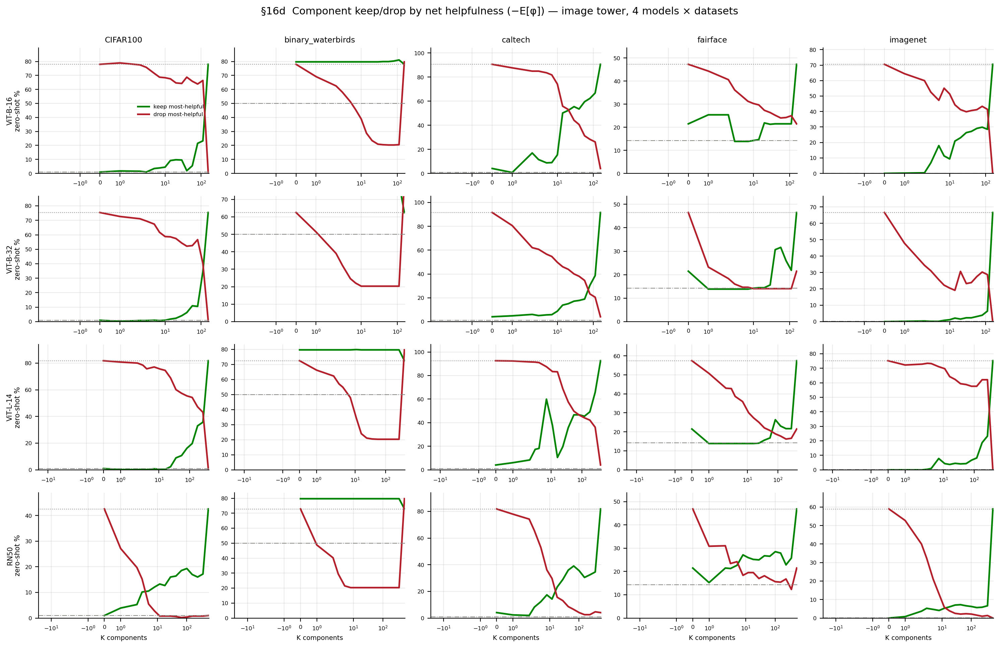

In [4]:
# Goal:  §16d -- net-helpfulness component keep/drop across the 4 models × all datasets.
titled = set()
fig, axes = plt.subplots(len(MODELS4), len(DATASETS), figsize=(15, 2.4 * len(MODELS4)), squeeze=False)
for ri, m in enumerate(MODELS4):
    for ci, d in enumerate(DATASETS):
        ax = axes[ri][ci]
        if not os.path.exists(f"{OUT_DIR}/{d}_classifier_{m}.npy") or (m, d, "pos") not in R:
            ax.set_visible(False); continue
        Ac, xc, Yc, lc, _ = img_comps(m, d)
        et, _ = e_tangent(xc, Yc, lc); hlp = (-torch.einsum("nkd,nd->nk", Ac, et).mean(0)).cpu().numpy()
        xk, yk, base, chance = comp_curve(Ac, xc, Yc, lc, hlp, "keep")
        xd, yd, *_ = comp_curve(Ac, xc, Yc, lc, hlp, "drop")
        ax.plot(xk, yk, color="#008300", lw=1.8, label="keep most-helpful")
        ax.plot(xd, yd, color="#b3202b", lw=1.8, label="drop most-helpful")
        ax.axhline(base, c="#8a8a86", lw=0.8, ls=":"); ax.axhline(chance, c="#8a8a86", lw=0.8, ls="-.")
        ax.set_xscale("symlog"); ax.set_ylim(0, max(base * 1.15, 5))
        if d not in titled: ax.set_title(d, fontsize=8.5); titled.add(d)
        if ci == 0: ax.set_ylabel(f"{m}\nzero-shot %", fontsize=7.5)
        if ri == len(MODELS4) - 1: ax.set_xlabel("K components", fontsize=7)
        ax.tick_params(labelsize=6)
        del Ac, xc, et
        if device.startswith("cuda"): torch.cuda.empty_cache()
axes[0][0].legend(fontsize=6, loc="center right", frameon=False)
fig.suptitle("§16d  Component keep/drop by net helpfulness (−E[φ]) — image tower, 4 models × datasets",
             fontsize=11, y=1.004)
plt.tight_layout(); save_fig(fig, "16d_phi_grid"); plt.show()

## §17 — $\Phi_{ab}$: the loss-weighted pair interaction (the unifying score)

$\Phi_{ab}=-\sum_{i,j}w_{ij}\,S_{ab}^{(ij)}=-\sum_i\langle a_a^{(i)},\beta_b^{(i)}\rangle$, with
$w_{ij}=\tfrac1\tau(p_{ij}-\mathbb 1[j=\mathrm{lab}_i])$ and $\beta_b^{(i)}=\sum_j w_{ij}b_b^{(j)}$.
It is *how much pair $(a,b)$ moved the loss the way training wanted*. We verify the conservation
identity $\sum_b\Phi_{ab}=\varphi_a^{\text{vision}}$, then benchmark keep/drop zero-shot for $\Phi$
against $d'$, $|\Delta\mu|$ (previous best), **later-layer ablation**, and random.

§17  Φ_ab — ViT-B-16 · imagenet  shape=(157, 109)
  conservation Σ_b Φ_ab == φ_a :  corr=1.000000  max|diff|=4.73e-04
  top Φ pairs: ['L12·MLP×L12·MLP', 'L11·H7×L9·H0', 'L12·MLP×L11·MLP', 'L0·MLP×L9·H6', 'L0·MLP×L8·MLP', 'L12·MLP×L9·MLP']
saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/17_phi_pair_ViT-B-16_imagenet.png
§17  zero-shot (% baseline retained):


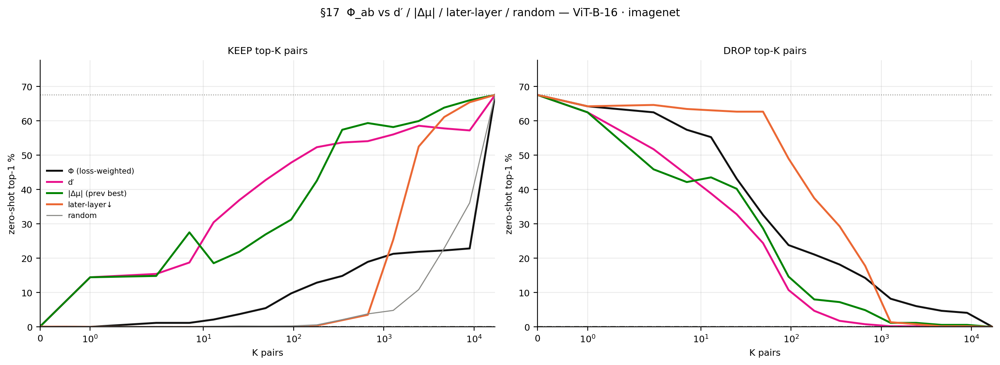

,keep@50,keep@500,drop@50,drop@500
Φ (loss-weighted),14.5,28.0,35.3,21.1
d′,70.8,80.1,15.9,1.2
|Δμ| (prev best),46.2,87.9,21.7,7.2
later-layer↓,0.0,5.2,72.5,26.3


In [1]:
# Goal:  §17 -- compute Φ_ab from vision+text components; verify conservation; keep/drop benchmark.
TAU17, NIMG17 = 0.01, 512

def load_pair_towers(model, dataset, n_img=NIMG17, seed=0):
    p = _paths(model, dataset); lbl = np.load(p["lbl_v"])
    at = np.load(p["attn_v"], mmap_mode="r"); ml = np.load(p["mlp_v"], mmap_mode="r")
    Lv, Hv, Mv = at.shape[1], at.shape[2], ml.shape[1]
    bt = np.load(p["attn_t"], mmap_mode="r"); bm = np.load(p["mlp_t"], mmap_mode="r")
    Ct, Lt, Ht, Mt = bt.shape[0], bt.shape[1], bt.shape[2], bm.shape[1]
    ii = np.random.default_rng(seed).permutation(np.flatnonzero(lbl < Ct))[:n_img]
    A = torch.cat([torch.from_numpy(np.asarray(at[ii], dtype=np.float32)).to(device).reshape(len(ii), Lv * Hv, -1),
                   torch.from_numpy(np.asarray(ml[ii], dtype=np.float32)).to(device)], 1)   # [n,Kv,d]
    B = torch.cat([torch.from_numpy(np.asarray(bt, dtype=np.float32)).to(device).reshape(Ct, Lt * Ht, -1),
                   torch.from_numpy(np.asarray(bm, dtype=np.float32)).to(device)], 1)         # [C,Kt,d]
    lab = torch.as_tensor(lbl[ii].astype(np.int64)).to(device)
    return A, B, lab, comp_index(Lv, Hv, Mv), comp_index(Lt, Ht, Mt)

@torch.no_grad()
def phi_pair(A, B, lab, tau=TAU17):
    x, Y = A.sum(1), B.sum(1)
    S = x @ Y.t() / tau; p = S.softmax(1)
    w = p.clone(); w[torch.arange(len(lab), device=device), lab] -= 1.0; w = w / tau      # ∂L/∂s  [n,C]
    beta = torch.einsum("nc,ckd->nkd", w, B)                                               # [n,Kt,d]
    Phi = -torch.einsum("nad,nbd->ab", A, beta)                                            # [Kv,Kt]
    e = w @ Y                                                                              # [n,d]  Σ_j w y_j
    phi_a = -torch.einsum("nad,nd->a", A, e)                                               # Σ_b Φ_ab must equal this
    return Phi.cpu().numpy(), phi_a.cpu().numpy(), (x, Y, S, p, w)

A17, B17, lab17, META17V, META17T = load_pair_towers(MODEL_SEL, DATASET_SEL)
PHI17, PHIA17, AUX17 = phi_pair(A17, B17, lab17)
kvV, lvV, hvV = META17V; ktT, ltT, htT = META17T
cons_corr = np.corrcoef(PHI17.sum(1), PHIA17)[0, 1]
print(f"§17  Φ_ab — {MODEL_SEL} · {DATASET_SEL}  shape={PHI17.shape}")
print(f"  conservation Σ_b Φ_ab == φ_a :  corr={cons_corr:.6f}  max|diff|={np.abs(PHI17.sum(1)-PHIA17).max():.2e}")
order = np.argsort(PHI17, axis=None)[::-1]; Kt = PHI17.shape[1]
print("  top Φ pairs:", [f"{comp_label(kvV[o//Kt],lvV[o//Kt],hvV[o//Kt])}×{comp_label(ktT[o%Kt],ltT[o%Kt],htT[o%Kt])}"
                         for o in order[:6]])

# ---- benchmark ----
a_ = pair_all(MODEL_SEL, DATASET_SEL)
mp, mn, vp, vn = a_["mean_pos"], a_["mean_neg"], a_["var_pos"], a_["var_neg"]
G = (mp - mn) / np.sqrt(vp + vn + 1e-30); dmu = np.abs(mp - mn)
lv_bc = np.repeat(lvV[:, None].astype(float), PHI17.shape[1], 1)
CR17 = {"Φ (loss-weighted)": (PHI17, "#111111"), "d′": (G, "#e8118b"),
        "|Δμ| (prev best)": (dmu, "#008300"), "later-layer↓": (lv_bc, "#eb6834")}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6)); tbl = {}
for nm, (cr, col) in CR17.items():
    xk, yk, base, chance, P, _ = keep_topk_accuracy(MODEL_SEL, DATASET_SEL, cr, ascending=False)
    xd, yd, *_ = drop_topk_curve(MODEL_SEL, DATASET_SEL, cr, ascending=False)
    ax[0].plot(xk, yk, color=col, lw=1.8, label=nm); ax[1].plot(xd, yd, color=col, lw=1.8, label=nm)
    def _at(x, y, K): return y[min(int(np.searchsorted(x, K)), len(y) - 1)]
    tbl[nm] = {"keep@50": _at(xk, yk, 50), "keep@500": _at(xk, yk, 500),
               "drop@50": _at(xd, yd, 50), "drop@500": _at(xd, yd, 500)}
rk = np.stack([keep_topk_accuracy(MODEL_SEL, DATASET_SEL, np.random.default_rng(700+s).random(PHI17.shape),
                                  ascending=True)[1] for s in range(5)])
ax[0].plot(xk, rk.mean(0), color="#8a8a86", lw=1.0, label="random")
for a, t in zip(ax, ["KEEP top-K pairs", "DROP top-K pairs"]):
    a.axhline(base, c="#8a8a86", lw=0.8, ls=":"); a.axhline(chance, c="#8a8a86", lw=0.8, ls="-.")
    a.set_xscale("symlog"); a.set_xlim(0, P); a.set_ylim(0, base * 1.15)
    a.set_xlabel("K pairs"); a.set_ylabel("zero-shot top-1 %"); a.set_title(t)
ax[0].legend(fontsize=7, frameon=False)
fig.suptitle(f"§17  Φ_ab vs d′ / |Δμ| / later-layer / random — {MODEL_SEL} · {DATASET_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"17_phi_pair_{MODEL_SEL}_{DATASET_SEL}"); plt.show()
print("§17  zero-shot (% baseline retained):")
display((pd.DataFrame(tbl).T / base * 100).round(1))

## §18 — Interaction structure among the top pairs + Φ as first-order loss attribution

Among the top-Φ pairs: **which fire together?** The correlation of their per-sample contributions
(clustered) exposes circuits — redundant (red) vs complementary (blue) pairs. And we validate Φ as a
first-order loss attribution: `Φ_ab` vs the **true** per-pair mean-ablation Δℒ (the pair analogue of
§16c; note the mean term vanishes because `Σ_j w_ij = 0`, so first-order Δℒ = Φ_ab exactly).

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/18_interactions_ViT-B-16_imagenet.png
§18  Φ↔true-Δℒ (top 36 pairs) Spearman=0.834; mean |corr| off-diag=0.16


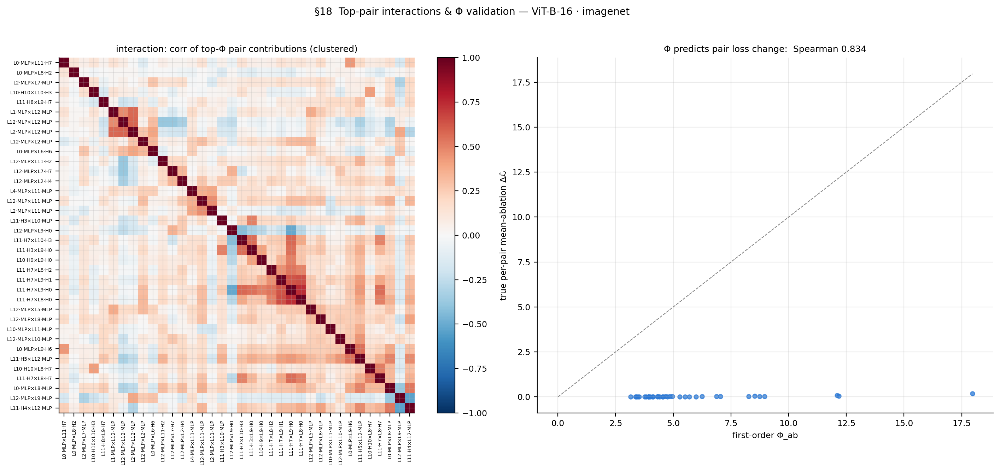

In [1]:
# Goal:  §18 -- top-Φ pair interaction (contribution correlation, clustered) + Φ vs true Δℒ.
import torch.nn.functional as _F
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import spearmanr as _spq
M18 = 36
ordP = np.argsort(PHI17, axis=None)[::-1]; Kt = PHI17.shape[1]
topp = [(int(o // Kt), int(o % Kt)) for o in ordP[:M18]]
lbl18 = [f"{comp_label(kvV[a],lvV[a],hvV[a])}×{comp_label(ktT[b],ltT[b],htT[b])}" for a, b in topp]
Bpos = B17[lab17]                                                        # [n,Kt,d]
Smat = torch.stack([(A17[:, a, :] * Bpos[:, b, :]).sum(-1) for a, b in topp], 1).cpu().numpy()  # [n,M]
corr = np.corrcoef(Smat.T)
Z = linkage(np.clip(1 - np.abs(corr), 0, None)[np.triu_indices(M18, 1)], method="average")
oc = leaves_list(Z)
x17, Y17 = A17.sum(1), B17.sum(1); S17 = x17 @ Y17.t() / TAU17; Lf = _F.cross_entropy(S17, lab17).item()
dLt, dLp = np.zeros(M18), np.zeros(M18)
for k, (a, b) in enumerate(topp):
    Sab = A17[:, a, :] @ B17[:, b, :].t()                                # [n,C]
    dLt[k] = _F.cross_entropy(S17 - (Sab - Sab.mean()) / TAU17, lab17).item() - Lf
    dLp[k] = PHI17[a, b]
rho = _spq(dLp, dLt).statistic
fig, ax = plt.subplots(1, 2, figsize=(15, 6.4))
im = ax[0].imshow(corr[np.ix_(oc, oc)], cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_xticks(range(M18)); ax[0].set_xticklabels([lbl18[i] for i in oc], rotation=90, fontsize=5)
ax[0].set_yticks(range(M18)); ax[0].set_yticklabels([lbl18[i] for i in oc], fontsize=5)
ax[0].set_title("interaction: corr of top-Φ pair contributions (clustered)"); fig.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].scatter(dLp, dLt, s=18, alpha=0.75, c="#2a78d6"); lim = [min(dLp.min(), dLt.min()), max(dLp.max(), dLt.max())]
ax[1].plot(lim, lim, ls="--", c="#888", lw=0.8)
ax[1].set_xlabel("first-order Φ_ab"); ax[1].set_ylabel("true per-pair mean-ablation Δℒ")
ax[1].set_title(f"Φ predicts pair loss change:  Spearman {rho:.3f}")
fig.suptitle(f"§18  Top-pair interactions & Φ validation — {MODEL_SEL} · {DATASET_SEL}", y=1.02)
plt.tight_layout(); save_fig(fig, f"18_interactions_{MODEL_SEL}_{DATASET_SEL}"); plt.show()
print(f"§18  Φ↔true-Δℒ (top {M18} pairs) Spearman={rho:.3f}; mean |corr| off-diag={np.abs(corr[np.triu_indices(M18,1)]).mean():.2f}")

## §19 — Output-space specialization: what do the top pairs respond to?

Per top-Φ pair, the **class response** `M[pair,c] = E_{i∈c}[S_ab(i,c)]` (how strongly the pair drives
the correct-class similarity, per class). The clustered heatmap shows specialization; the table lists,
for each pair, the classes it most **drives** vs most **suppresses** — i.e. where it helps and where it
struggles. Run on CIFAR100 (100 interpretable classes) for legibility.

saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/19_response_ViT-B-16_CIFAR100.png
§19  what the top-Φ pairs drive vs suppress — ViT-B-16 · CIFAR100


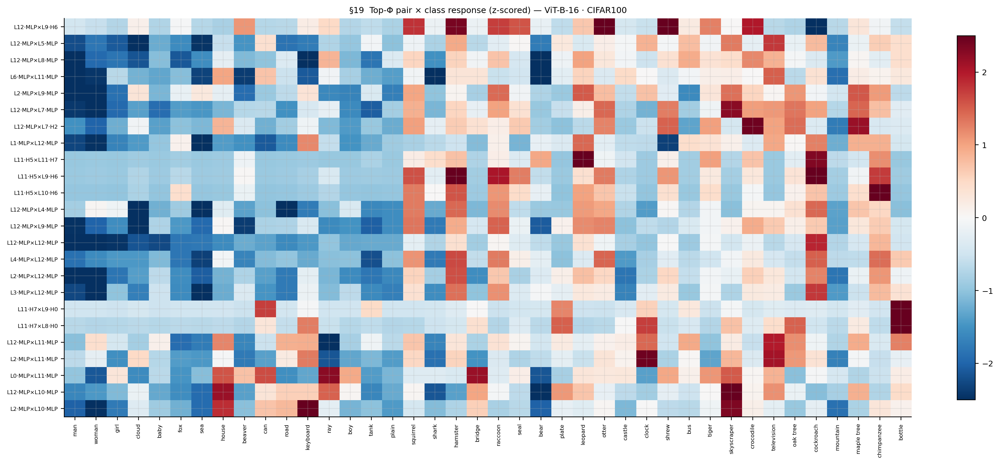

,pair,drives,suppresses
0,L12·MLP×L12·MLP,cockroach; beetle; lawn mower,woman; man; girl
1,L12·MLP×L10·MLP,skyscraper; forest; house,bear; shark; sea
2,L12·MLP×L9·MLP,raccoon; kangaroo; forest,cloud; man; beaver
3,L12·MLP×L7·MLP,skyscraper; pickup truck; skunk,woman; man; tank
4,L12·MLP×L11·MLP,tractor; lamp; television,ray; poppy; orange
5,L11·H5×L11·H7,cattle; leopard; butterfly,plate; can; couch
6,L2·MLP×L12·MLP,aquarium fish; cup; hamster,man; woman; sea
7,L12·MLP×L8·MLP,sunflower; cup; dinosaur,bear; man; keyboard
8,L11·H5×L9·H6,cockroach; hamster; orchid,plate; man; couch
9,L11·H5×L10·H6,chimpanzee; pear; sunflower,plate; bowl; clock


In [2]:
# Goal:  §19 -- per-class response matrix + help/hurt classes for the top-Φ pairs (CIFAR100).
DS19, P19 = "CIFAR100", 24
A19, B19, lab19, MV19, MT19 = load_pair_towers(MODEL_SEL, DS19, n_img=3000)
PHI19, _, _ = phi_pair(A19, B19, lab19)
kv9, lv9, hv9 = MV19; kt9, lt9, ht9 = MT19; Kt9 = PHI19.shape[1]
ordq = np.argsort(PHI19, axis=None)[::-1]
topq = [(int(o // Kt9), int(o % Kt9)) for o in ordq[:P19]]
labs = lab19.cpu().numpy(); classes = np.unique(labs)
cnf = f"{OUT_DIR}/{DS19}_classnames.txt"
CN = [l.strip() for l in open(cnf)] if os.path.exists(cnf) else None
cname = (lambda c: CN[int(c)] if CN and int(c) < len(CN) else f"c{int(c)}")
Mrsp = np.zeros((P19, len(classes)))
for pi, (a, b) in enumerate(topq):
    Sab = (A19[:, a, :] @ B19[:, b, :].t()).cpu().numpy()                # [n,C]
    for ci, c in enumerate(classes):
        m = labs == c
        if m.any(): Mrsp[pi, ci] = Sab[m, c].mean()
Zp = (Mrsp - Mrsp.mean(1, keepdims=True)) / (Mrsp.std(1, keepdims=True) + 1e-9)
topc = np.argsort(Mrsp.var(0))[::-1][:40]
op = leaves_list(linkage(Zp[:, topc], method="average"))
plbl = [f"{comp_label(kv9[a],lv9[a],hv9[a])}×{comp_label(kt9[b],lt9[b],ht9[b])}" for a, b in topq]
fig, ax = plt.subplots(figsize=(15, 7))
im = ax.imshow(Zp[np.ix_(op, topc)], cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_yticks(range(P19)); ax.set_yticklabels([plbl[i] for i in op], fontsize=6)
ax.set_xticks(range(len(topc))); ax.set_xticklabels([cname(classes[c]) for c in topc], rotation=90, fontsize=6)
fig.colorbar(im, ax=ax, fraction=0.02); ax.set_title(f"§19  Top-Φ pair × class response (z-scored) — {MODEL_SEL} · {DS19}")
plt.tight_layout(); save_fig(fig, f"19_response_{MODEL_SEL}_{DS19}"); plt.show()
rows = []
for pi, (a, b) in enumerate(topq[:10]):
    drives = classes[np.argsort(Mrsp[pi])[::-1][:3]]; supp = classes[np.argsort(Mrsp[pi])[:3]]
    rows.append(dict(pair=plbl[pi], drives="; ".join(cname(c) for c in drives),
                     suppresses="; ".join(cname(c) for c in supp)))
print(f"§19  what the top-Φ pairs drive vs suppress — {MODEL_SEL} · {DS19}")
pd.set_option("display.max_colwidth", 50); display(pd.DataFrame(rows))
del A19, B19
if device.startswith("cuda"): torch.cuda.empty_cache()

## §20 — Application: training-free debiasing by nulling misaligned pairs

Mean-ablate the **most-misaligned** pairs (lowest signed d′ — the reversed pos/neg ones that fight the
decision) and read off the best point of the sweep. Report **overall and worst-class** accuracy before
vs after, for Waterbirds & FairFace across the 4 models — a no-retraining intervention that turns the
§15/§15b diagnostic into a method.

§20  Training-free debiasing by nulling misaligned pairs (best point of the sweep):
saved → output_dir/activations_and_datasets_idxs_69/pair_variance_figs/20_debias_worstclass.png


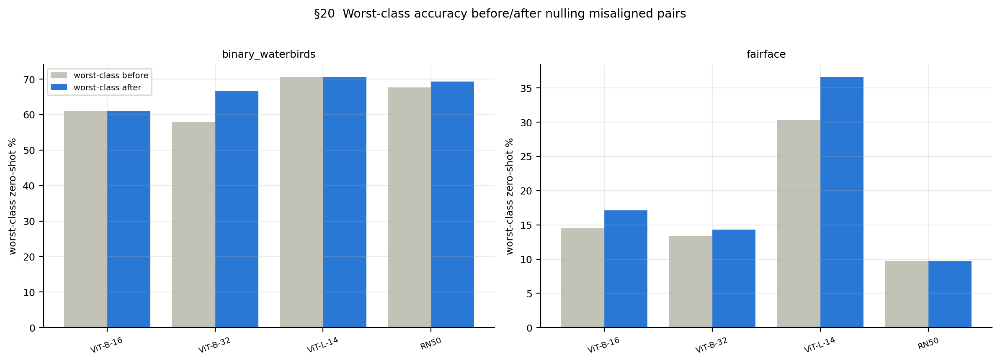

,model,dataset,base_ov,best_ov,dOv,K_ov,base_wc,best_wc,dWC,K_wc
0,ViT-B-16,binary_waterbirds,70.2,78.7,8.5,89,60.9,60.9,0.0,0
1,ViT-B-16,fairface,47.6,49.9,2.3,20,14.5,17.1,2.6,89
2,ViT-B-32,binary_waterbirds,62.8,78.2,15.4,190,58.0,66.7,8.7,20
3,ViT-B-32,fairface,47.0,47.4,0.4,1,13.4,14.3,0.8,1
4,ViT-L-14,binary_waterbirds,72.5,79.8,7.3,165,70.6,70.6,0.0,0
5,ViT-L-14,fairface,56.1,58.4,2.3,70,30.3,36.6,6.2,165
6,RN50,binary_waterbirds,69.1,80.1,11.0,68,67.6,69.3,1.7,5
7,RN50,fairface,39.7,41.7,2.0,29,9.7,9.7,0.0,0


In [3]:
# Goal:  §20 -- null most-misaligned pairs; best overall & worst-class gain vs baseline (waterbirds, fairface).
BIAS20 = ["binary_waterbirds", "fairface"]
rows = []
for m in MODELS4:
    for d in BIAS20:
        if (m, d, "pos") not in R: continue
        G = gauss_d(m, d)
        x, ao, aw, bo, bw, ch, P = drop_curve_worst(m, d, G, ascending=True, n_img=1000)  # drop low-d′ first
        v = x < P * 0.4                                                                     # ignore degenerate tail
        io_, iw = np.argmax(ao[v]), np.argmax(aw[v])
        rows.append(dict(model=m, dataset=d, base_ov=round(bo, 1), best_ov=round(ao[v][io_], 1),
                         dOv=round(ao[v][io_] - bo, 1), K_ov=int(x[v][io_]),
                         base_wc=round(bw, 1), best_wc=round(aw[v][iw], 1),
                         dWC=round(aw[v][iw] - bw, 1), K_wc=int(x[v][iw])))
res20 = pd.DataFrame(rows)
print("§20  Training-free debiasing by nulling misaligned pairs (best point of the sweep):")
display(res20)
fig, axes = plt.subplots(1, len(BIAS20), figsize=(12, 4.2), squeeze=False)
for ci, d in enumerate(BIAS20):
    sub = res20[res20.dataset == d]; ax = axes[0][ci]; xx = np.arange(len(sub))
    ax.bar(xx - 0.2, sub.base_wc, 0.4, color="#c3c2b7", label="worst-class before")
    ax.bar(xx + 0.2, sub.best_wc, 0.4, color="#2a78d6", label="worst-class after")
    ax.set_xticks(xx); ax.set_xticklabels(sub.model, rotation=20, fontsize=7); ax.set_title(d)
    ax.set_ylabel("worst-class zero-shot %")
    if ci == 0: ax.legend(fontsize=7)
fig.suptitle("§20  Worst-class accuracy before/after nulling misaligned pairs", y=1.02)
plt.tight_layout(); save_fig(fig, "20_debias_worstclass"); plt.show()